In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [52]:

def show_outliers_and_distributions(df, z_thresh=3):
    """
    Identifies outliers in numerical and categorical columns of a DataFrame
    and plots the distribution of each column, highlighting the outliers.

    Args:
        df (pd.DataFrame): The input DataFrame.
        z_thresh (int, optional): The Z-score threshold for numerical outliers.
                                   Defaults to 3.
    """
    # Separate numerical and categorical columns
    numerical_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    if len(numerical_cols) == 0 and len(categorical_cols) == 0:
        print("No numerical or categorical columns found in the DataFrame.")
        return

    # --- Analyze Numerical Columns ---
    if len(numerical_cols) > 0:
        print(f"Analyzing {len(numerical_cols)} numerical column(s): {', '.join(numerical_cols)}\n")
        for col in numerical_cols:
            col_data = df[col].dropna()

            if len(col_data) == 0:
                print(f"--- Column: {col} ---")
                print("Column is empty after dropping NA values.\n")
                continue

            z_scores = np.abs(stats.zscore(col_data))
            outliers = col_data[z_scores > z_thresh]
            num_outliers = len(outliers)

            print(f"--- Column: {col} ---")
            if num_outliers == 0:
                print("No outliers found.")
            else:
                print(f"Found {num_outliers} outlier(s) ({(num_outliers/len(col_data))*100:.2f}% of data).")
                print(f"Outlier values: {outliers.values.tolist()}")

            # --- Plotting Numerical Data ---
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            fig.suptitle(f'Analysis for Numerical Column: {col}', fontsize=16)

            # Distribution Plot
            sns.histplot(df[col].fillna(0), kde=True, ax=axes[0], color='skyblue')
            axes[0].set_title('Data Distribution')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Frequency')

            # Scatter Plot with Outliers
            if num_outliers > 0:
                plot_df = pd.DataFrame({'values': col_data, 'is_outlier': z_scores > z_thresh})
                sns.scatterplot(x=plot_df.index, y=plot_df['values'], hue=plot_df['is_outlier'],
                                palette={True: 'red', False: 'blue'}, ax=axes[1], legend=False)
            else:
                sns.scatterplot(x=df.index, y=df[col], ax=axes[1], color='blue')
            axes[1].set_title('Data Points with Outliers Highlighted')
            axes[1].set_xlabel('Index')
            axes[1].set_ylabel(col)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            print()

    # --- Analyze Categorical Columns ---
    if len(categorical_cols) > 0:
        print(f"\nAnalyzing {len(categorical_cols)} categorical column(s): {', '.join(categorical_cols)}\n")
        for col in categorical_cols:
            print(f"--- Column: {col} ---")

            # --- Plotting Categorical Data ---
            plt.figure(figsize=(10, 6))
            sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
            plt.title(f'Distribution of Categorical Column: {col}')
            plt.xlabel('Count')
            plt.ylabel(col)
            plt.show()
            print()

In [53]:
def impute_outliers(df, threshold=1.5, categorical_threshold=0.01):
    """
    Identifies and imputes outliers in a DataFrame for both numerical and categorical columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        threshold (float, optional): The IQR threshold for numerical outlier detection. Defaults to 1.5.
        categorical_threshold (float, optional): The frequency threshold for categorical outliers.
                                                  Defaults to 0.01 (1%).
    """
    df_imputed = df.copy()

    for col in df_imputed.columns:
        # Distinguish between numerical and categorical columns
        if pd.api.types.is_numeric_dtype(df_imputed[col]):
            # Numerical column: Use IQR method
            q1 = df_imputed[col].quantile(0.25)
            q3 = df_imputed[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - threshold * iqr
            upper_bound = q3 + threshold * iqr

            outliers = (df_imputed[col] < lower_bound) | (df_imputed[col] > upper_bound)
            if outliers.any():
                median_val = df_imputed[col][~outliers].median()
                df_imputed.loc[outliers, col] = median_val
                print(f"Numerical column '{col}': Imputed {outliers.sum()} outliers with median value {median_val:.2f}.")

        else:
            # Categorical column: Use frequency-based method
            value_counts = df_imputed[col].value_counts(normalize=True)
            outlier_values = value_counts[value_counts < categorical_threshold].index
            
            if len(outlier_values) > 0:
                mode_val = df_imputed[col].mode()[0]
                outliers = df_imputed[col].isin(outlier_values)
                df_imputed.loc[outliers, col] = mode_val
                print(f"Categorical column '{col}': Imputed {outliers.sum()} outliers with mode value '{mode_val}'.")

    return df_imputed

In [54]:
def remove_rows_by_value(df, ignore_cols):
    """
    Removes rows from a DataFrame based on a condition for numerical columns,
    while ignoring specified columns.

    For all numerical columns NOT in the ignore_cols list, this function
    removes rows where the cell value is greater than 3.

    Args:
        df (pd.DataFrame): The input DataFrame.
        ignore_cols (list): A list of column names to ignore from the filtering process.

    Returns:
        pd.DataFrame: A new DataFrame with the specified rows removed.
    """
    # Work on a copy to avoid modifying the original DataFrame
    df_filtered = df.copy()

    # Identify all numerical columns in the DataFrame
    numerical_cols = df_filtered.select_dtypes(include=np.number).columns

    # A set is used to store the indices of rows to drop, avoiding duplicates
    indices_to_drop = set()

    print("Screening columns for values > 3...")
    # Loop through each numerical column
    for col in numerical_cols:
        # Check if the current column is in the ignore list
        if col not in ignore_cols:
            print(f"- Processing column: '{col}'")
            # Find the indices of rows where the value is greater than 3
            rows_to_remove = df_filtered[df_filtered[col] > 3].index
            
            if not rows_to_remove.empty:
                print(f"  -> Found {len(rows_to_remove)} rows to remove based on '{col}'.")
                # Add the indices of these rows to our set
                indices_to_drop.update(rows_to_remove)
        else:
            print(f"- Ignoring column: '{col}'")

    # Check if there are any rows to remove before trying to drop them
    if indices_to_drop:
        print(f"\nTotal unique rows to be removed: {len(indices_to_drop)}")
        # Drop all the identified rows from the DataFrame at once
        df_filtered = df_filtered.drop(index=list(indices_to_drop))
    else:
        print("\nNo rows met the removal criteria.")

    return df_filtered

In [55]:
df = pd.read_csv("./raw/security/conjunto_de_datos_ensu_cb_0625.csv")
df

,ID_VIV,ID_PER,UPM,VIV_SEL,R_SEL,ID_VIVT,ID_PERT,CVE_ENT,NOM_ENT,CVE_MUN,...,BP4_1_6,BP4_1_7,BP4_1_8,BP4_1_9,FAC_VIV,FAC_SEL,DOMINIO,EST,UPM_DIS,EST_DIS
0,0100107.0009.54,0100107.0009.54.02,100107,54,2,-,-,1,AGUASCALIENTES,1,...,2,2,2,2,1218,2435,U,2,1,1
1,0100107.0029.55,0100107.0029.55.01,100107,55,1,-,-,1,AGUASCALIENTES,1,...,2,2,1,2,1218,1218,U,2,1,1
2,0100107.0066.52,0100107.0066.52.02,100107,52,2,-,-,1,AGUASCALIENTES,1,...,2,2,2,2,1218,2435,U,2,1,1
3,0100107.0087.53,0100107.0087.53.01,100107,53,1,-,-,1,AGUASCALIENTES,1,...,2,2,2,2,1218,3653,U,2,1,1
4,0100146.0010.51,0100146.0010.51.02,100146,51,2,-,-,1,AGUASCALIENTES,1,...,2,2,2,2,1048,2096,U,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23712,3203701.0017.53,3203701.0017.53.01,3203701,53,1,-,-,32,ZACATECAS,56,...,2,2,2,2,418,837,U,4,5424,302
23713,3203701.0056.54,3203701.0056.54.01,3203701,54,1,-,-,32,ZACATECAS,56,...,2,2,2,2,418,418,U,4,5424,302
23714,3203701.0088.55,3203701.0088.55.01,3203701,55,1,-,-,32,ZACATECAS,56,...,2,2,2,2,418,1255,U,4,5424,302
23715,3203701.0144.52,3203701.0144.52.02,3203701,52,2,-,-,32,ZACATECAS,56,...,2,2,2,2,418,837,U,4,5424,302


In [56]:
selected_columns = ["SEXO", "EDAD", "NOM_ENT","NOM_MUN", "BP1_1", "BP1_2_01","BP1_2_03","BP1_4_1","BP1_4_2","BP1_4_3","BP1_4_4","BP1_4_5","BP1_4_6","BP1_4_7","BP1_4_8","BP1_5_1","BP1_5_2","BP1_6_4","BP2_2_03","BP2_2_11","BP2_2_14","BP3_1_05","BP3_1_07","BP3_1_08","BP3_1_10","BP3_1_11","BP3_1_13","BP3_1_14","BP4_1_1","BP4_1_2","BP4_1_3","BP4_1_7","BP4_1_8"]
df=df[selected_columns]
df

,SEXO,EDAD,NOM_ENT,NOM_MUN,BP1_1,BP1_2_01,BP1_2_03,BP1_4_1,BP1_4_2,BP1_4_3,...,BP3_1_08,BP3_1_10,BP3_1_11,BP3_1_13,BP3_1_14,BP4_1_1,BP4_1_2,BP4_1_3,BP4_1_7,BP4_1_8
0,2,38,AGUASCALIENTES,AGUASCALIENTES,2,2,2,1,1,1,...,0,0,0,0,1,2,2,2,2,2
1,2,24,AGUASCALIENTES,AGUASCALIENTES,2,1,2,2,2,1,...,1,1,0,0,1,1,2,2,2,1
2,2,35,AGUASCALIENTES,AGUASCALIENTES,1,1,1,2,2,2,...,0,0,0,1,1,2,2,2,2,2
3,2,23,AGUASCALIENTES,AGUASCALIENTES,1,1,1,1,1,1,...,1,0,0,1,1,2,2,2,2,2
4,2,24,AGUASCALIENTES,AGUASCALIENTES,1,1,1,2,2,2,...,0,0,0,1,1,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23712,1,43,ZACATECAS,ZACATECAS,2,1,2,2,2,2,...,1,1,1,1,1,2,2,2,2,2
23713,1,27,ZACATECAS,ZACATECAS,2,1,2,2,2,2,...,0,1,0,0,1,2,2,2,2,2
23714,1,45,ZACATECAS,ZACATECAS,1,1,1,2,2,2,...,0,1,1,0,1,2,2,2,2,2
23715,2,50,ZACATECAS,ZACATECAS,2,1,2,2,2,1,...,0,1,1,1,1,2,2,2,2,2


In [57]:
df = df[(df["NOM_ENT"] == 'CIUDAD DE MEXICO')].copy()
df

,SEXO,EDAD,NOM_ENT,NOM_MUN,BP1_1,BP1_2_01,BP1_2_03,BP1_4_1,BP1_4_2,BP1_4_3,...,BP3_1_08,BP3_1_10,BP3_1_11,BP3_1_13,BP3_1_14,BP4_1_1,BP4_1_2,BP4_1_3,BP4_1_7,BP4_1_8
4199,2,65,CIUDAD DE MEXICO,AZCAPOTZALCO,2,1,2,2,1,2,...,1,1,1,0,1,2,2,2,2,2
4200,2,72,CIUDAD DE MEXICO,AZCAPOTZALCO,1,1,1,2,1,2,...,1,1,1,0,1,2,2,2,2,1
4201,2,61,CIUDAD DE MEXICO,AZCAPOTZALCO,2,2,2,1,1,1,...,1,1,1,1,1,2,2,2,2,2
4202,1,22,CIUDAD DE MEXICO,AZCAPOTZALCO,2,1,2,1,1,1,...,0,1,1,1,0,2,2,2,2,2
4203,2,46,CIUDAD DE MEXICO,AZCAPOTZALCO,2,1,2,1,1,1,...,0,1,0,0,0,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8445,1,59,CIUDAD DE MEXICO,VENUSTIANO CARRANZA,2,1,2,2,2,2,...,1,1,0,0,0,2,2,2,2,2
8446,2,45,CIUDAD DE MEXICO,VENUSTIANO CARRANZA,1,1,1,2,2,2,...,0,1,0,0,0,2,2,2,2,2
8447,1,24,CIUDAD DE MEXICO,VENUSTIANO CARRANZA,1,1,2,2,1,2,...,1,1,1,0,0,2,2,2,2,2
8448,2,33,CIUDAD DE MEXICO,VENUSTIANO CARRANZA,2,1,2,2,1,2,...,1,1,1,1,0,2,2,2,2,2


In [58]:
empty_columns = df.isnull().all(axis=0)
print(empty_columns)

SEXO        False
EDAD        False
NOM_ENT     False
NOM_MUN     False
BP1_1       False
BP1_2_01    False
BP1_2_03    False
BP1_4_1     False
BP1_4_2     False
BP1_4_3     False
BP1_4_4     False
BP1_4_5     False
BP1_4_6     False
BP1_4_7     False
BP1_4_8     False
BP1_5_1     False
BP1_5_2     False
BP1_6_4     False
BP2_2_03    False
BP2_2_11    False
BP2_2_14    False
BP3_1_05    False
BP3_1_07    False
BP3_1_08    False
BP3_1_10    False
BP3_1_11    False
BP3_1_13    False
BP3_1_14    False
BP4_1_1     False
BP4_1_2     False
BP4_1_3     False
BP4_1_7     False
BP4_1_8     False
dtype: bool


In [59]:
columns_with_nan = df.isnull().any(axis=0)
columns_with_nan

SEXO        False
EDAD        False
NOM_ENT     False
NOM_MUN     False
BP1_1       False
BP1_2_01    False
BP1_2_03    False
BP1_4_1     False
BP1_4_2     False
BP1_4_3     False
BP1_4_4     False
BP1_4_5     False
BP1_4_6     False
BP1_4_7     False
BP1_4_8     False
BP1_5_1     False
BP1_5_2     False
BP1_6_4     False
BP2_2_03     True
BP2_2_11     True
BP2_2_14     True
BP3_1_05    False
BP3_1_07    False
BP3_1_08    False
BP3_1_10    False
BP3_1_11    False
BP3_1_13    False
BP3_1_14    False
BP4_1_1     False
BP4_1_2     False
BP4_1_3     False
BP4_1_7     False
BP4_1_8     False
dtype: bool

In [60]:
nan_counts = df.isnull().sum()
nan_counts[nan_counts > 0]

BP2_2_03    1950
BP2_2_11    1950
BP2_2_14    1950
dtype: int64

In [61]:
columns_to_convert = ['BP2_2_03', 'BP2_2_11', 'BP2_2_14']
df[columns_to_convert] = df[columns_to_convert].astype('Int64')

In [62]:
df.shape

(4251, 33)

In [63]:
df = remove_rows_by_value(df, ["EDAD"])

Screening columns for values > 3...
- Processing column: 'SEXO'
- Ignoring column: 'EDAD'
- Processing column: 'BP1_1'
  -> Found 4 rows to remove based on 'BP1_1'.
- Processing column: 'BP1_2_01'
  -> Found 2 rows to remove based on 'BP1_2_01'.
- Processing column: 'BP1_2_03'
  -> Found 5 rows to remove based on 'BP1_2_03'.
- Processing column: 'BP1_4_1'
  -> Found 10 rows to remove based on 'BP1_4_1'.
- Processing column: 'BP1_4_2'
  -> Found 5 rows to remove based on 'BP1_4_2'.
- Processing column: 'BP1_4_3'
  -> Found 10 rows to remove based on 'BP1_4_3'.
- Processing column: 'BP1_4_4'
  -> Found 14 rows to remove based on 'BP1_4_4'.
- Processing column: 'BP1_4_5'
  -> Found 49 rows to remove based on 'BP1_4_5'.
- Processing column: 'BP1_4_6'
  -> Found 7 rows to remove based on 'BP1_4_6'.
- Processing column: 'BP1_4_7'
  -> Found 72 rows to remove based on 'BP1_4_7'.
- Processing column: 'BP1_4_8'
  -> Found 74 rows to remove based on 'BP1_4_8'.
- Processing column: 'BP1_5_1'
  ->

In [64]:
df.shape

(4088, 33)

In [118]:
def format_municipality_names(df, column_name):
    """
    Corrects the capitalization and accents of Mexico City municipalities in a DataFrame column.

    Args:
        df (pd.DataFrame): The DataFrame containing the municipality names.
        column_name (str): The name of the column with the municipality names to be corrected.

    Returns:
        pd.DataFrame: The DataFrame with the corrected municipality names.
    """
    municipality_mapping = {
        'ALVARO OBREGON': 'Álvaro Obregón',
        'AZCAPOTZALCO': 'Azcapotzalco',
        'BENITO JUAREZ': 'Benito Juárez',
        'COYOACAN': 'Coyoacán',
        'CUAJIMALPA DE MORELOS': 'Cuajimalpa de Morelos',
        'CUAUHTEMOC': 'Cuauhtémoc',
        'GUSTAVO A. MADERO': 'Gustavo A. Madero',
        'IZTACALCO': 'Iztacalco',
        'IZTAPALAPA': 'Iztapalapa',
        'LA MAGDALENA CONTRERAS': 'La Magdalena Contreras',
        'MIGUEL HIDALGO': 'Miguel Hidalgo',
        'MILPA ALTA': 'Milpa Alta',
        'TLAHUAC': 'Tláhuac',
        'TLALPAN': 'Tlalpan',
        'VENUSTIANO CARRANZA': 'Venustiano Carranza',
        'XOCHIMILCO': 'Xochimilco'
    }

    # Ensure the column exists in the DataFrame
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in the DataFrame.")

    # Apply the mapping to the specified column
    df[column_name] = df[column_name].map(municipality_mapping).fillna(df[column_name])

    return df

Analyzing 31 numerical column(s): SEXO, EDAD, BP1_1, BP1_2_01, BP1_2_03, BP1_4_1, BP1_4_2, BP1_4_3, BP1_4_4, BP1_4_5, BP1_4_6, BP1_4_7, BP1_4_8, BP1_5_1, BP1_5_2, BP1_6_4, BP2_2_03, BP2_2_11, BP2_2_14, BP3_1_05, BP3_1_07, BP3_1_08, BP3_1_10, BP3_1_11, BP3_1_13, BP3_1_14, BP4_1_1, BP4_1_2, BP4_1_3, BP4_1_7, BP4_1_8

--- Column: SEXO ---
No outliers found.


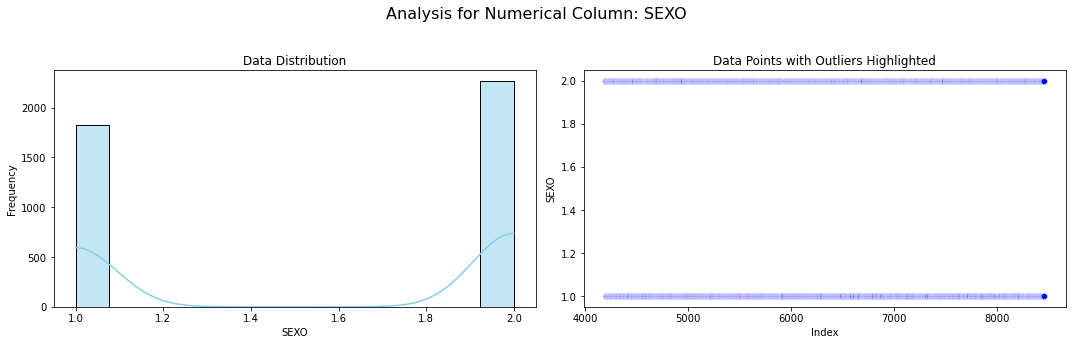


--- Column: EDAD ---
No outliers found.


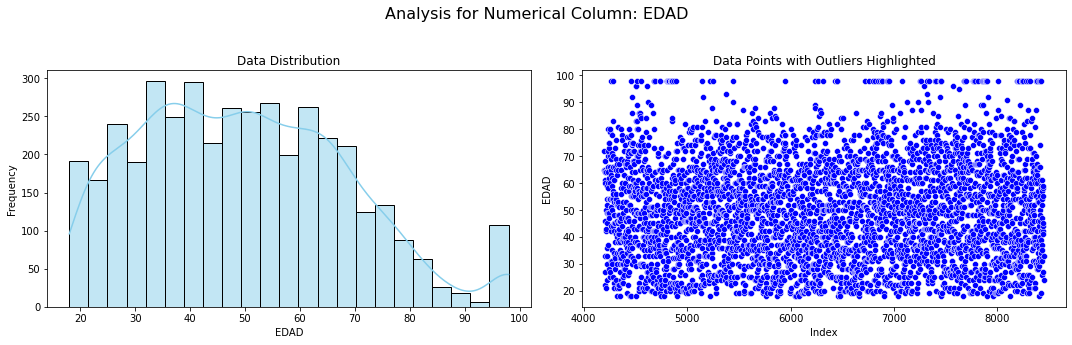


--- Column: BP1_1 ---
No outliers found.


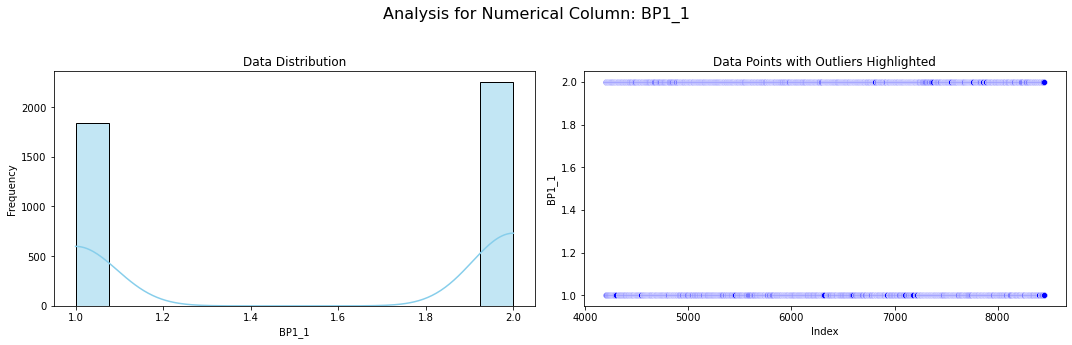


--- Column: BP1_2_01 ---
No outliers found.


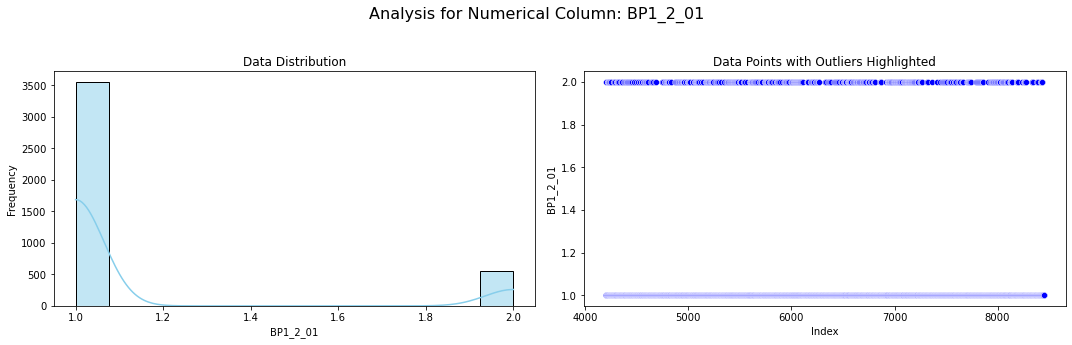


--- Column: BP1_2_03 ---
No outliers found.


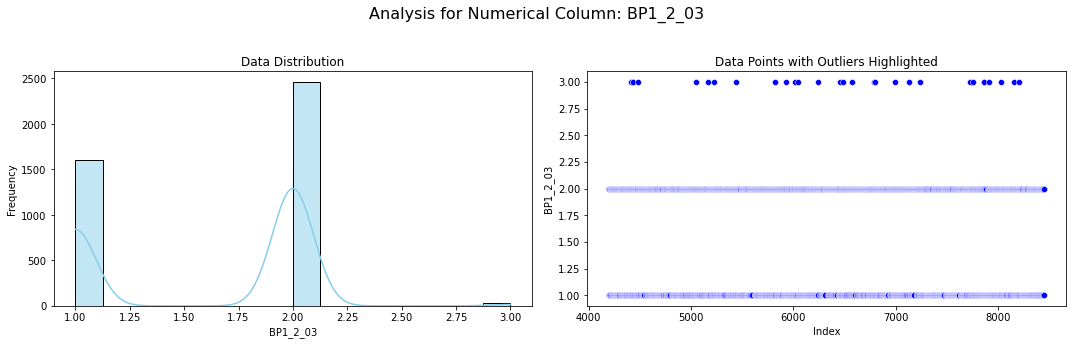


--- Column: BP1_4_1 ---
No outliers found.


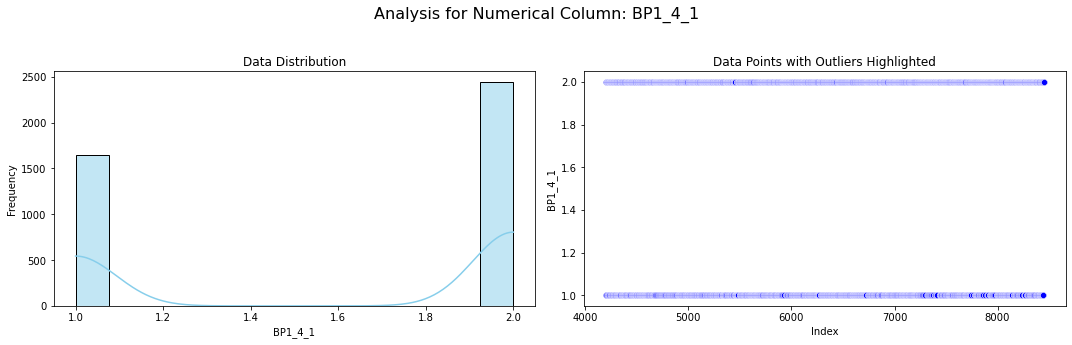


--- Column: BP1_4_2 ---
No outliers found.


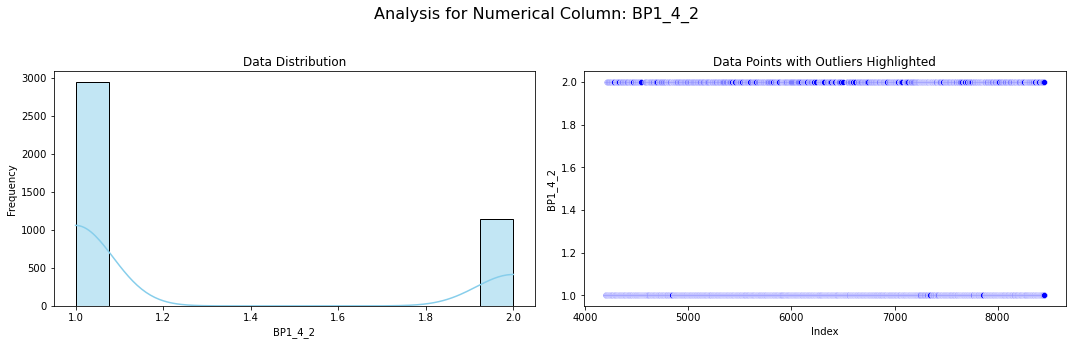


--- Column: BP1_4_3 ---
No outliers found.


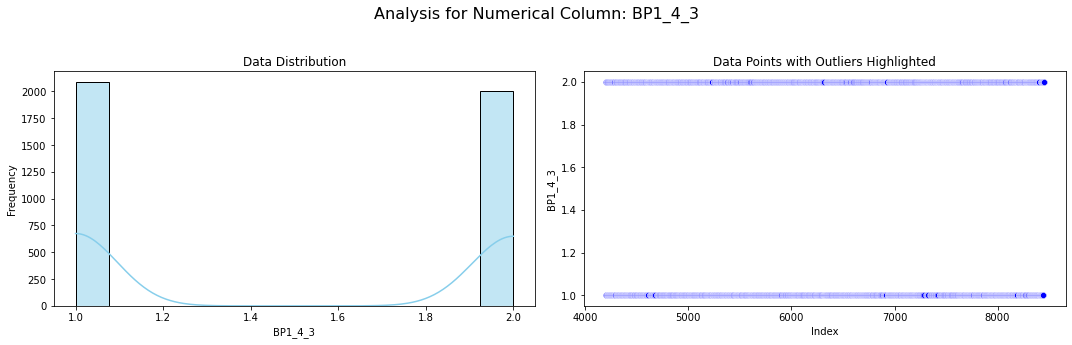


--- Column: BP1_4_4 ---
No outliers found.


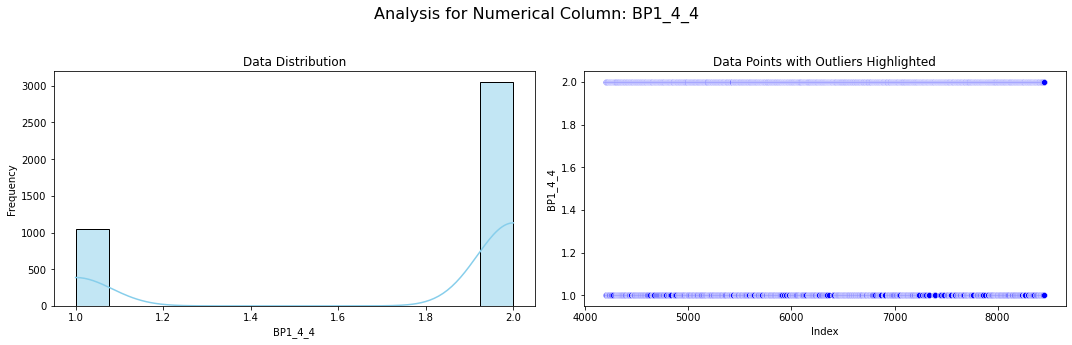


--- Column: BP1_4_5 ---
No outliers found.


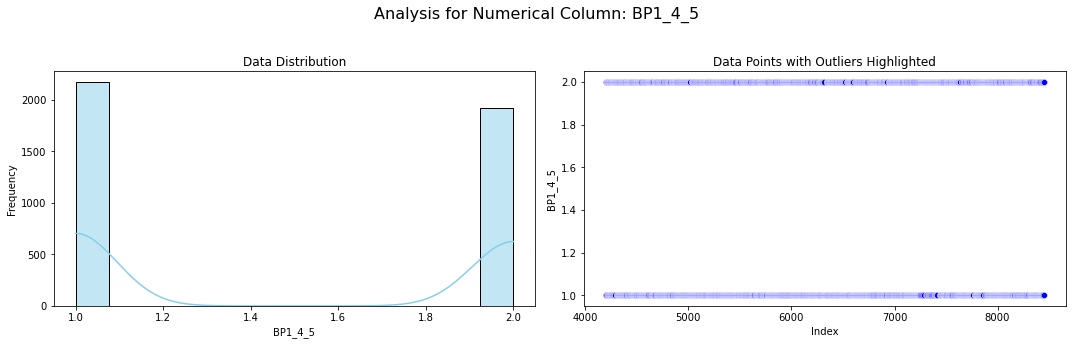


--- Column: BP1_4_6 ---
No outliers found.


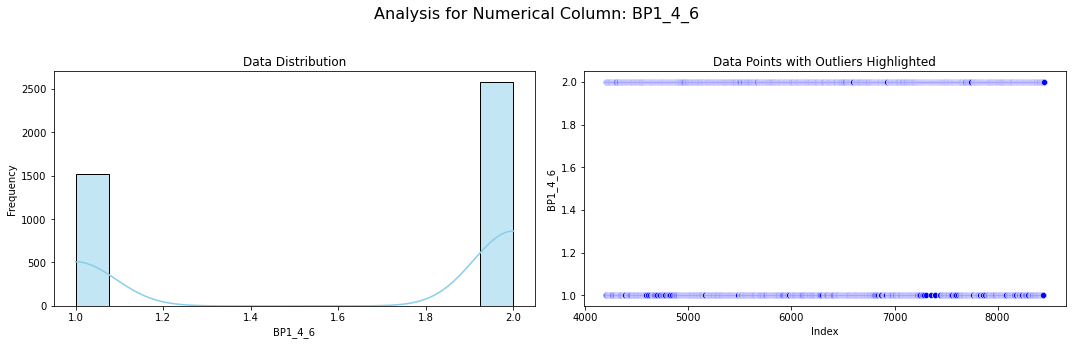


--- Column: BP1_4_7 ---
Found 202 outlier(s) (4.94% of data).
Outlier values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


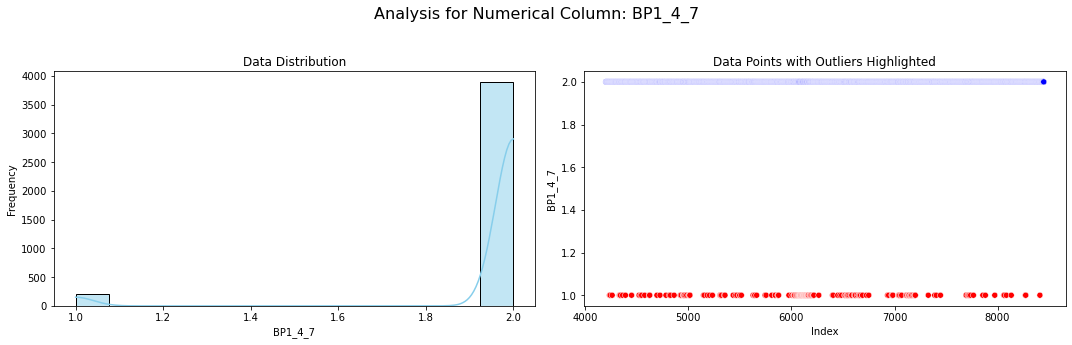


--- Column: BP1_4_8 ---
No outliers found.


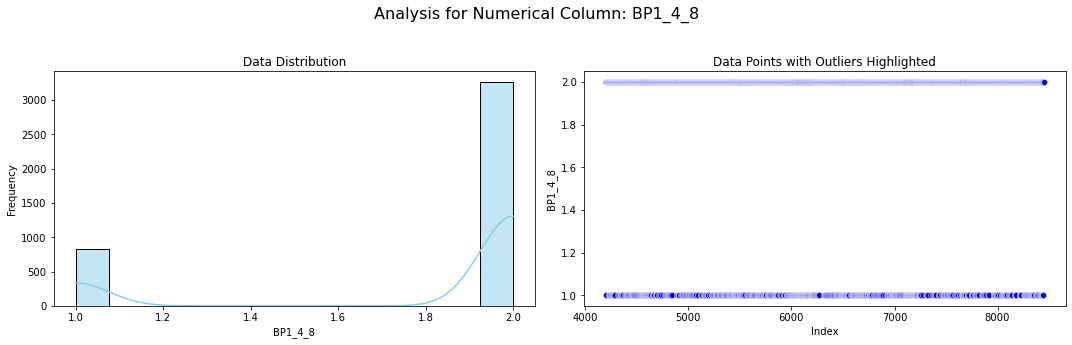


--- Column: BP1_5_1 ---
No outliers found.


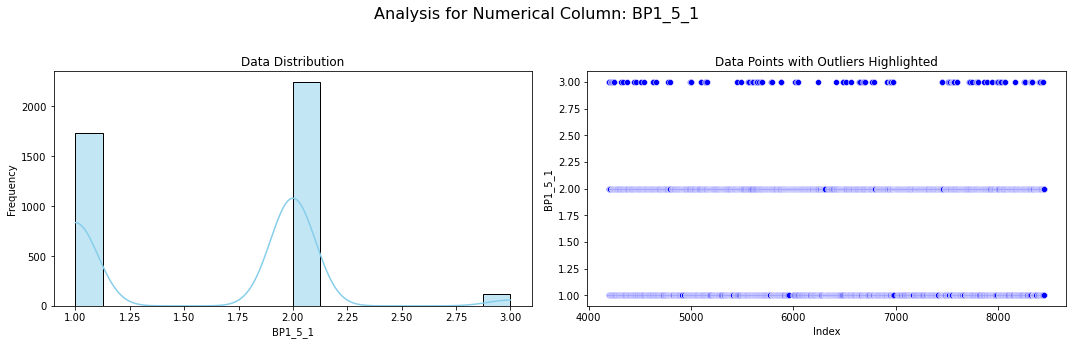


--- Column: BP1_5_2 ---
No outliers found.


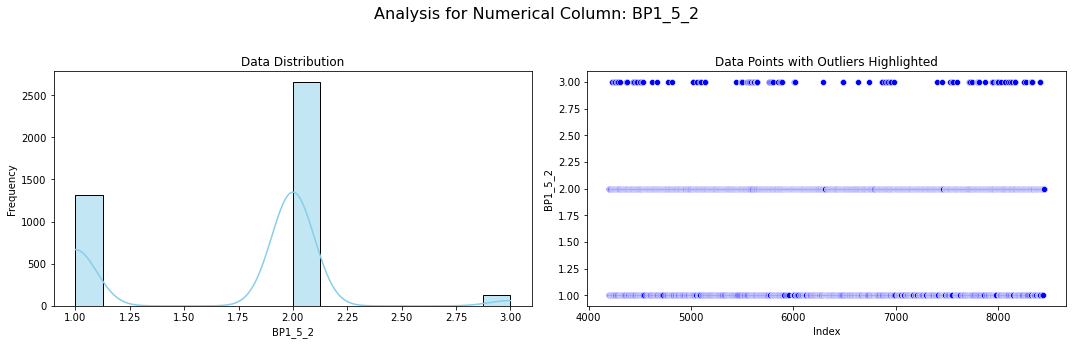


--- Column: BP1_6_4 ---
No outliers found.


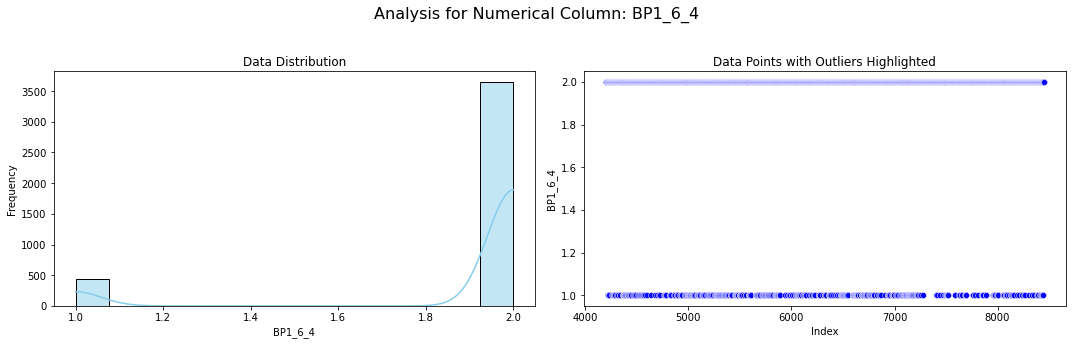

TypeError: loop of ufunc does not support argument 0 of type float which has no callable sqrt method

In [65]:
show_outliers_and_distributions(df)

In [66]:
def plot_value_counts_pie(df, column_name): 
    """ 
    Generates a pie chart for the value counts of a specified column and prints the details. 

    Args: 
        df (pd.DataFrame): The DataFrame containing the data. 
        column_name (str): The name of the column to analyze. 
    """ 
    # --- 1. Calculate Value Counts --- 
    # The value_counts() method returns a Series containing counts of unique values. 
    counts = df[column_name].value_counts() 

    # --- 2. Print Detailed Information --- 
    print(f"--- Analysis for column: '{column_name}' ---") 
    # To get percentages, we can use the `normalize=True` argument in value_counts(). [1, 6, 8] 
    # We multiply by 100 to get a percentage value. 
    percentages = df[column_name].value_counts(normalize=True).mul(100).round(1) 

    # We can combine counts and percentages into a single DataFrame for a clear overview. 
    summary_df = pd.DataFrame({'counts': counts, 'percentage': percentages}) 
    print(summary_df) 
    print("-" * 40) 

    # --- 3. Generate the Pie Plot --- 
    plt.figure(figsize=(10, 8)) 
    # The plot.pie() method can be directly called on the value_counts() Series. [2, 5, 7] 
    # `autopct` is used to format and display the percentage on each slice of the pie. [9] 
    counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                title=f'Distribution of {column_name}') 
    plt.ylabel('')  # This hides the y-axis label for a cleaner look. 
    plt.show() 


--- Analysis for column: 'NOM_MUN' ---
                        counts  percentage
XOCHIMILCO                 267         6.5
CUAUHTEMOC                 264         6.5
IZTACALCO                  260         6.4
LA MAGDALENA CONTRERAS     260         6.4
ALVARO OBREGON             260         6.4
TLALPAN                    260         6.4
MILPA ALTA                 258         6.3
VENUSTIANO CARRANZA        257         6.3
MIGUEL HIDALGO             256         6.3
TLAHUAC                    255         6.2
GUSTAVO A. MADERO          253         6.2
COYOACAN                   252         6.2
IZTAPALAPA                 250         6.1
BENITO JUAREZ              248         6.1
AZCAPOTZALCO               247         6.0
CUAJIMALPA DE MORELOS      241         5.9
----------------------------------------


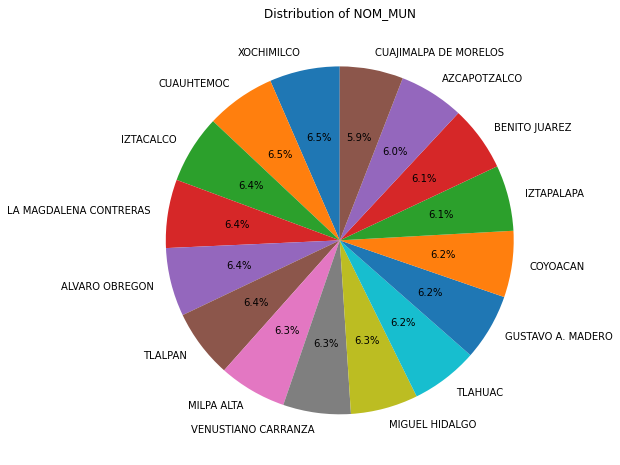

In [67]:
plot_value_counts_pie(df, 'NOM_MUN')

In [68]:
def analyze_counts_by_municipality_to_df(df, ignore_cols=None):
    """
    Performs a value_counts() on the 'NOM_MUN' column for each unique value
    in every other specified column and stores the results in a single DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame. Must contain a 'NOM_MUN' column.
        ignore_cols (list, optional): A list of column names to ignore from the analysis.
                                      Defaults to None.
    
    Returns:
        pd.DataFrame: A DataFrame with municipalities as the index and counts for
                      each condition in the columns. Returns None if 'NOM_MUN' is missing.
    """
    # Ensure 'NOM_MUN' column exists
    if 'NOM_MUN' not in df.columns:
        print("Error: DataFrame must contain a 'NOM_MUN' column.")
        return None

    # Initialize the ignore list. Use a copy to avoid modifying the original list.
    if ignore_cols is None:
        ignore_cols = []
    
    # 'NOM_MUN' should not be used as a condition column, so add it to the ignore list
    local_ignore_cols = ignore_cols.copy()
    if 'NOM_MUN' not in local_ignore_cols:
        local_ignore_cols.append('NOM_MUN')

    # Get the list of columns to analyze
    columns_to_analyze = [col for col in df.columns if col not in local_ignore_cols]

    # Get all unique municipalities to serve as the index for our results
    municipalities = df['NOM_MUN'].dropna().unique()
    
    # Create the initial DataFrame to store all results
    result_df = pd.DataFrame(index=municipalities)

    print(f"Starting analysis. Ignoring columns: {local_ignore_cols}")

    # Iterate over each column we want to analyze
    for col in columns_to_analyze:
        print(f"--- Processing column: '{col}' ---")
        
        # Find all unique values in the current column
        unique_values = df[col].dropna().unique()

        # Iterate over each unique value to use it as a filter
        for value in unique_values:
            # Filter the DataFrame where the column's value matches the current unique value
            filtered_df = df[df[col] == value]
            
            # Perform the value_counts on the 'NOM_MUN' column
            counts = filtered_df["NOM_MUN"].value_counts()

            # Create the new, descriptive column name
            new_col_name = f"{str(col)}_IS_{str(value)}"
            
            # Add the results as a new column to our main DataFrame.
            # Pandas will automatically align the counts based on the municipality index.
            result_df[new_col_name] = counts

    # After all loops, NaN values mean a count of 0 for that condition.
    # Fill NaN with 0 and convert to integer for a cleaner table.
    result_df = result_df.fillna(0).astype(int)
    
    print("\nAnalysis complete.")
    return result_df


In [69]:
df_counts_by_municipality = analyze_counts_by_municipality_to_df(df, ignore_cols=["EDAD", "NOM_ENT"])
df_counts_by_municipality_women = analyze_counts_by_municipality_to_df(df[df["SEXO"]==2], ignore_cols=["EDAD", "SEXO", "NOM_ENT"])
df_counts_by_municipality_men = analyze_counts_by_municipality_to_df(df[df["SEXO"]==1], ignore_cols=["EDAD", "SEXO", "NOM_ENT"])
df_counts_by_municipality

Starting analysis. Ignoring columns: ['EDAD', 'NOM_ENT', 'NOM_MUN']
--- Processing column: 'SEXO' ---
--- Processing column: 'BP1_1' ---
--- Processing column: 'BP1_2_01' ---
--- Processing column: 'BP1_2_03' ---
--- Processing column: 'BP1_4_1' ---
--- Processing column: 'BP1_4_2' ---
--- Processing column: 'BP1_4_3' ---
--- Processing column: 'BP1_4_4' ---
--- Processing column: 'BP1_4_5' ---
--- Processing column: 'BP1_4_6' ---
--- Processing column: 'BP1_4_7' ---
--- Processing column: 'BP1_4_8' ---
--- Processing column: 'BP1_5_1' ---
--- Processing column: 'BP1_5_2' ---
--- Processing column: 'BP1_6_4' ---
--- Processing column: 'BP2_2_03' ---
--- Processing column: 'BP2_2_11' ---
--- Processing column: 'BP2_2_14' ---
--- Processing column: 'BP3_1_05' ---
--- Processing column: 'BP3_1_07' ---
--- Processing column: 'BP3_1_08' ---
--- Processing column: 'BP3_1_10' ---
--- Processing column: 'BP3_1_11' ---
--- Processing column: 'BP3_1_13' ---
--- Processing column: 'BP3_1_14' ---


,SEXO_IS_2,SEXO_IS_1,BP1_1_IS_2,BP1_1_IS_1,BP1_2_01_IS_1,BP1_2_01_IS_2,BP1_2_03_IS_2,BP1_2_03_IS_1,BP1_2_03_IS_3,BP1_4_1_IS_2,...,BP4_1_1_IS_2,BP4_1_1_IS_1,BP4_1_2_IS_2,BP4_1_2_IS_1,BP4_1_3_IS_2,BP4_1_3_IS_1,BP4_1_7_IS_2,BP4_1_7_IS_1,BP4_1_8_IS_2,BP4_1_8_IS_1
AZCAPOTZALCO,124,123,165,82,211,36,146,98,3,138,...,223,24,245,2,241,6,238,9,238,9
COYOACAN,148,104,113,139,225,27,156,94,2,137,...,234,18,247,5,248,4,237,15,244,8
CUAJIMALPA DE MORELOS,121,120,85,156,214,27,128,112,1,178,...,203,38,239,2,238,3,231,10,233,8
GUSTAVO A. MADERO,133,120,164,89,211,42,166,85,2,148,...,228,25,251,2,247,6,245,8,240,13
IZTACALCO,141,119,161,99,223,37,174,85,1,147,...,222,38,255,5,254,6,246,14,246,14
IZTAPALAPA,130,120,169,81,207,43,163,86,1,112,...,222,28,248,2,246,4,240,10,243,7
LA MAGDALENA CONTRERAS,148,112,136,124,226,34,148,110,2,162,...,225,35,255,5,255,5,248,12,250,10
MILPA ALTA,148,110,136,122,212,46,141,115,2,147,...,232,26,256,2,251,7,249,9,244,14
ALVARO OBREGON,144,116,152,108,241,19,179,79,2,142,...,229,31,260,0,259,1,252,8,256,4
TLAHUAC,144,111,183,72,210,45,183,70,2,128,...,209,46,251,4,251,4,228,27,237,18


In [70]:
df_dictionary = pd.read_csv("./raw/security/DICCIONARIO_SEGURIDAD.csv")
df_dictionary

,NOMBRE_CAMPO,NEMONICO,TIPO,LONGITUD,RANGO_CLAVES,LABEL_CLAVES
0,Periodo,PER,Carácter,4,225,NaN
1,Identificador de vivienda seleccionada,ID_VIV,Alfanumérico,15,"0100001.0001.01,...,3299999.9999.05",NaN
2,Identificador de persona,ID_PER,Alfanumérico,18,"0100001.0001.01.01,...,3299999.9999.05.30",NaN
3,Identificador de viviendas para dar seguimient...,ID_VIVT,Alfanumérico,11,"0100001.001,...,3299999.999",NaN
4,Identificador de personas para dar seguimiento...,ID_PERT,Alfanumérico,14,"0100001.001.01,...., 3299999.999.30",NaN
...,...,...,...,...,...,...
514,Estrato,EST,Numérico,1,2,NaN
515,Estrato,EST,Numérico,1,3,NaN
516,Estrato,EST,Numérico,1,4,NaN
517,Unidad primaria de muestreo del diseño,UPM_DIS,Carácter,5,"00001,...,99999",NaN


In [71]:
df_dictionary = df_dictionary[df_dictionary["NEMONICO"].isin(selected_columns)]
df_dictionary

,NOMBRE_CAMPO,NEMONICO,TIPO,LONGITUD,RANGO_CLAVES,LABEL_CLAVES
40,Nombre de la Entidad Federativa,NOM_ENT,Texto,250,Texto mínimo 2 caracteres,NaN
42,Nombre del Municipio,NOM_MUN,Texto,250,Texto mínimo 2 caracteres,NaN
140,Sexo,SEXO,Numérico,1,1,Hombre
141,Sexo,SEXO,Numérico,1,2,Mujer
142,Edad,EDAD,Numérico,2,"18,...,96",NaN
...,...,...,...,...,...,...
502,"Situaciones de acoso: Le manosearon, tocaron, ...",BP4_1_7,Numérico,1,2,No
503,"Situaciones de acoso: Le manosearon, tocaron, ...",BP4_1_7,Numérico,1,9,No sabe / no responde
504,"Situaciones de acoso: Le enviaron mensajes, fo...",BP4_1_8,Numérico,1,1,Si
505,"Situaciones de acoso: Le enviaron mensajes, fo...",BP4_1_8,Numérico,1,2,No


In [72]:
print(df_dictionary.to_string())

                                                                                                                                                                                                                                                                NOMBRE_CAMPO  NEMONICO      TIPO  LONGITUD               RANGO_CLAVES                           LABEL_CLAVES
40                                                                                                                                                                                                                                           Nombre de la Entidad Federativa   NOM_ENT     Texto       250  Texto mínimo 2 caracteres                                    NaN
42                                                                                                                                                                                                                                                      Nombre del Municipio  

In [73]:
def plot_municipality_counts(df_counts, df_dict):
    """
    Generates grouped bar plots for municipality data based on a counts DataFrame
    and a data dictionary.

    Args:
        df_counts (pd.DataFrame): DataFrame with municipalities as the index and
                                  counts in columns named like 'NEMONICO_IS_VALUE'.
        df_dict (pd.DataFrame): Data dictionary containing metadata with columns
                                'NEMONICO', 'NOMBRE_CAMPO', 'RANGO_CLAVES', 
                                and 'LABEL_CLAVES'.
    """
    # --- 1. Identify the unique NEMONICOs to create a plot for each ---
    # Parse column names like 'SEXO_IS_2' into ('SEXO', '2')
    col_parts = df_counts.columns.str.split('_IS_', expand=True)
    unique_nemonicos = col_parts.get_level_values(0).unique()

    print(f"Found {len(unique_nemonicos)} categories to plot: {list(unique_nemonicos)}")

    # --- 2. Loop through each unique NEMONICO and create a plot ---
    for nemonico in unique_nemonicos:
        print(f"\nGenerating plot for: {nemonico}")
        
        # --- 3. Filter data for the current NEMONICO ---
        # Select all columns that start with the current NEMONICO (e.g., 'SEXO_IS_')
        cols_for_plot = [col for col in df_counts.columns if col.startswith(nemonico + '_IS_')]
        subset_df = df_counts[cols_for_plot]

        # --- 4. Use the dictionary to get metadata for titles and labels ---
        dict_subset = df_dict[df_dict['NEMONICO'] == nemonico]
        
        if dict_subset.empty:
            print(f"  - Warning: Could not find metadata for '{nemonico}' in the dictionary. Using default names.")
            plot_title = nemonico
            # Use original column names for the legend
            plot_df = subset_df
        else:
            # Get the full name for the plot title (assuming it's the same for all rows of a NEMONICO)
            nombre_campo = dict_subset['NOMBRE_CAMPO'].iloc[0]
            plot_title = f"{nombre_campo} ({nemonico})"

            # --- 5. Create a mapping to rename columns for a clear legend ---
            # e.g., 'SEXO_IS_1' -> 'Hombre'
            label_map = {}
            for col_name in cols_for_plot:
                # Get the value part, e.g., '1' from 'SEXO_IS_1'
                value = col_name.split('_IS_')[1]
                
                # Find the matching label in the dictionary
                # We convert both to string to ensure a match
                label_row = dict_subset[dict_subset['RANGO_CLAVES'].astype(str) == str(value)]
                
                if not label_row.empty:
                    label_map[col_name] = label_row['LABEL_CLAVES'].iloc[0]
                else:
                    # Fallback if a specific value isn't in the dictionary
                    label_map[col_name] = col_name 
            
            # Apply the new names to our data subset for plotting
            plot_df = subset_df.rename(columns=label_map)

        # --- 6. Generate the plot ---
        plot_df.plot(
            kind='bar',
            figsize=(18, 8),  # Wider figure to accommodate municipality names
            width=0.8
        )

        # --- 7. Customize the plot with titles and labels ---
        plt.title(plot_title, fontsize=16, pad=20)
        plt.xlabel("Municipality", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
        plt.legend(title='Response')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout() # Adjust plot to ensure everything fits
        
        # Display the plot
        plt.show()

Found 30 categories to plot: ['SEXO', 'BP1_1', 'BP1_2_01', 'BP1_2_03', 'BP1_4_1', 'BP1_4_2', 'BP1_4_3', 'BP1_4_4', 'BP1_4_5', 'BP1_4_6', 'BP1_4_7', 'BP1_4_8', 'BP1_5_1', 'BP1_5_2', 'BP1_6_4', 'BP2_2_03', 'BP2_2_11', 'BP2_2_14', 'BP3_1_05', 'BP3_1_07', 'BP3_1_08', 'BP3_1_10', 'BP3_1_11', 'BP3_1_13', 'BP3_1_14', 'BP4_1_1', 'BP4_1_2', 'BP4_1_3', 'BP4_1_7', 'BP4_1_8']

Generating plot for: SEXO


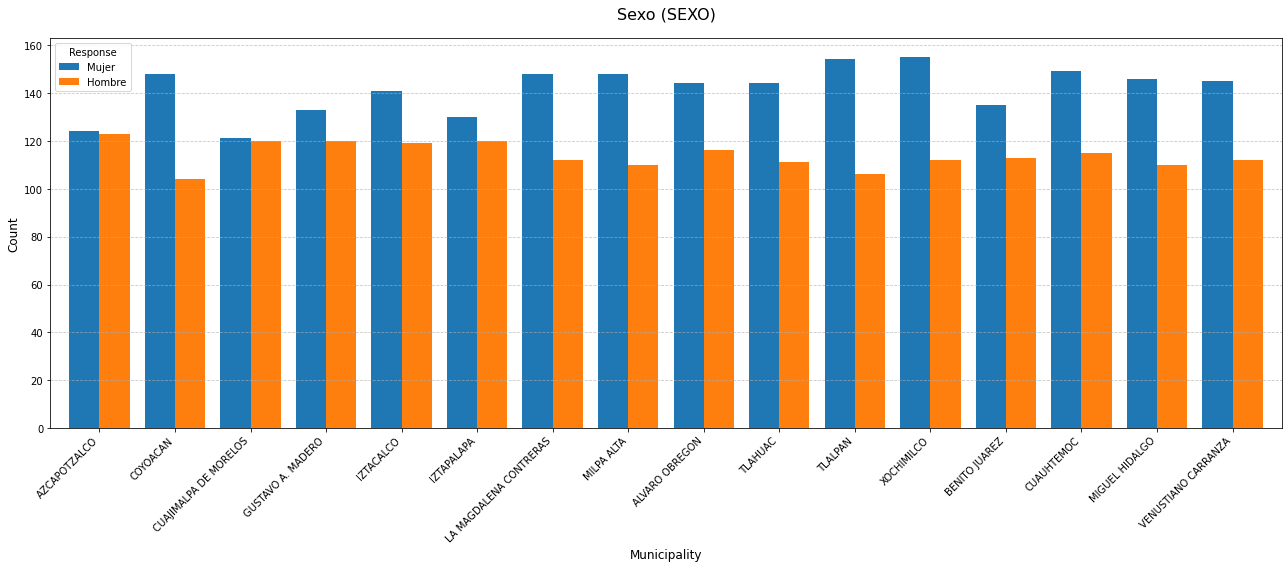


Generating plot for: BP1_1


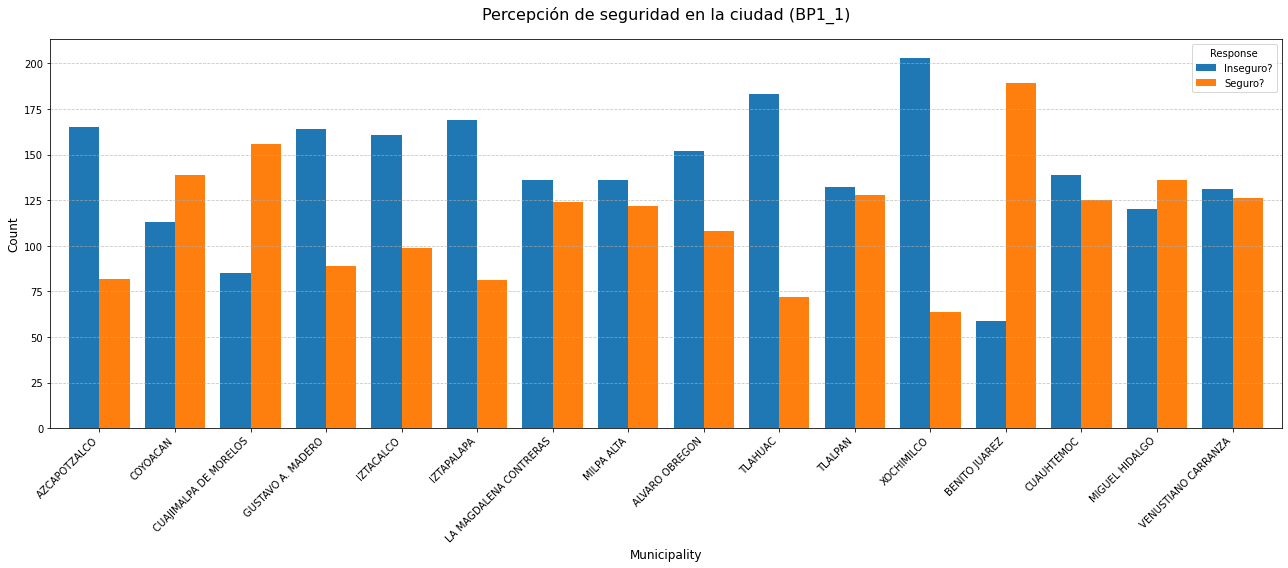


Generating plot for: BP1_2_01


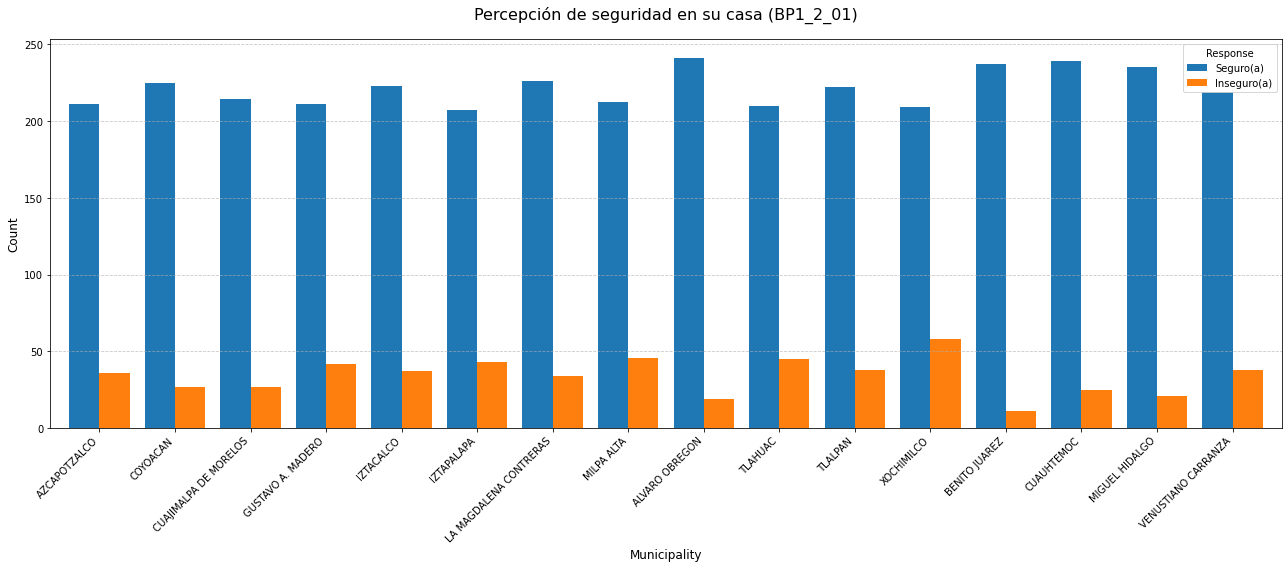


Generating plot for: BP1_2_03


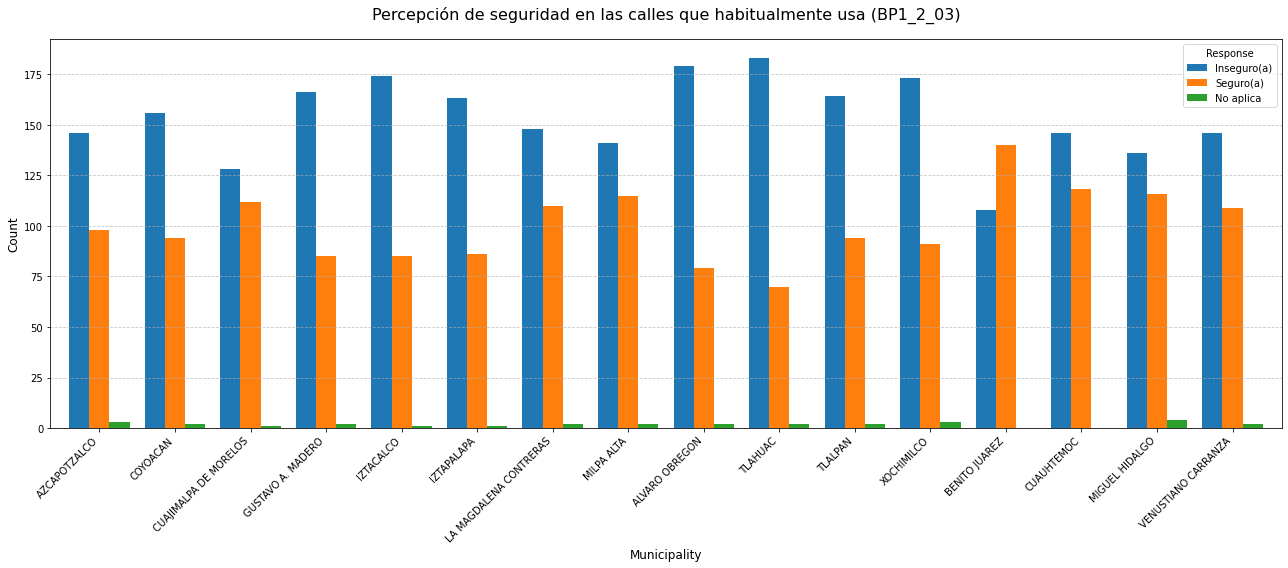


Generating plot for: BP1_4_1


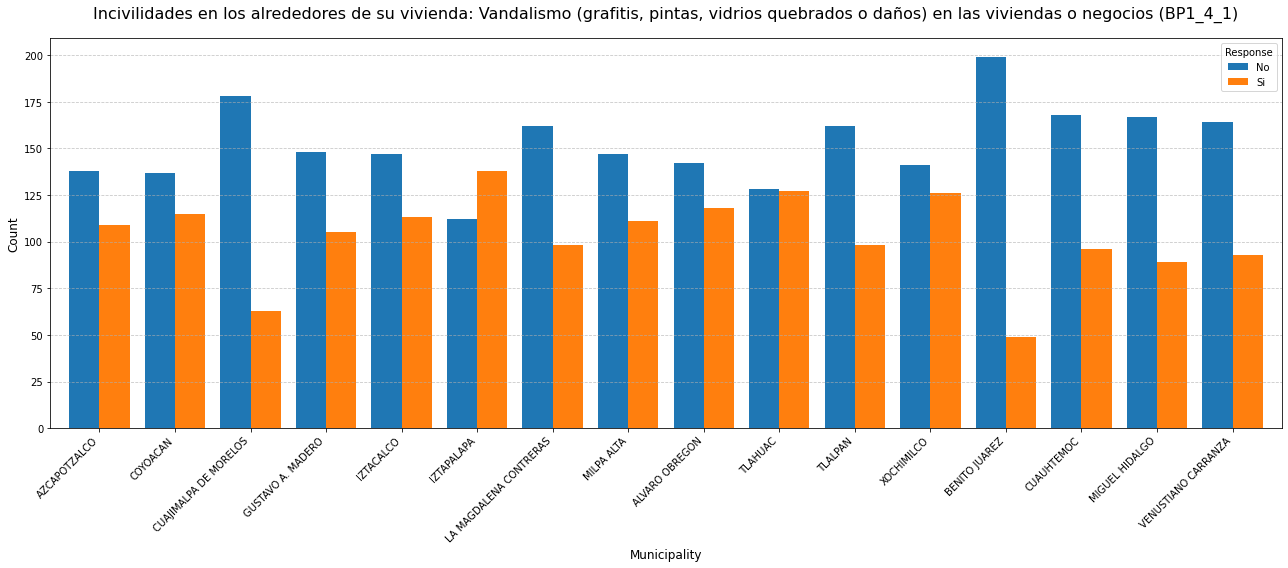


Generating plot for: BP1_4_2


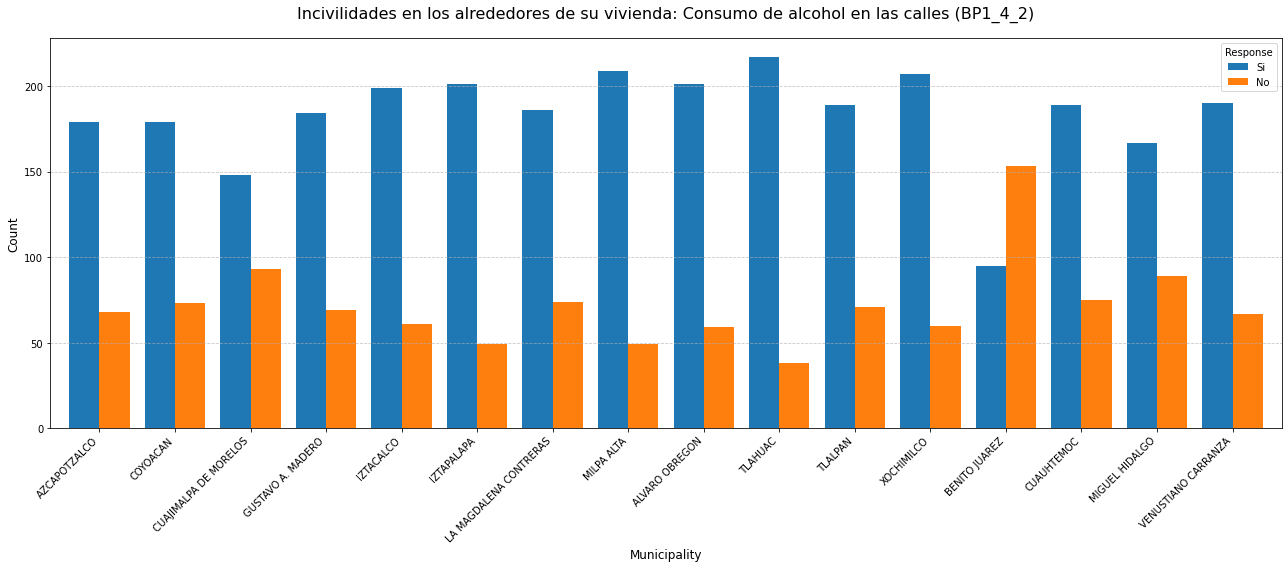


Generating plot for: BP1_4_3


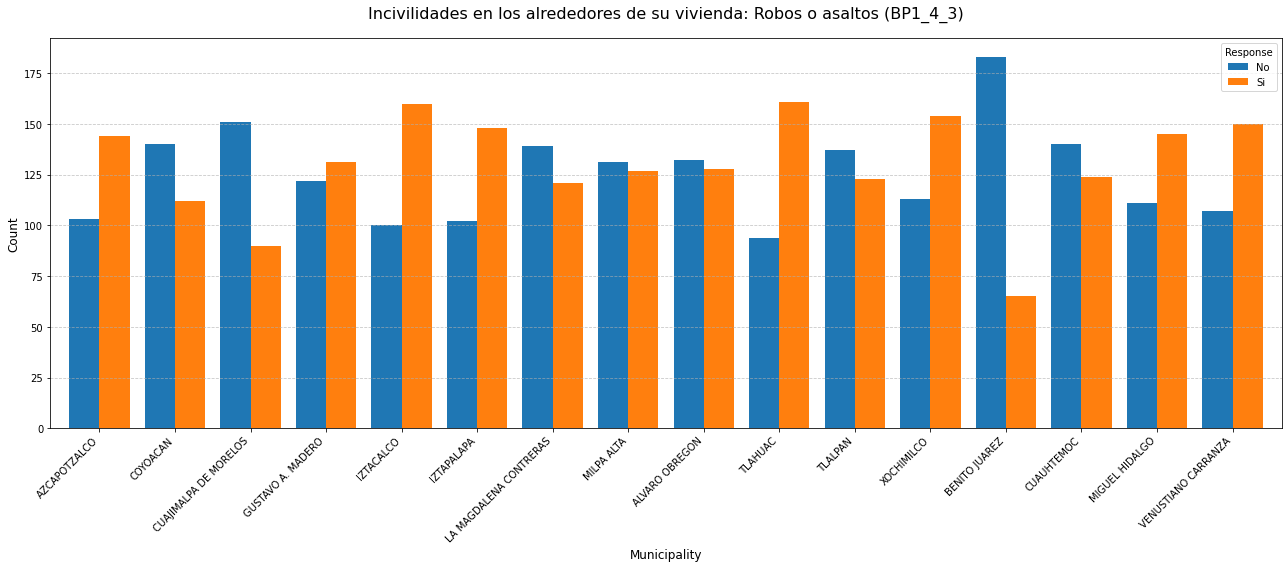


Generating plot for: BP1_4_4


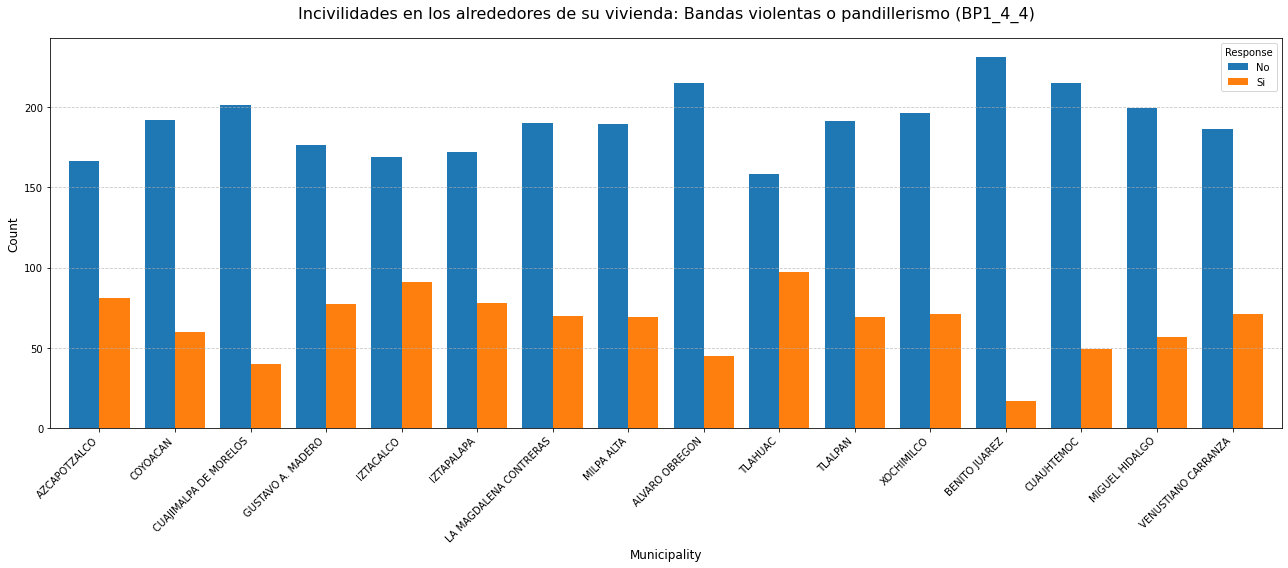


Generating plot for: BP1_4_5


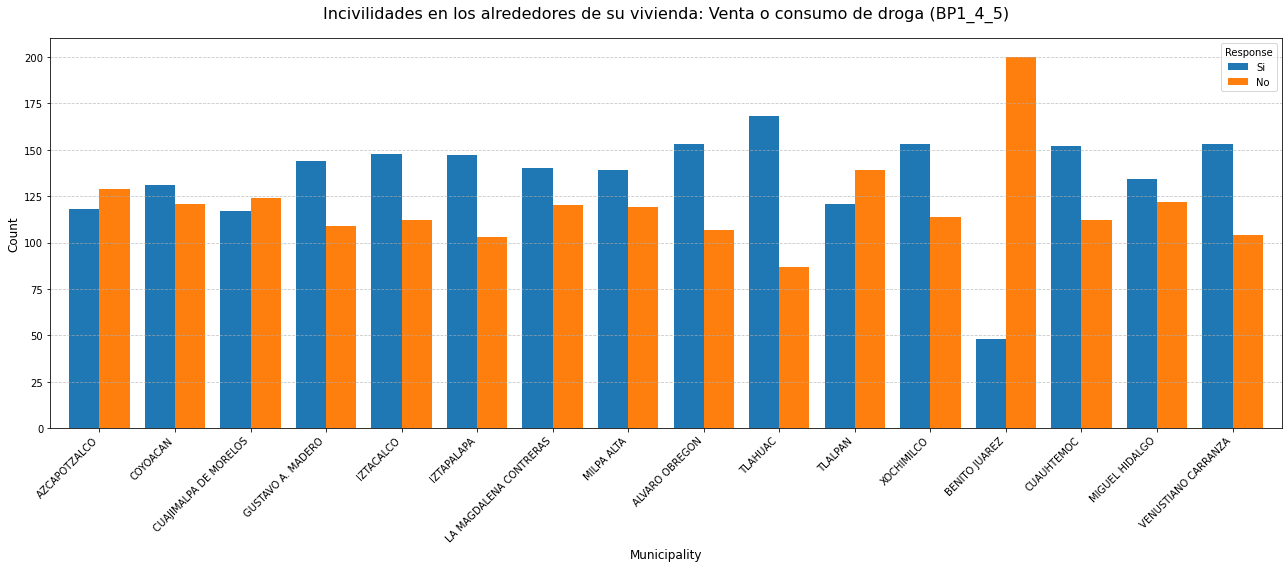


Generating plot for: BP1_4_6


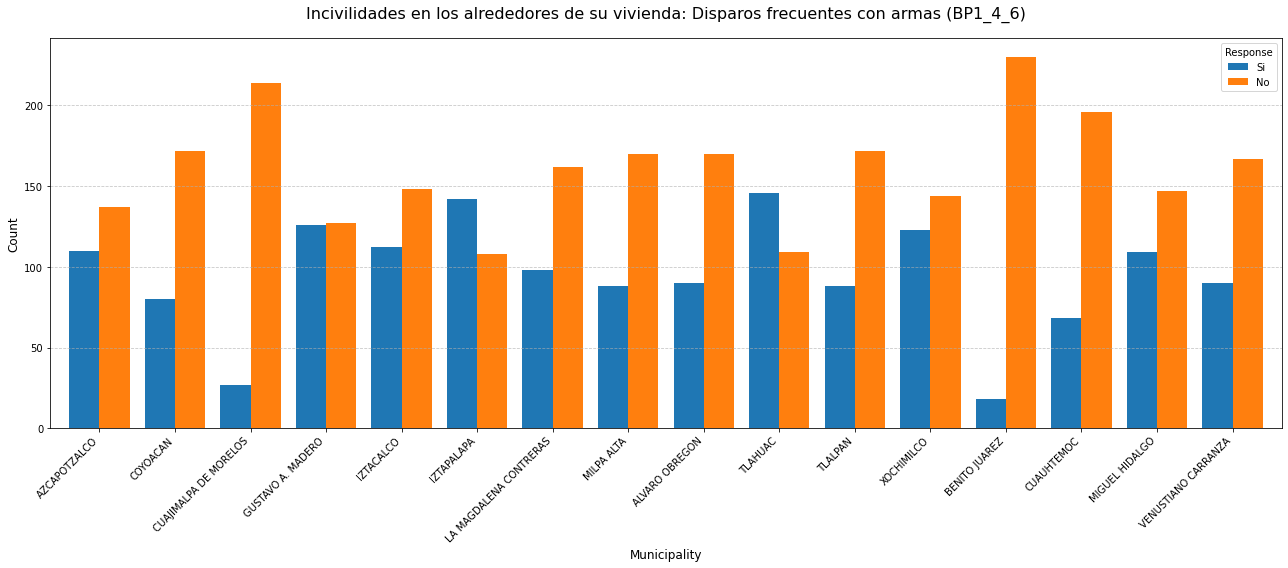


Generating plot for: BP1_4_7


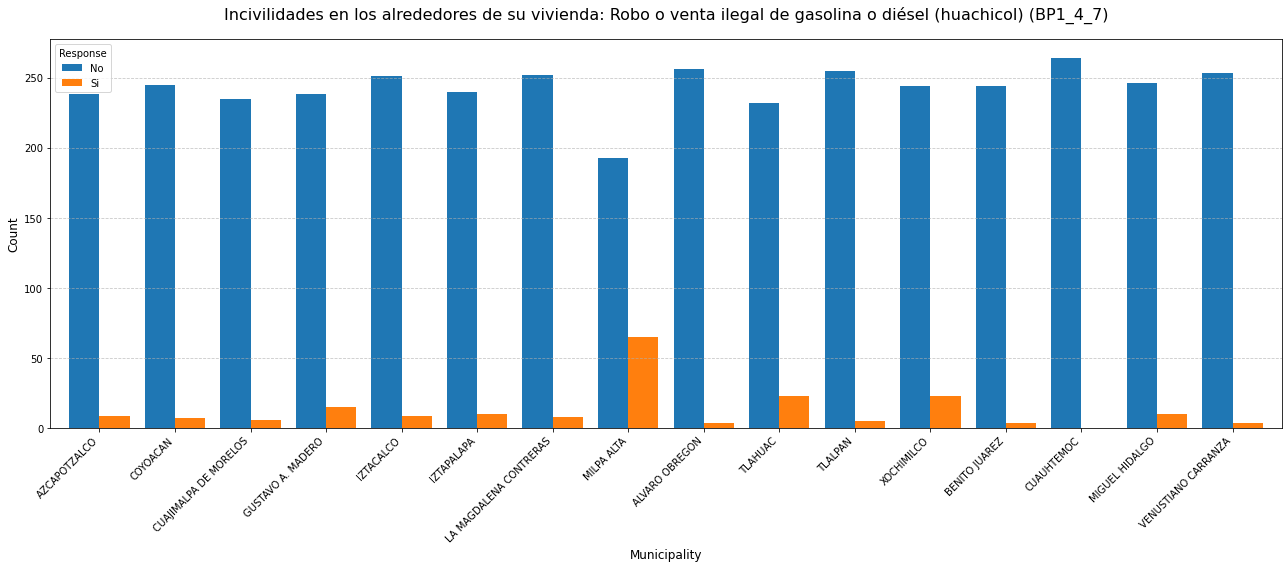


Generating plot for: BP1_4_8


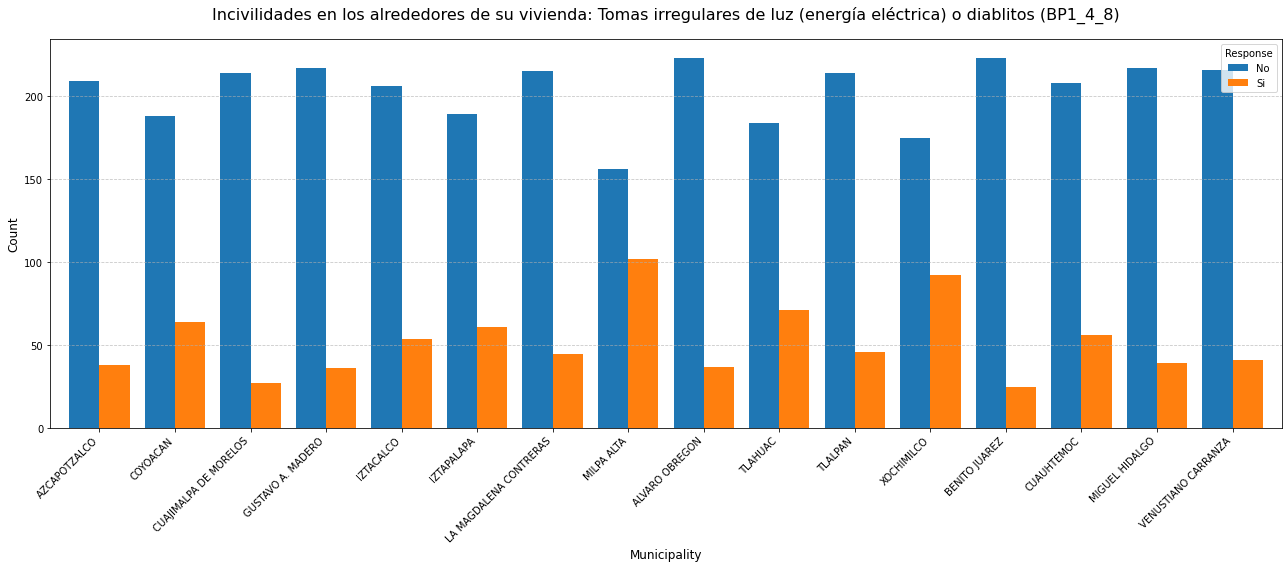


Generating plot for: BP1_5_1


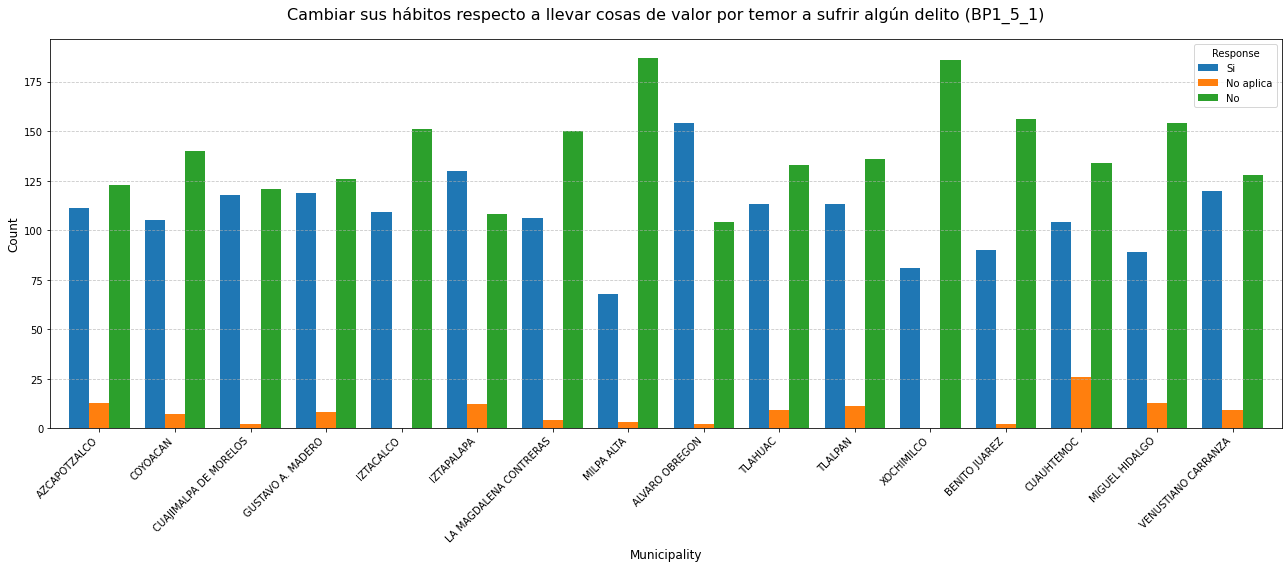


Generating plot for: BP1_5_2


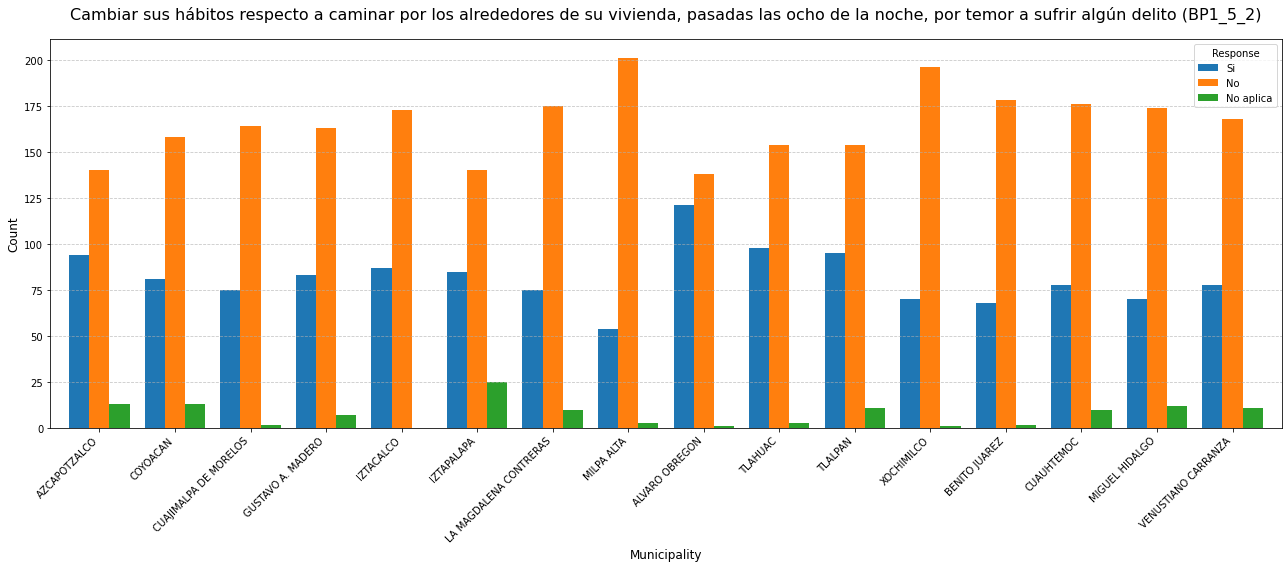


Generating plot for: BP1_6_4


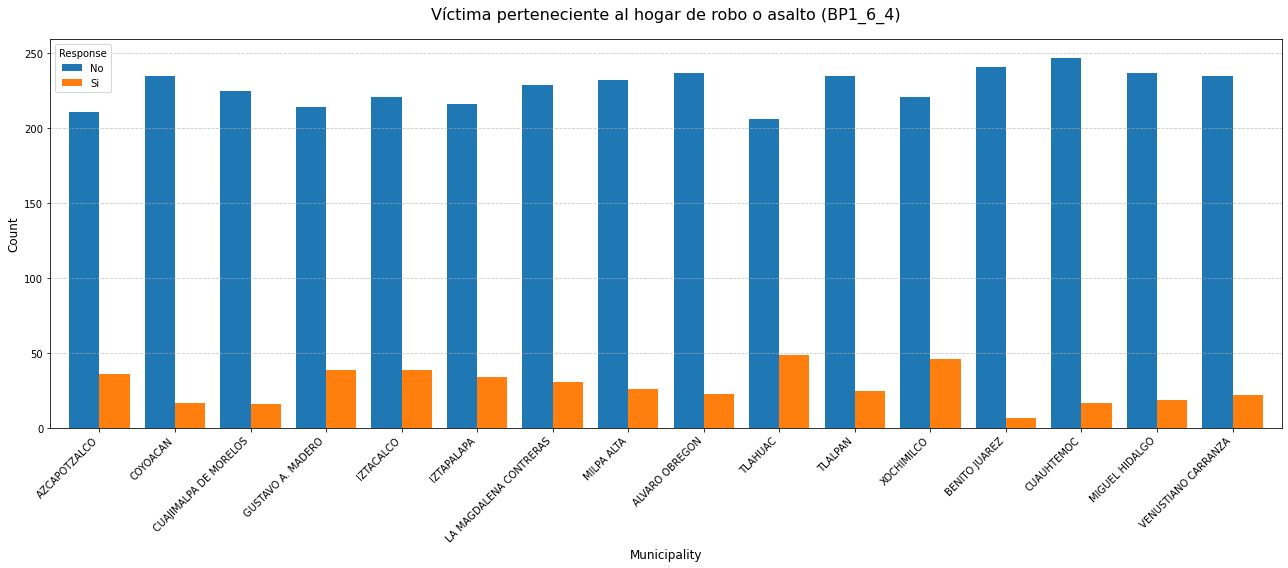


Generating plot for: BP2_2_03


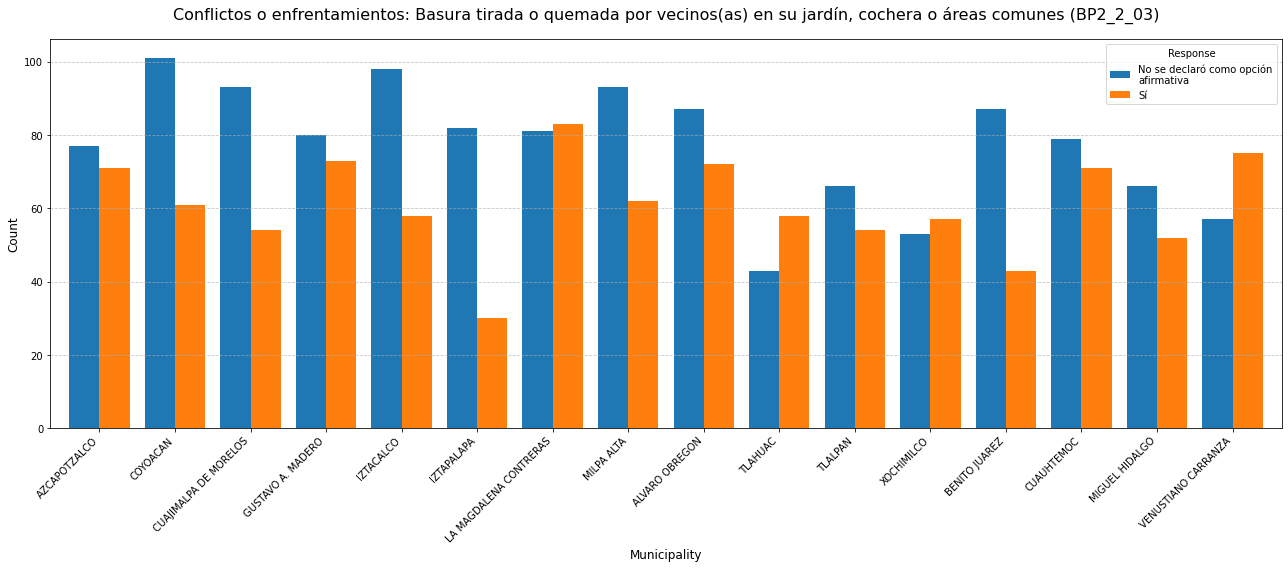


Generating plot for: BP2_2_11


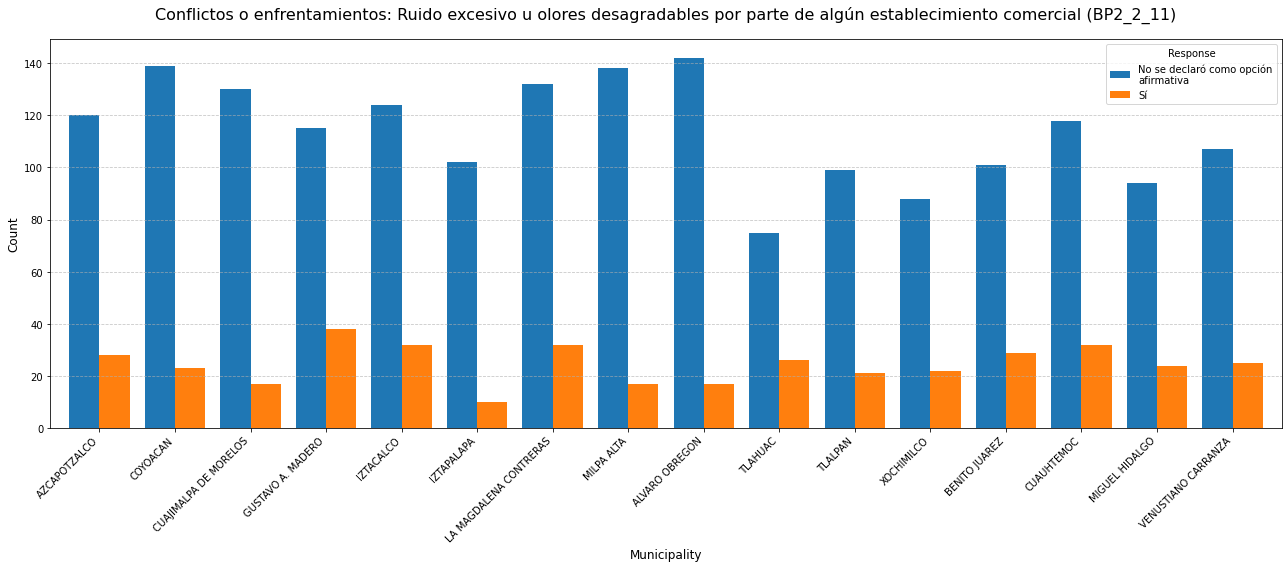


Generating plot for: BP2_2_14


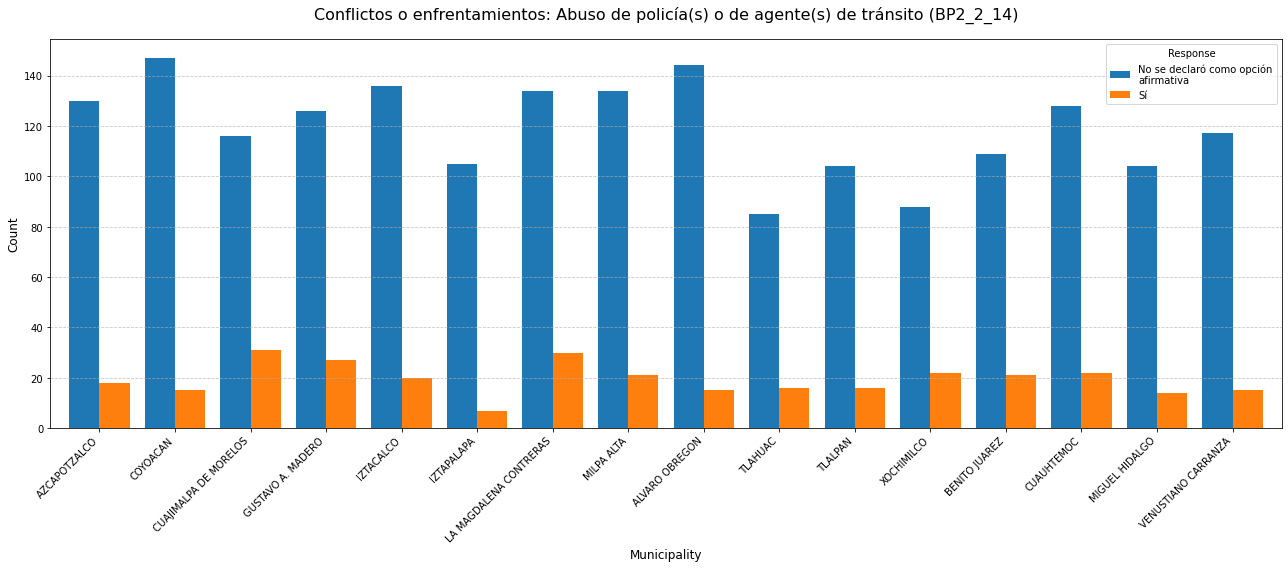


Generating plot for: BP3_1_05


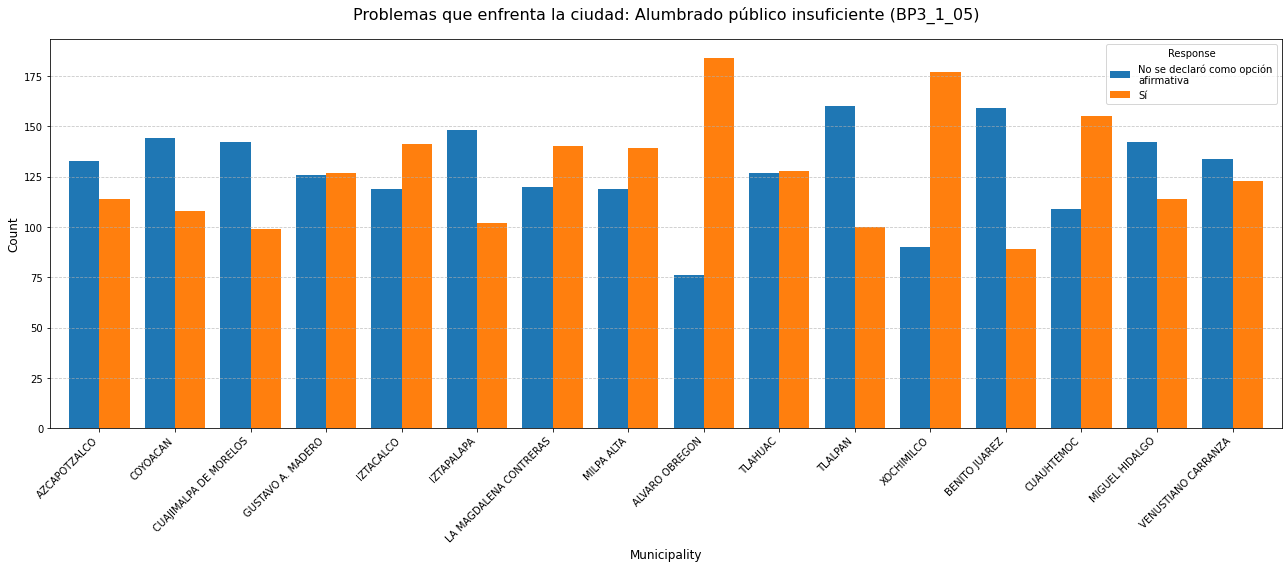


Generating plot for: BP3_1_07


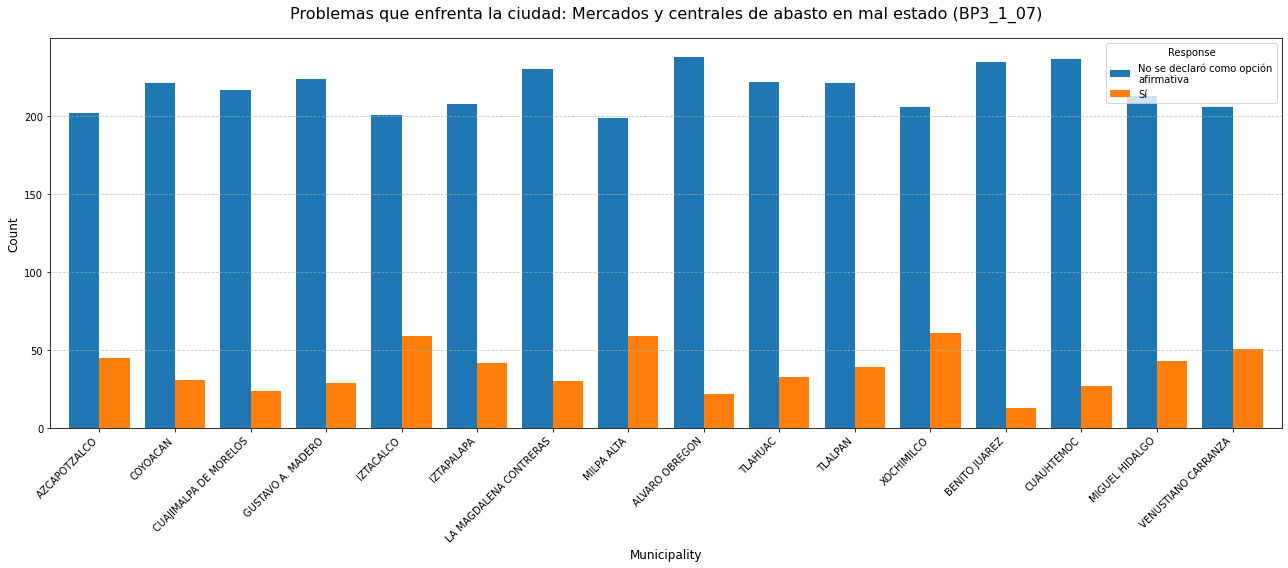


Generating plot for: BP3_1_08


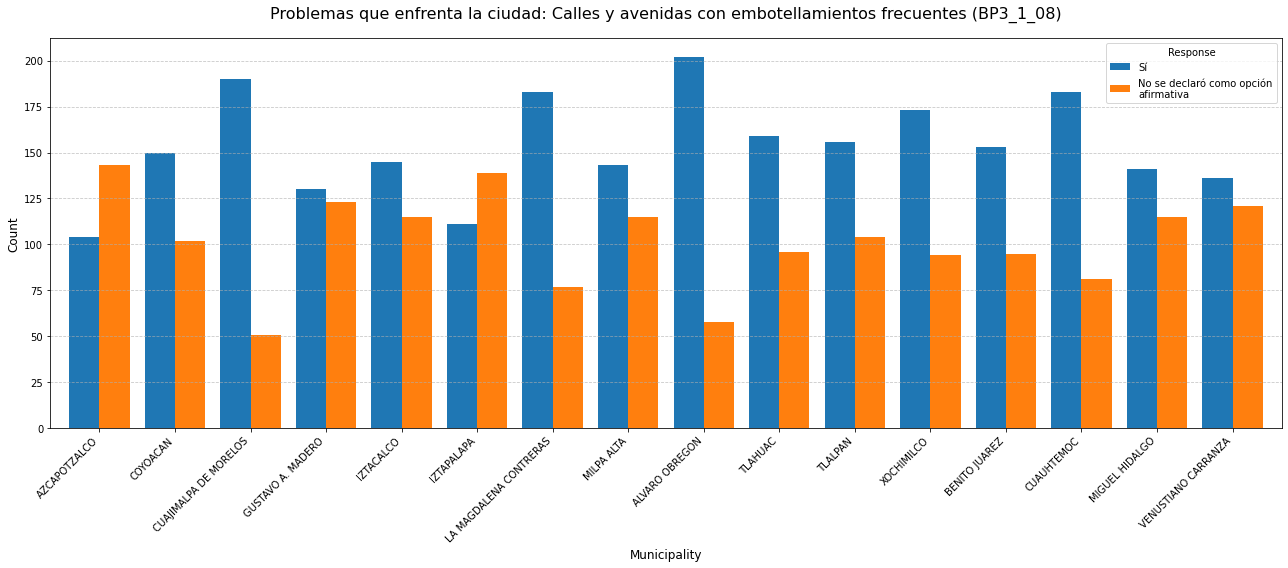


Generating plot for: BP3_1_10


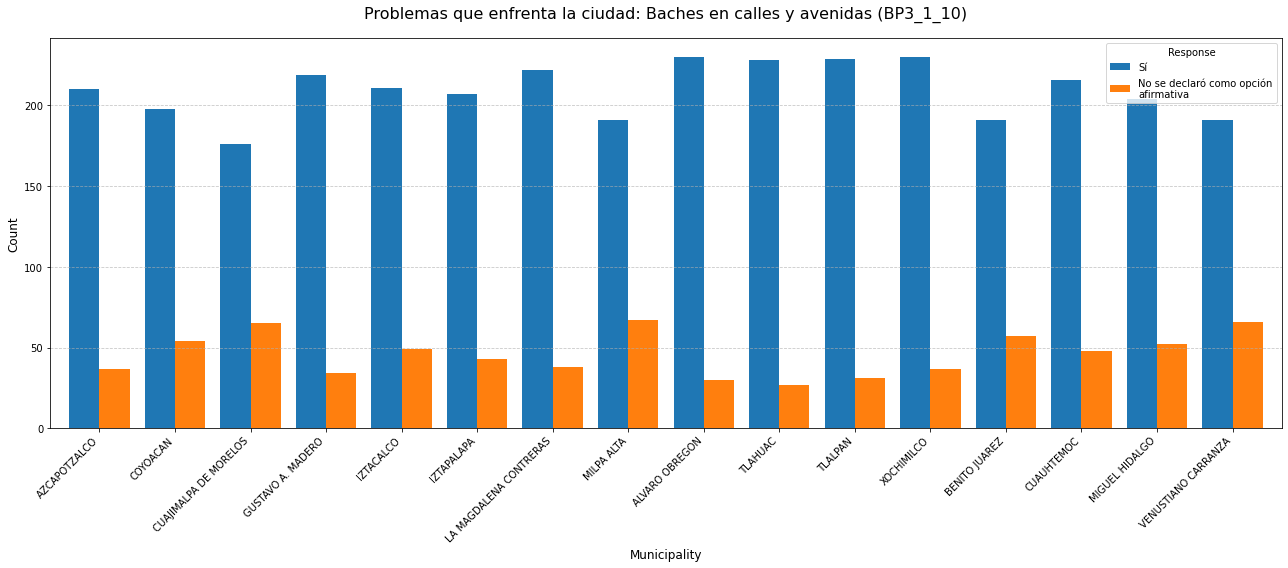


Generating plot for: BP3_1_11


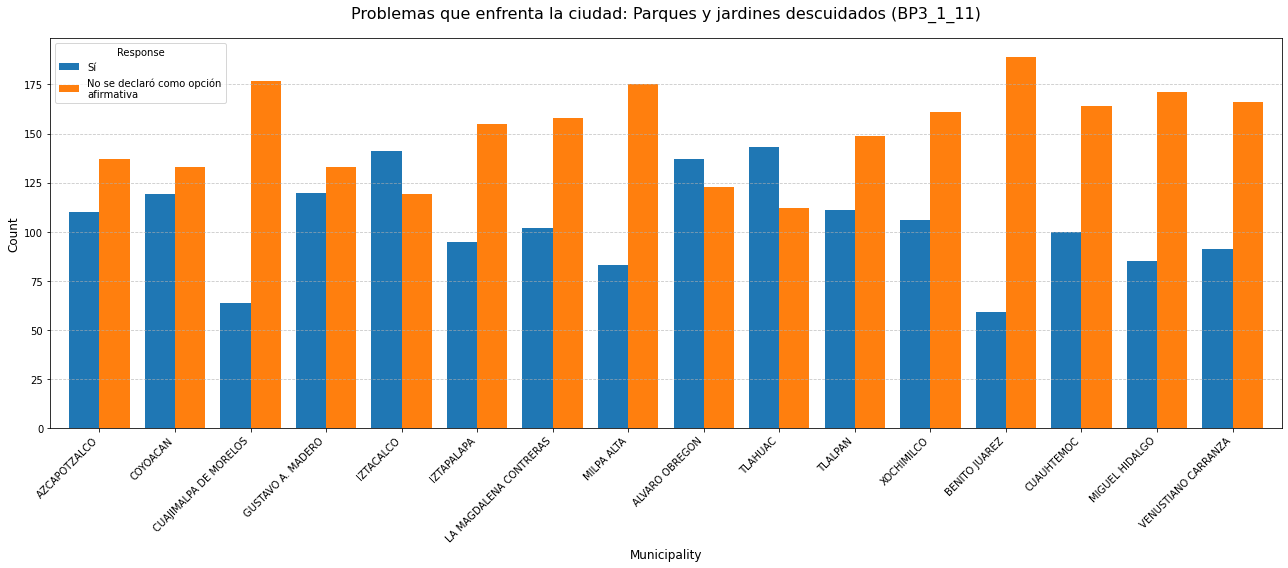


Generating plot for: BP3_1_13


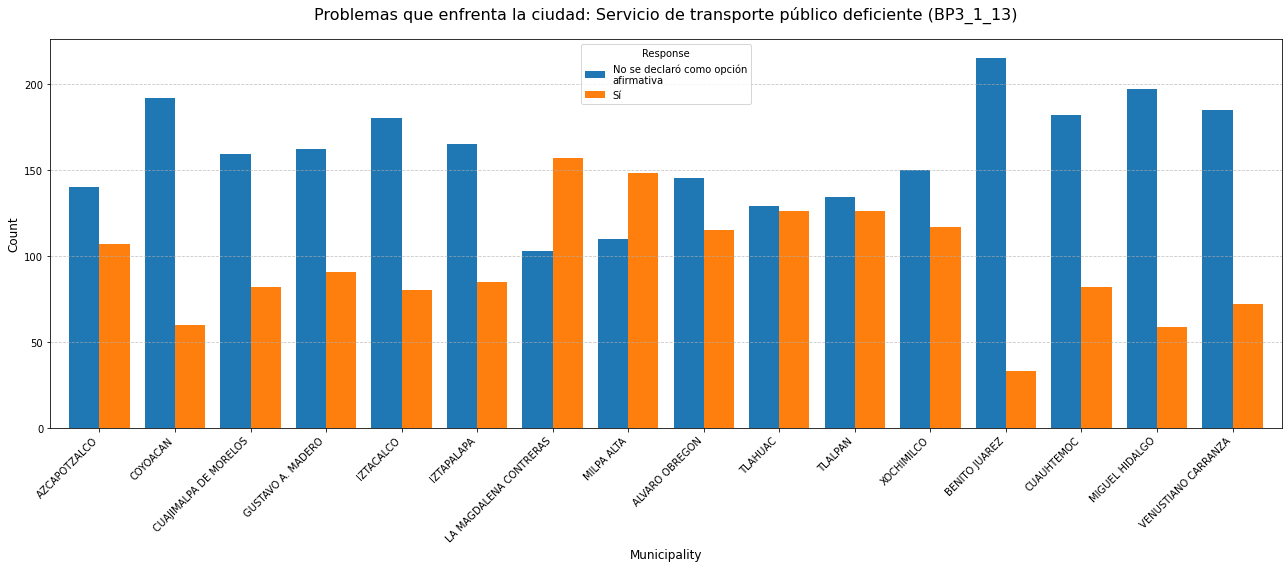


Generating plot for: BP3_1_14


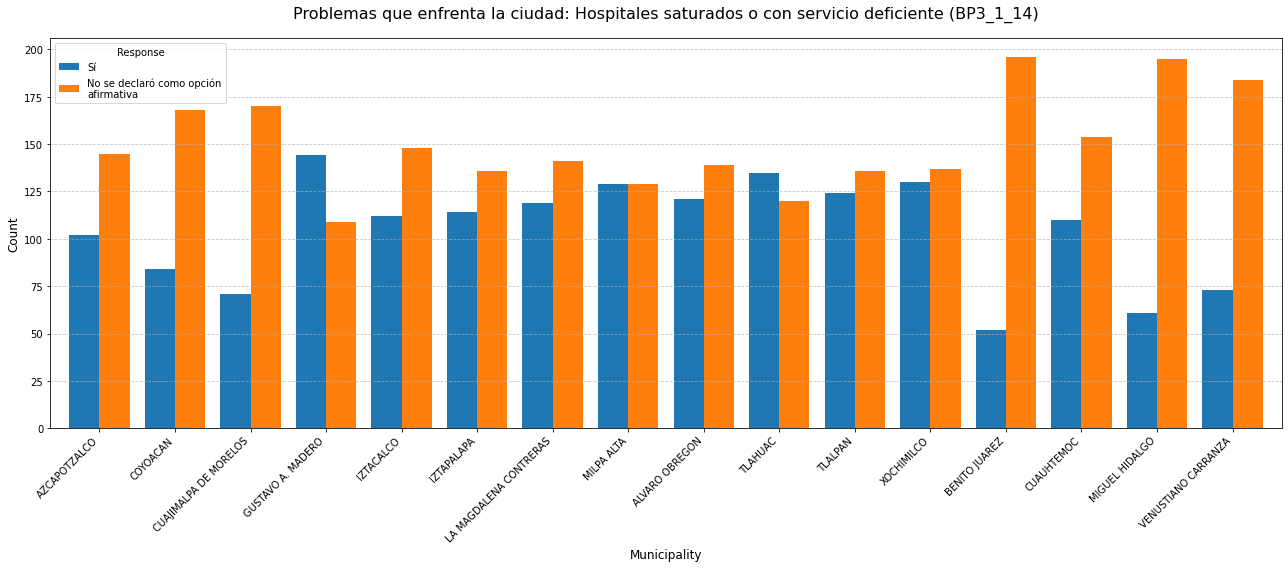


Generating plot for: BP4_1_1


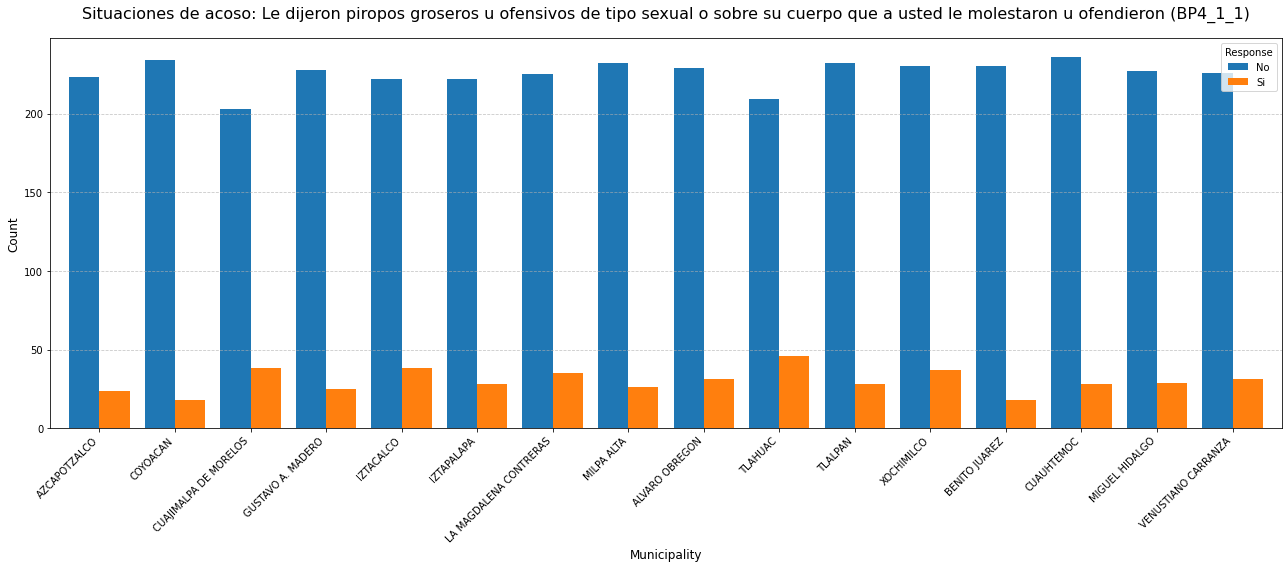


Generating plot for: BP4_1_2


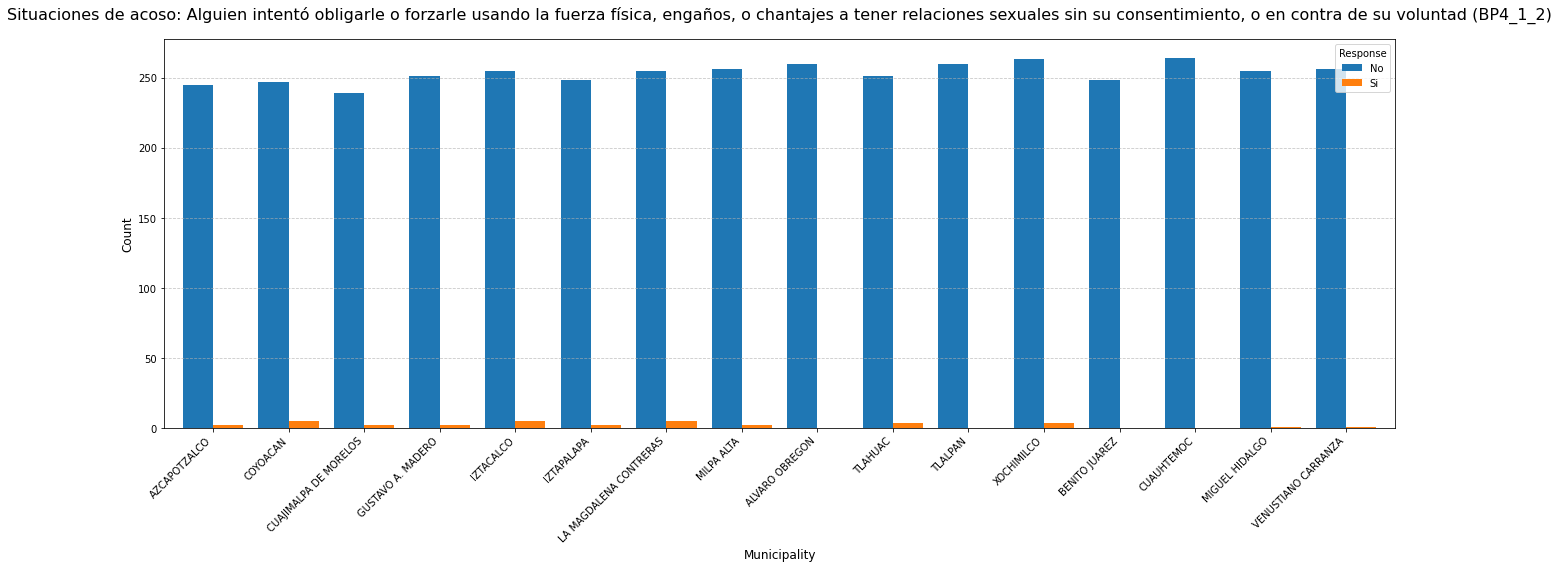


Generating plot for: BP4_1_3


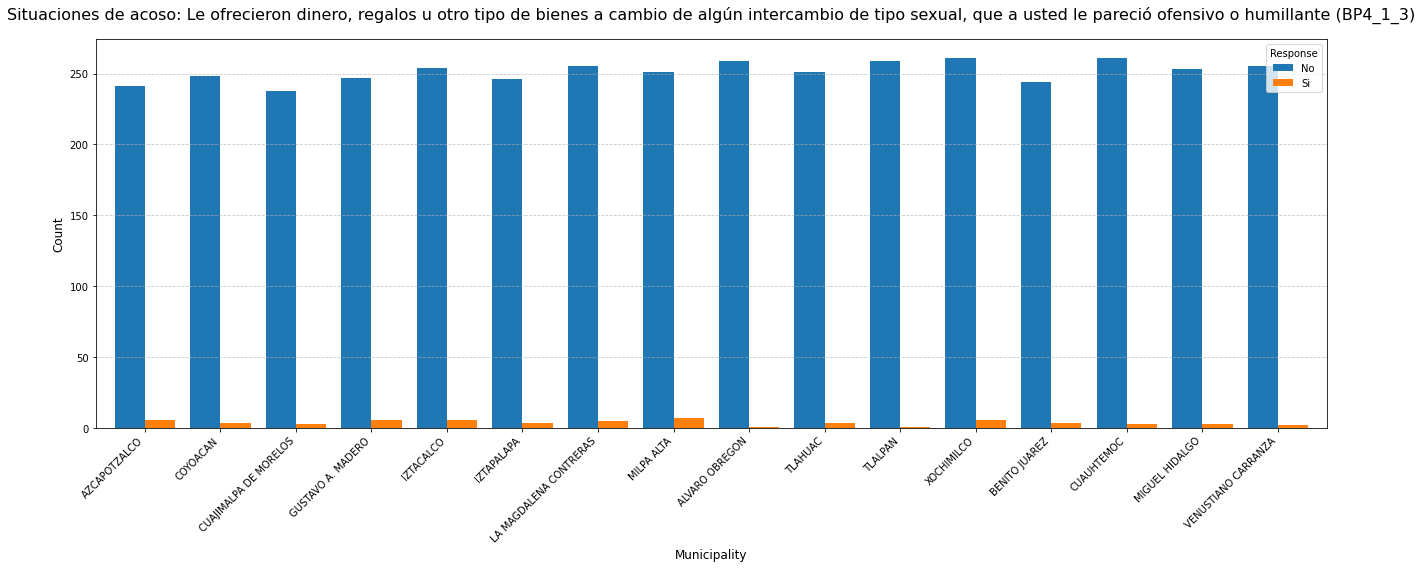


Generating plot for: BP4_1_7


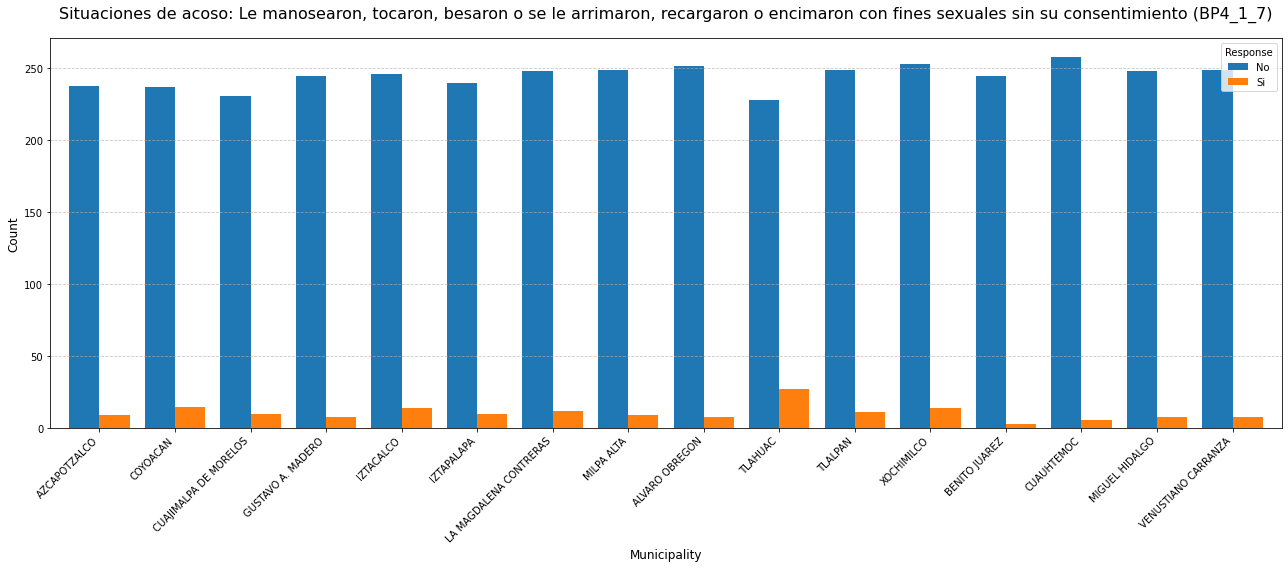


Generating plot for: BP4_1_8


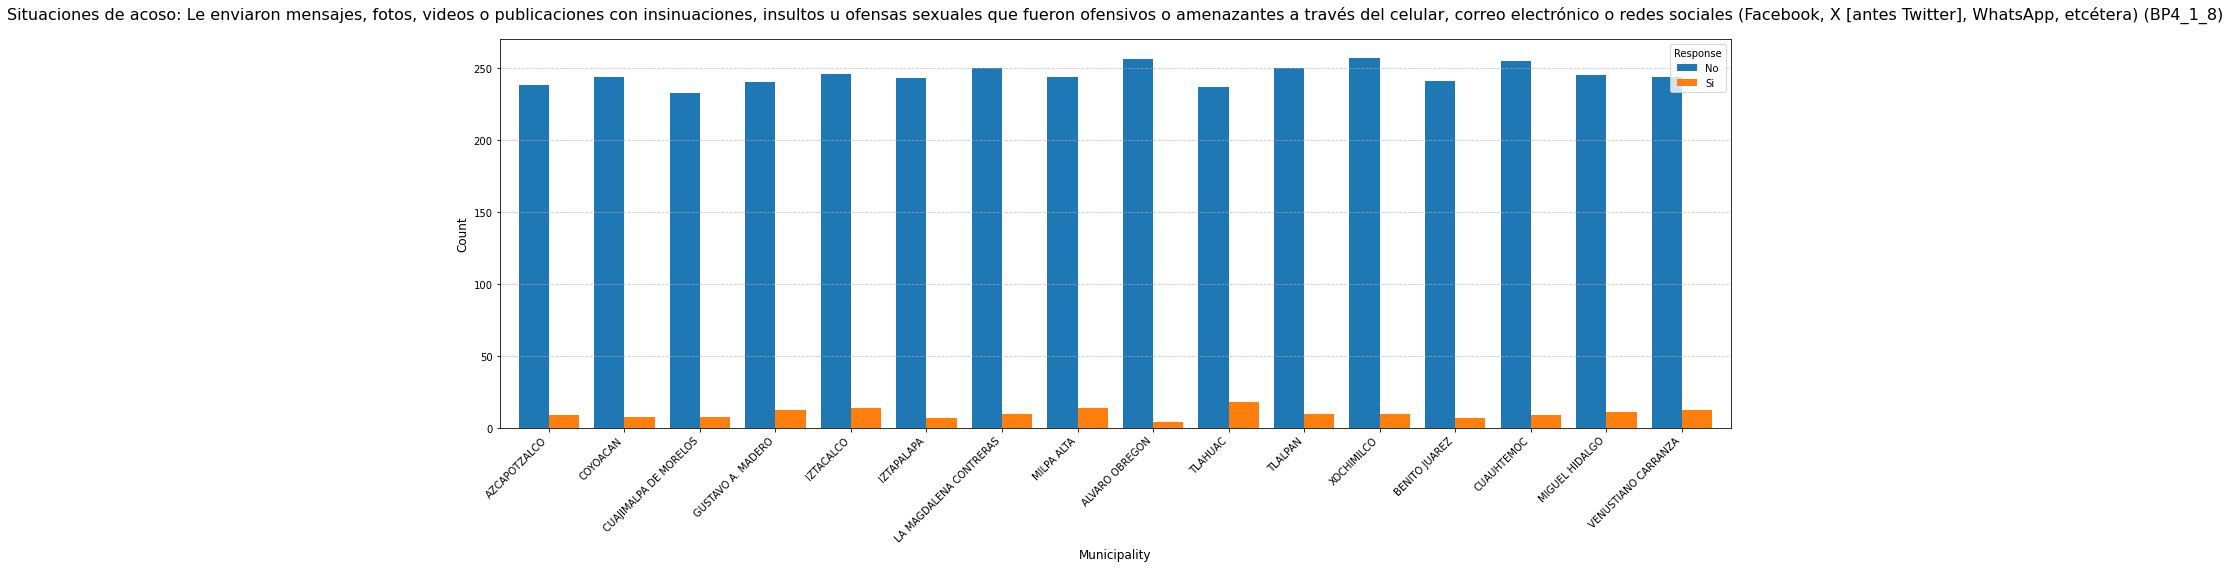

In [74]:
plot_municipality_counts(df_counts_by_municipality, df_dictionary)

Found 29 categories to plot: ['BP1_1', 'BP1_2_01', 'BP1_2_03', 'BP1_4_1', 'BP1_4_2', 'BP1_4_3', 'BP1_4_4', 'BP1_4_5', 'BP1_4_6', 'BP1_4_7', 'BP1_4_8', 'BP1_5_1', 'BP1_5_2', 'BP1_6_4', 'BP2_2_03', 'BP2_2_11', 'BP2_2_14', 'BP3_1_05', 'BP3_1_07', 'BP3_1_08', 'BP3_1_10', 'BP3_1_11', 'BP3_1_13', 'BP3_1_14', 'BP4_1_1', 'BP4_1_2', 'BP4_1_3', 'BP4_1_7', 'BP4_1_8']

Generating plot for: BP1_1


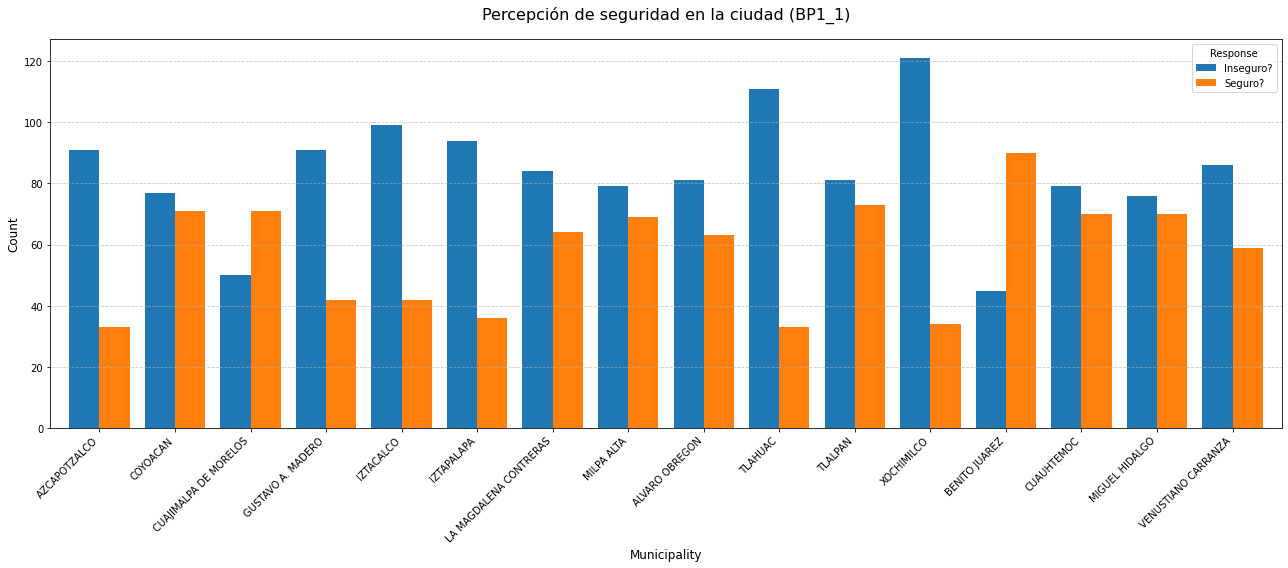


Generating plot for: BP1_2_01


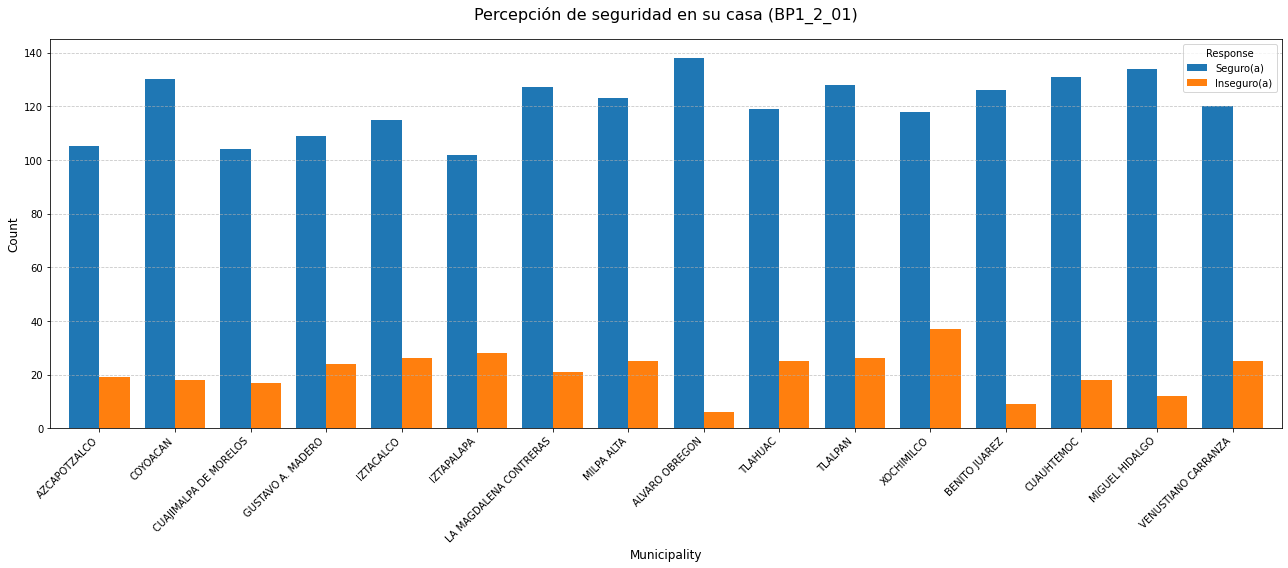


Generating plot for: BP1_2_03


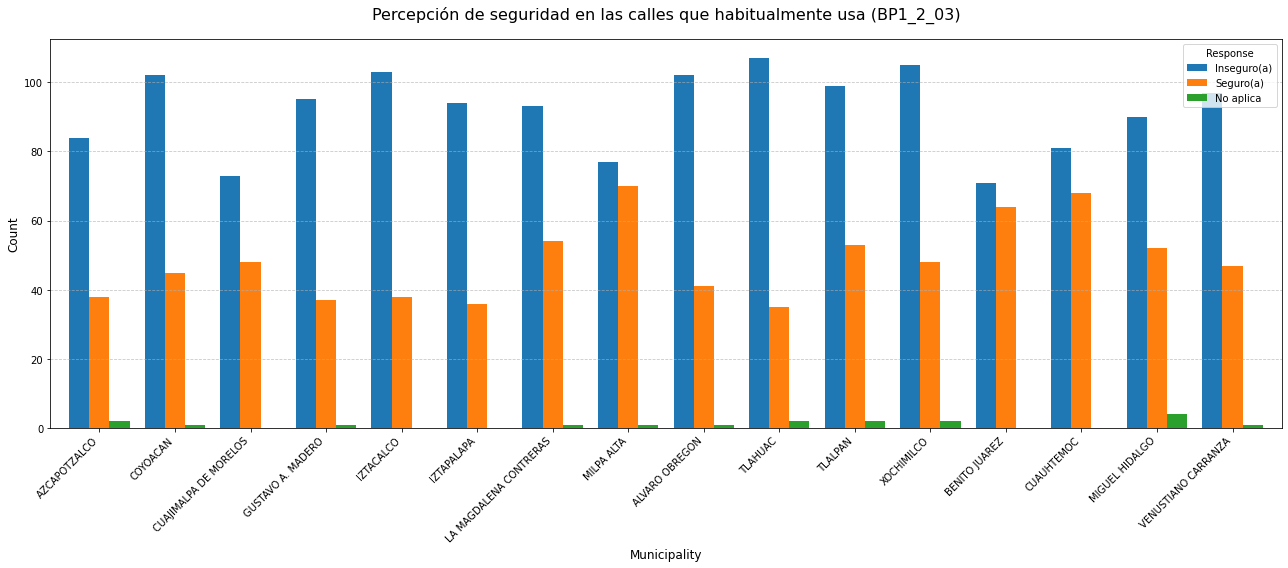


Generating plot for: BP1_4_1


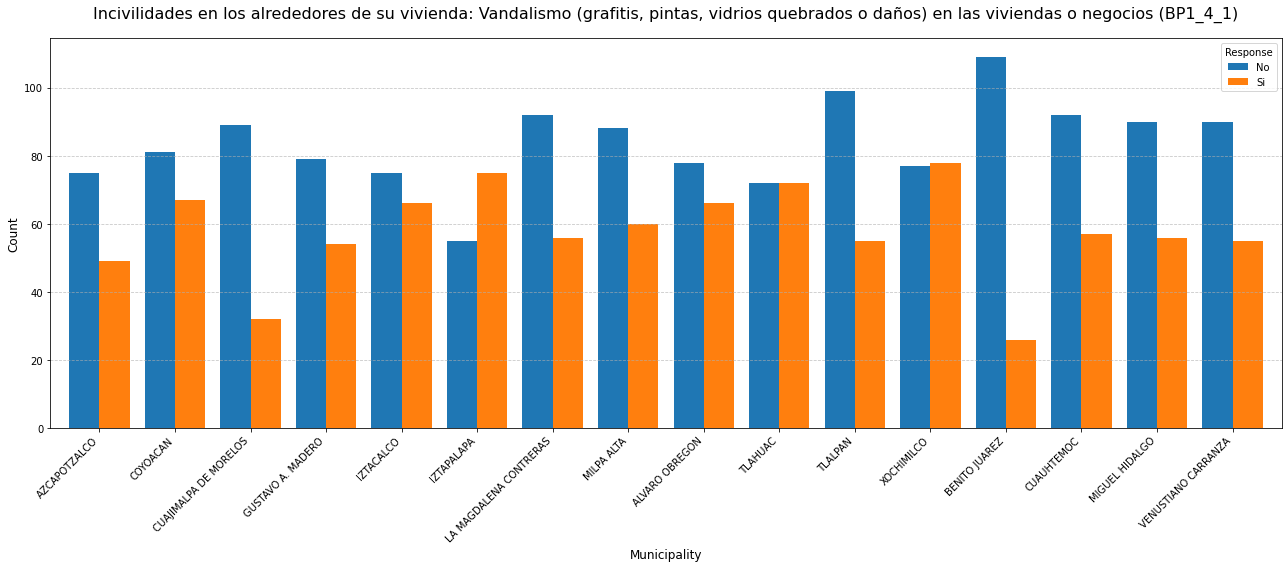


Generating plot for: BP1_4_2


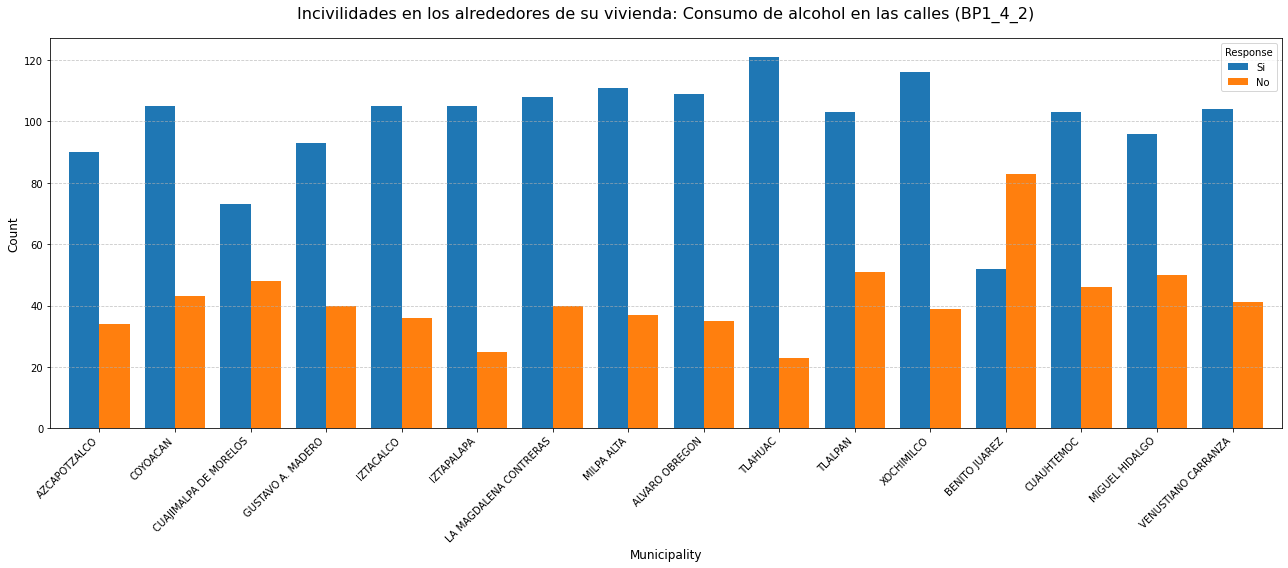


Generating plot for: BP1_4_3


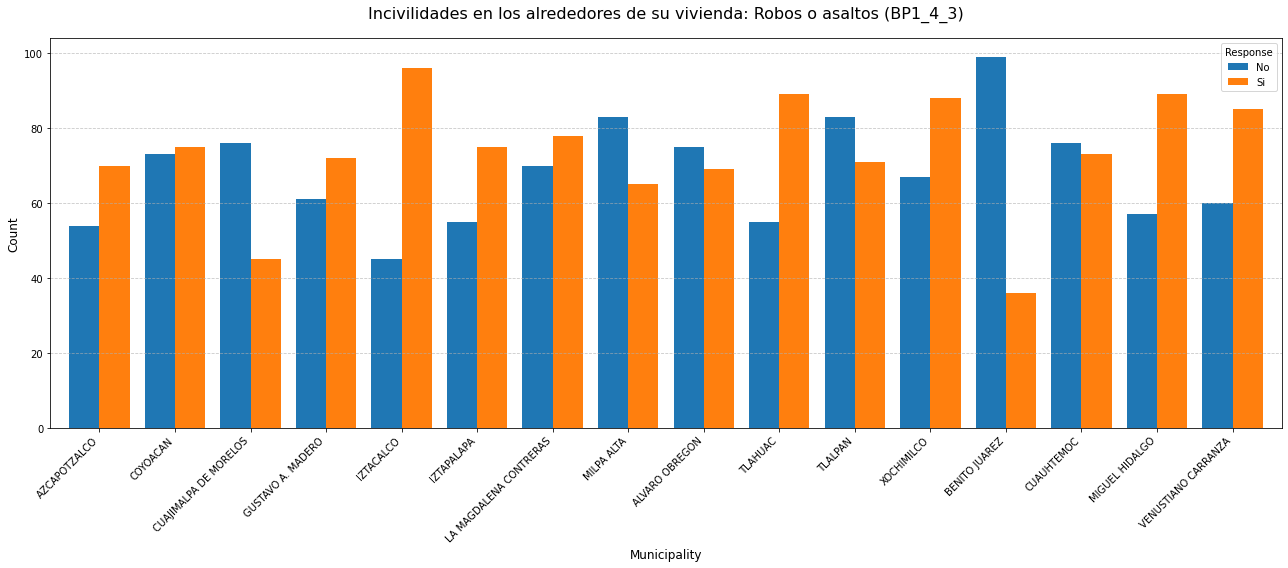


Generating plot for: BP1_4_4


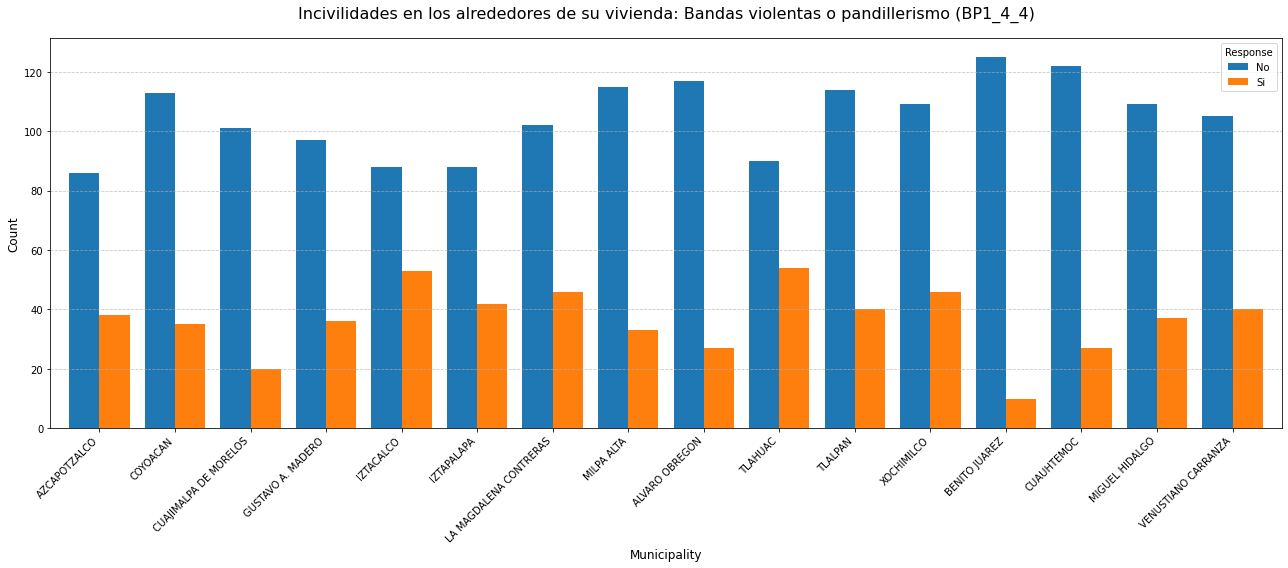


Generating plot for: BP1_4_5


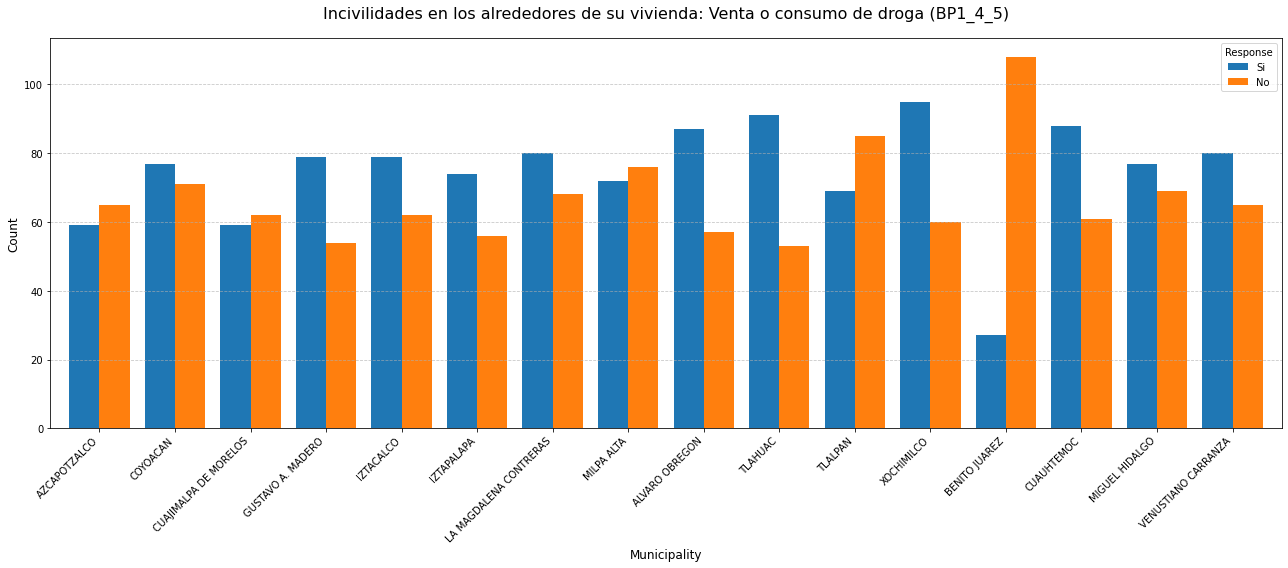


Generating plot for: BP1_4_6


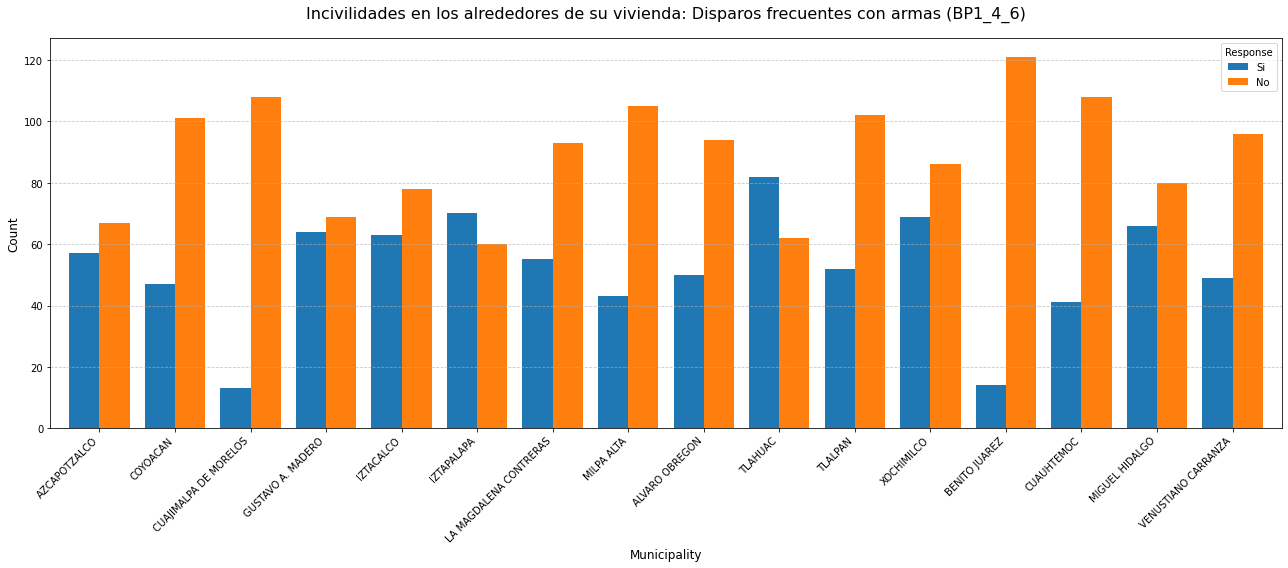


Generating plot for: BP1_4_7


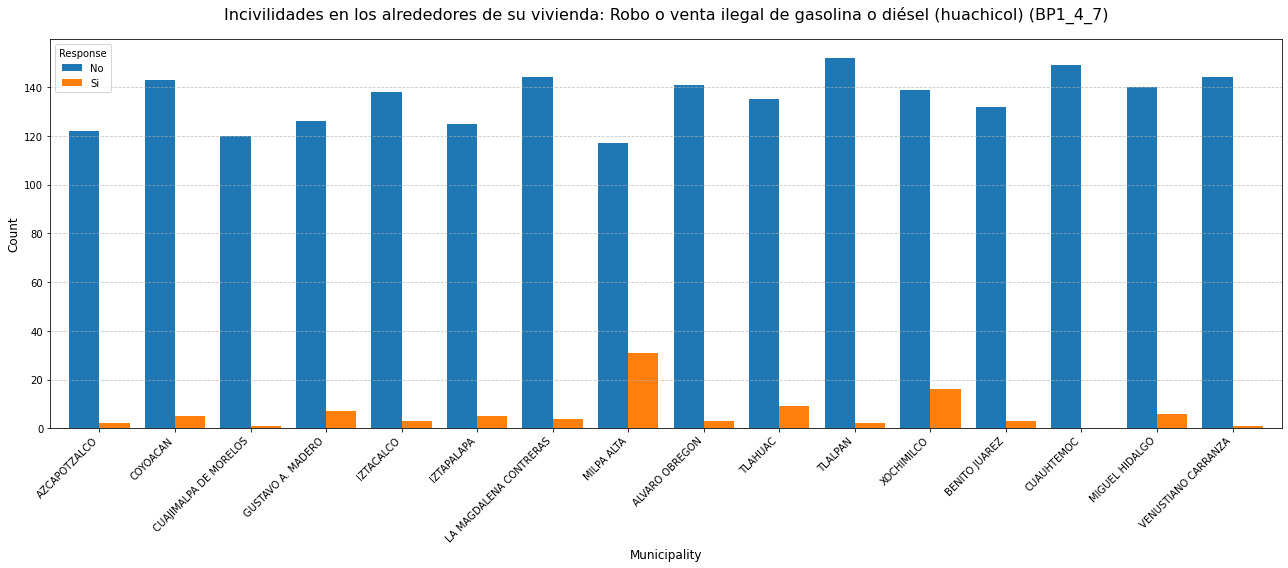


Generating plot for: BP1_4_8


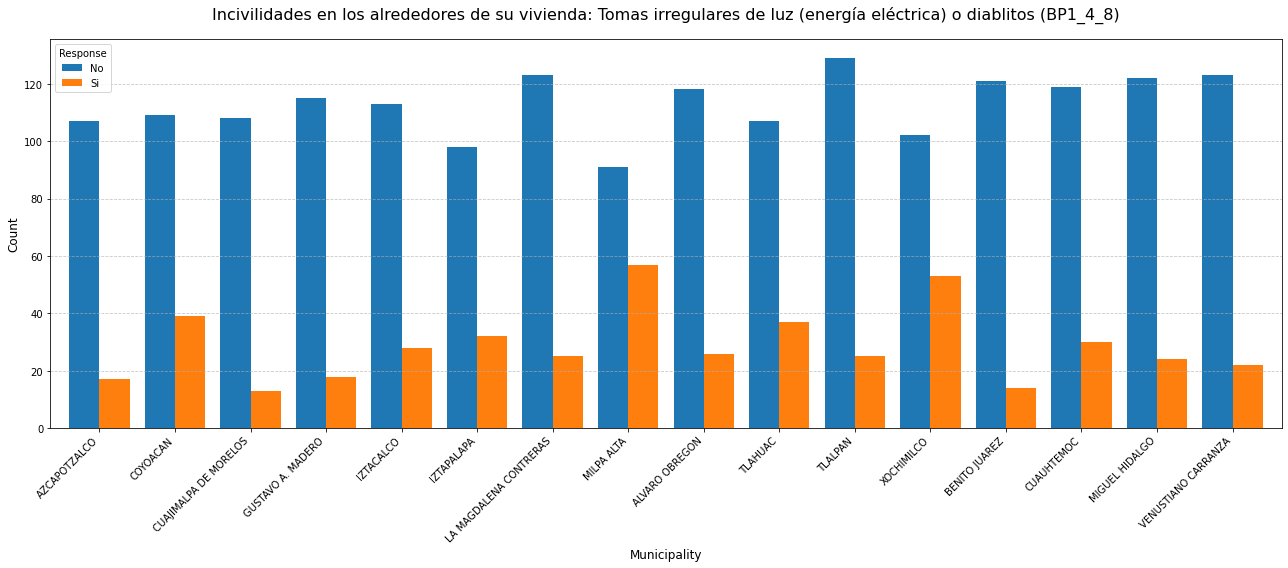


Generating plot for: BP1_5_1


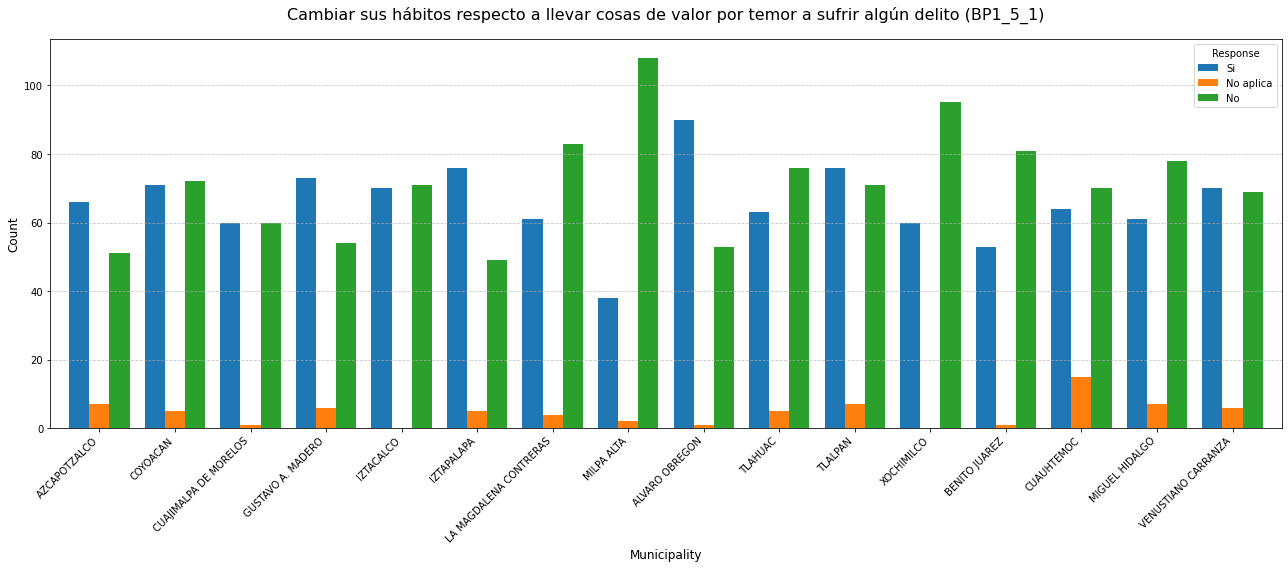


Generating plot for: BP1_5_2


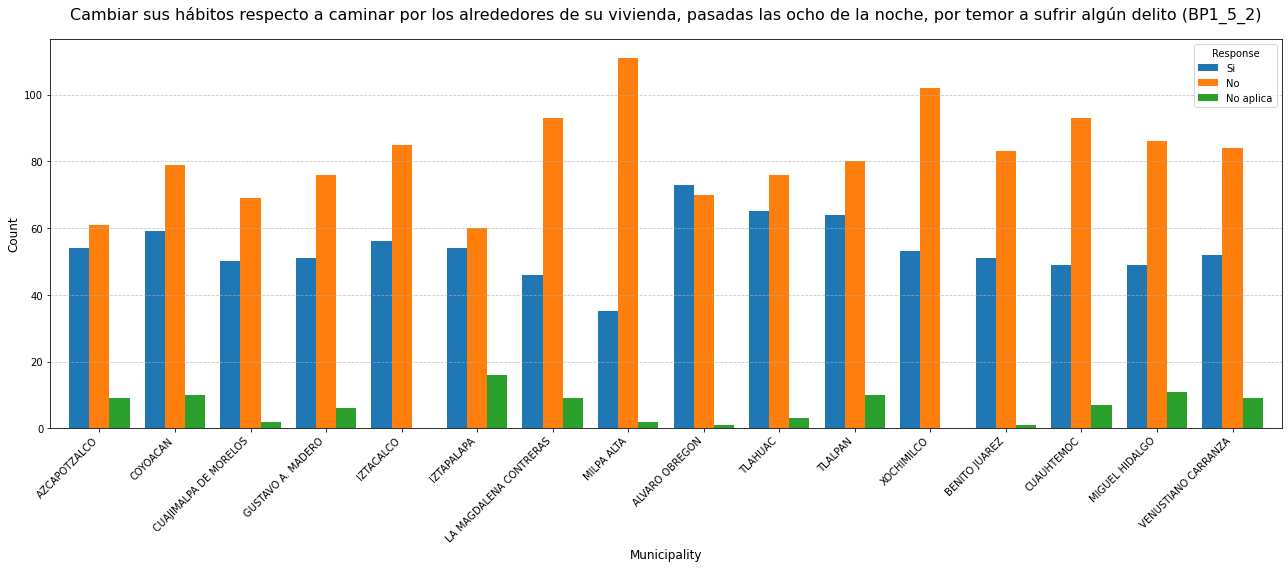


Generating plot for: BP1_6_4


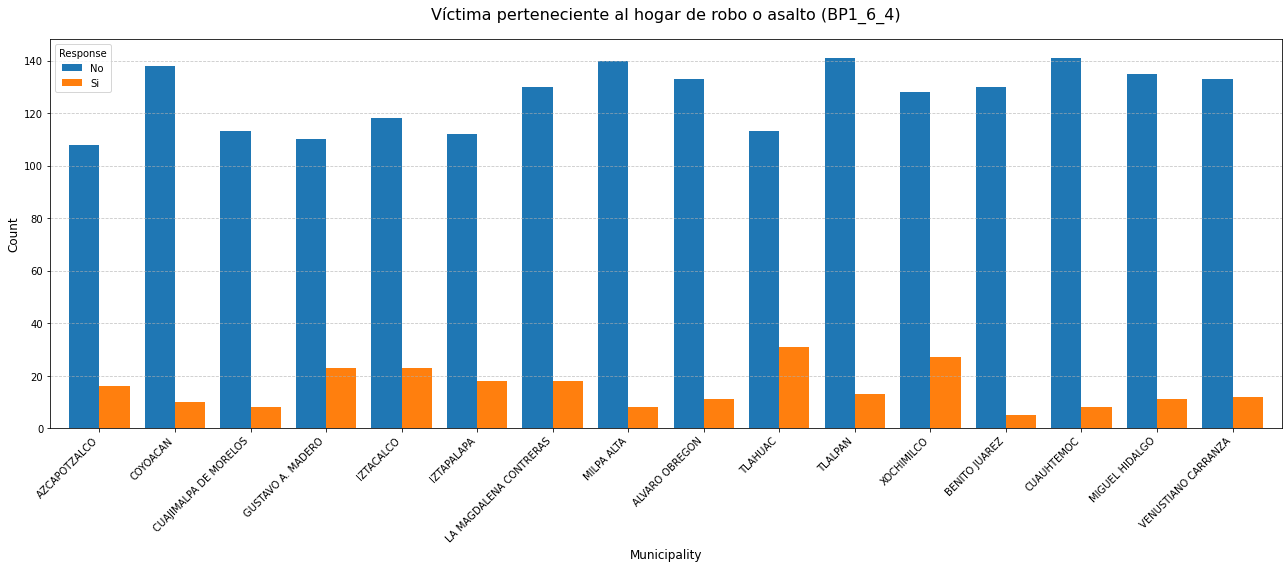


Generating plot for: BP2_2_03


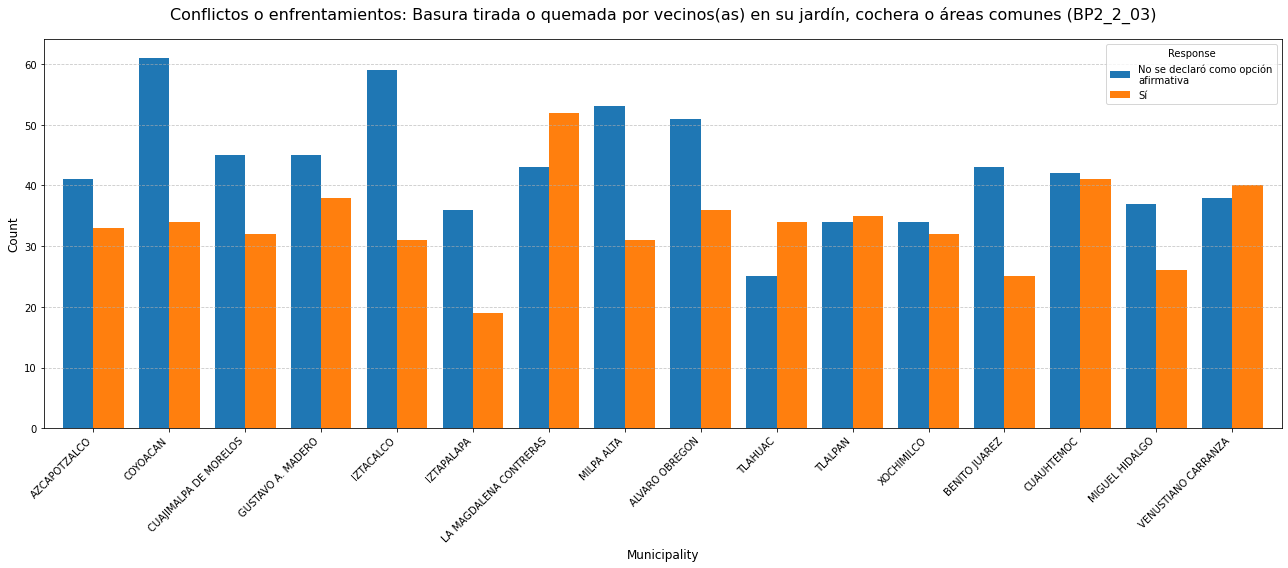


Generating plot for: BP2_2_11


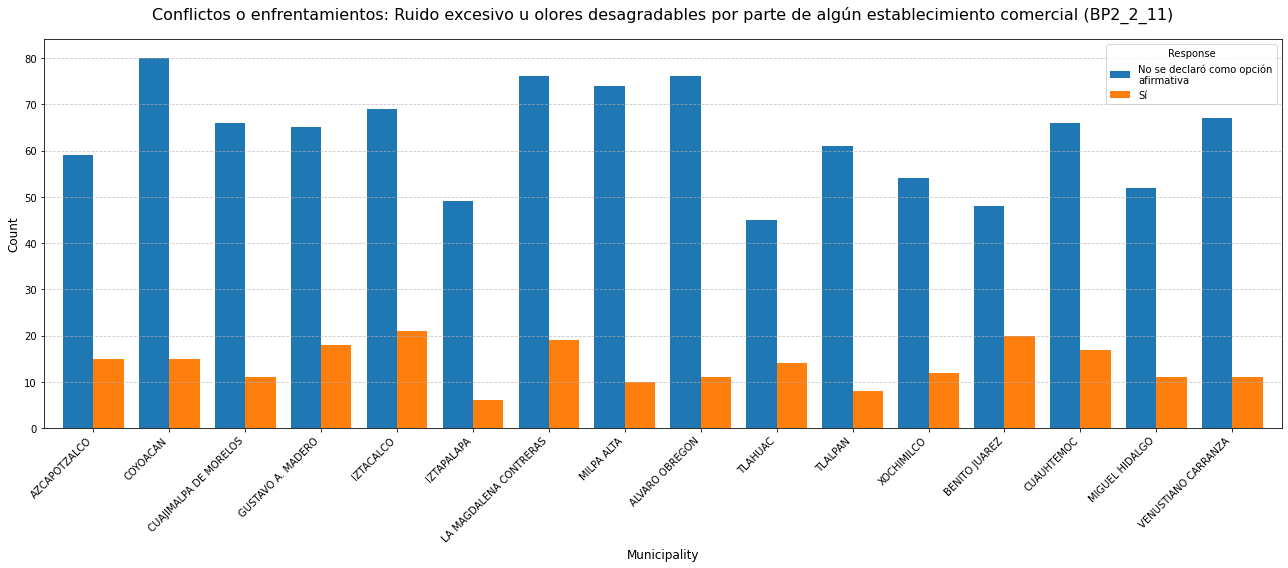


Generating plot for: BP2_2_14


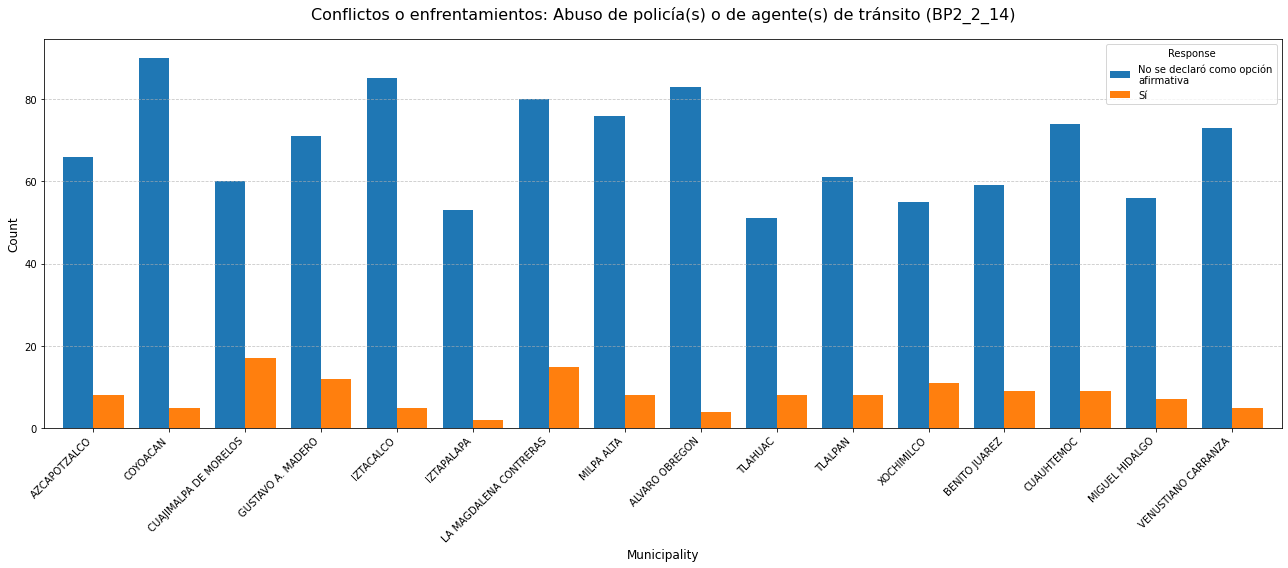


Generating plot for: BP3_1_05


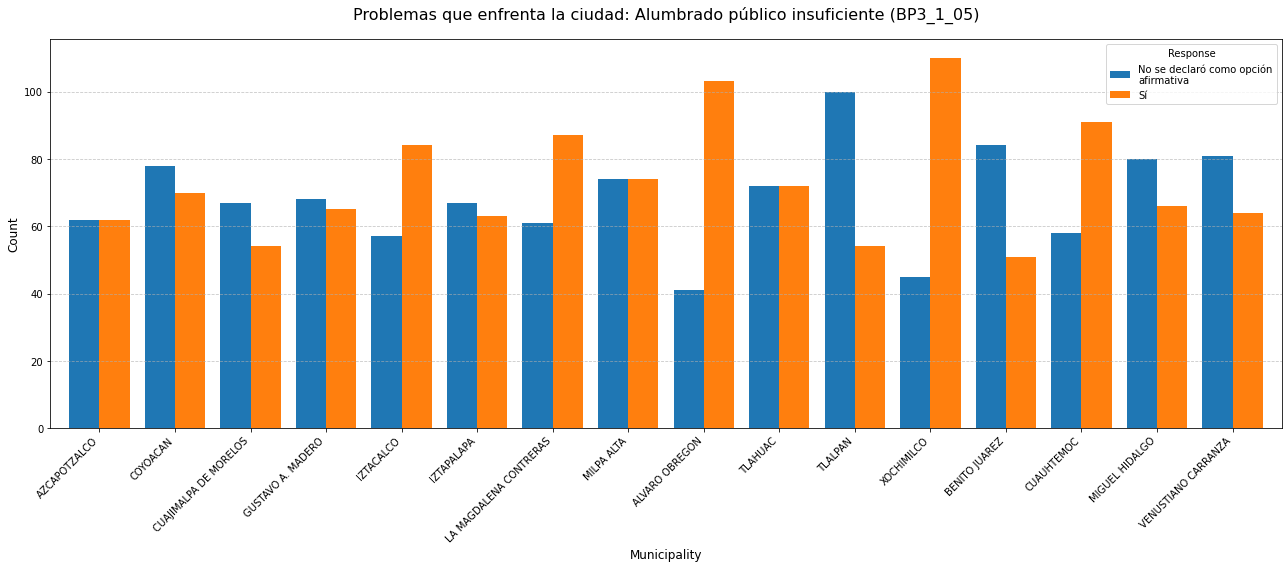


Generating plot for: BP3_1_07


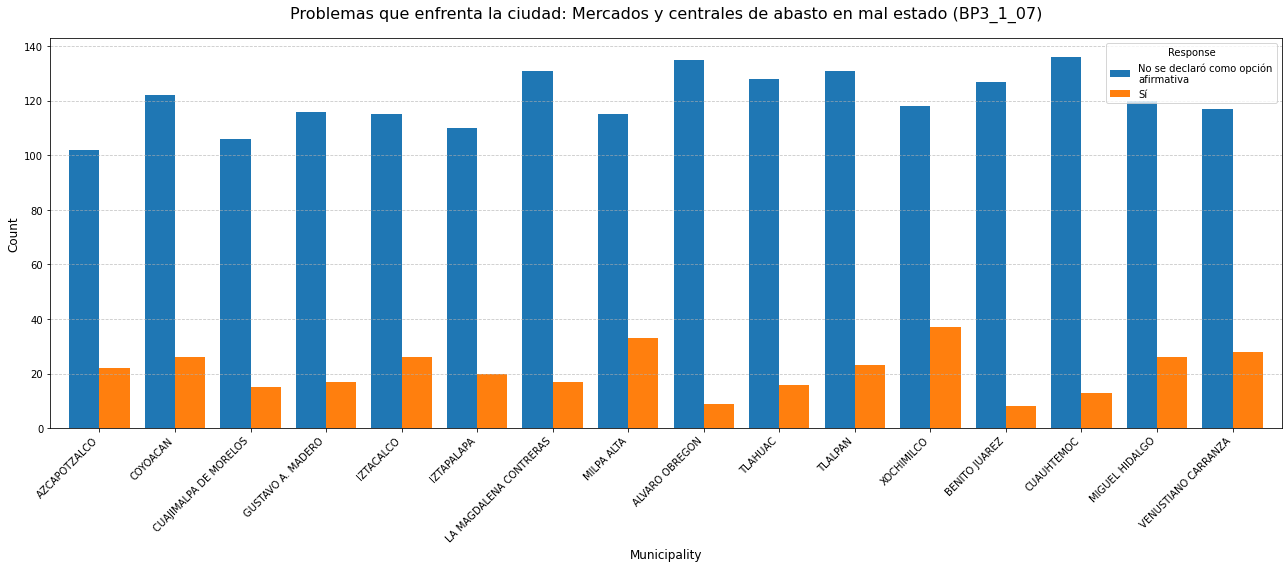


Generating plot for: BP3_1_08


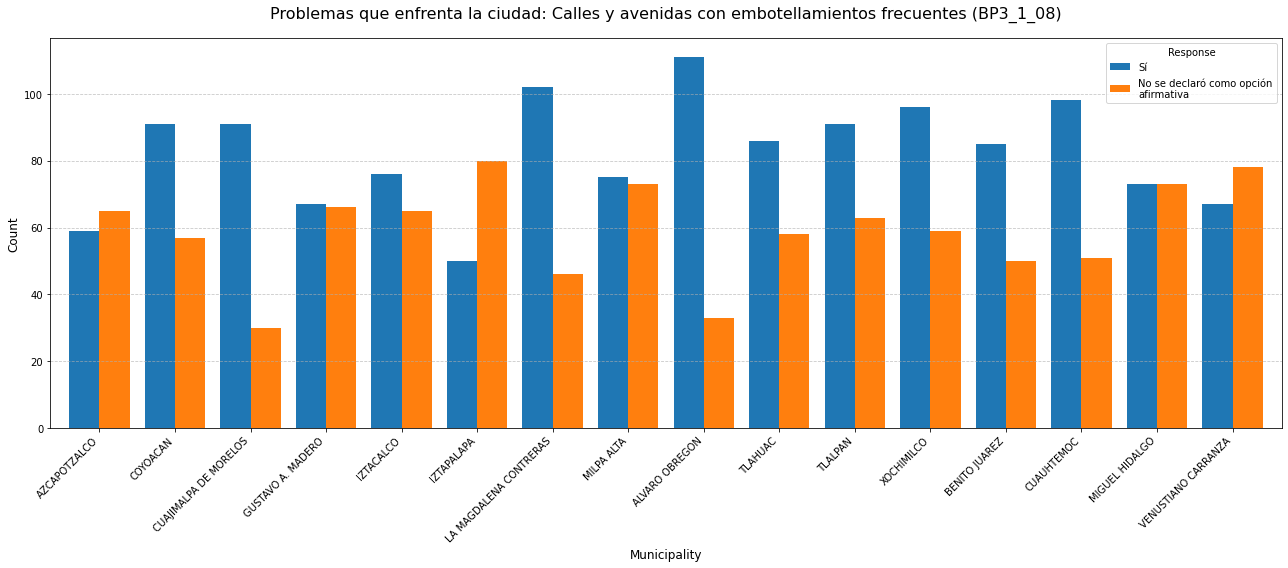


Generating plot for: BP3_1_10


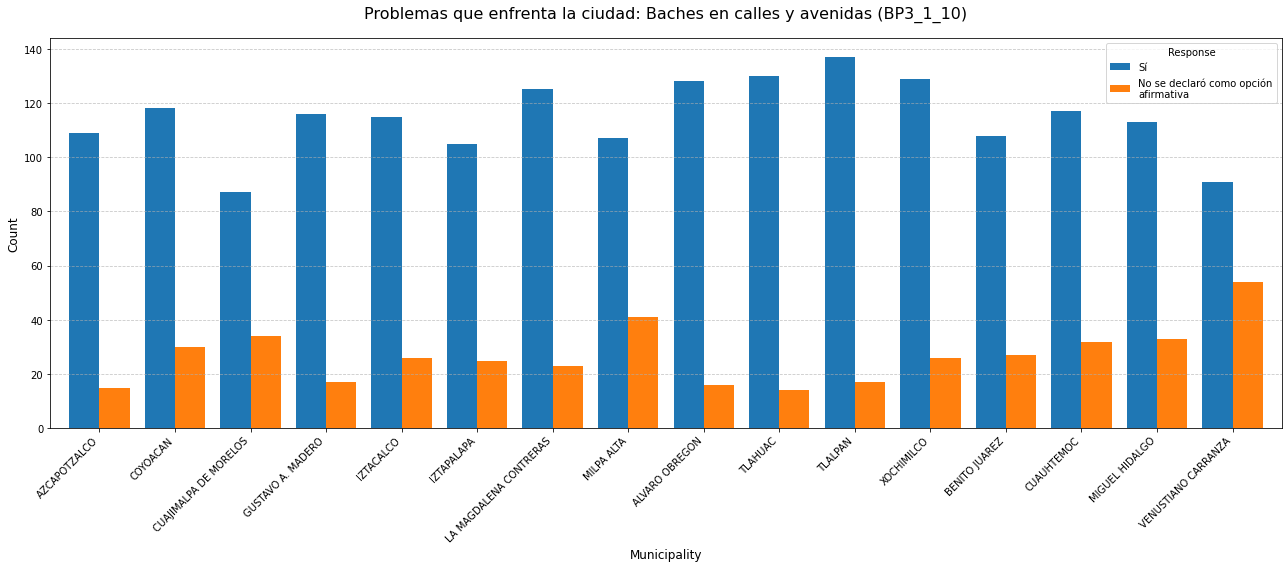


Generating plot for: BP3_1_11


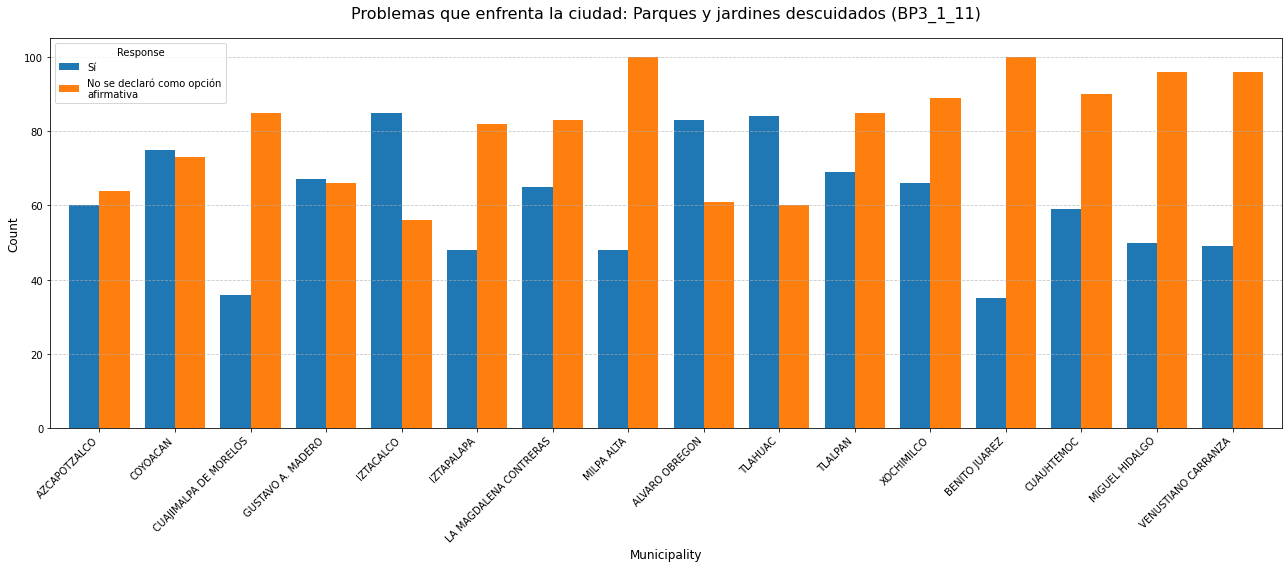


Generating plot for: BP3_1_13


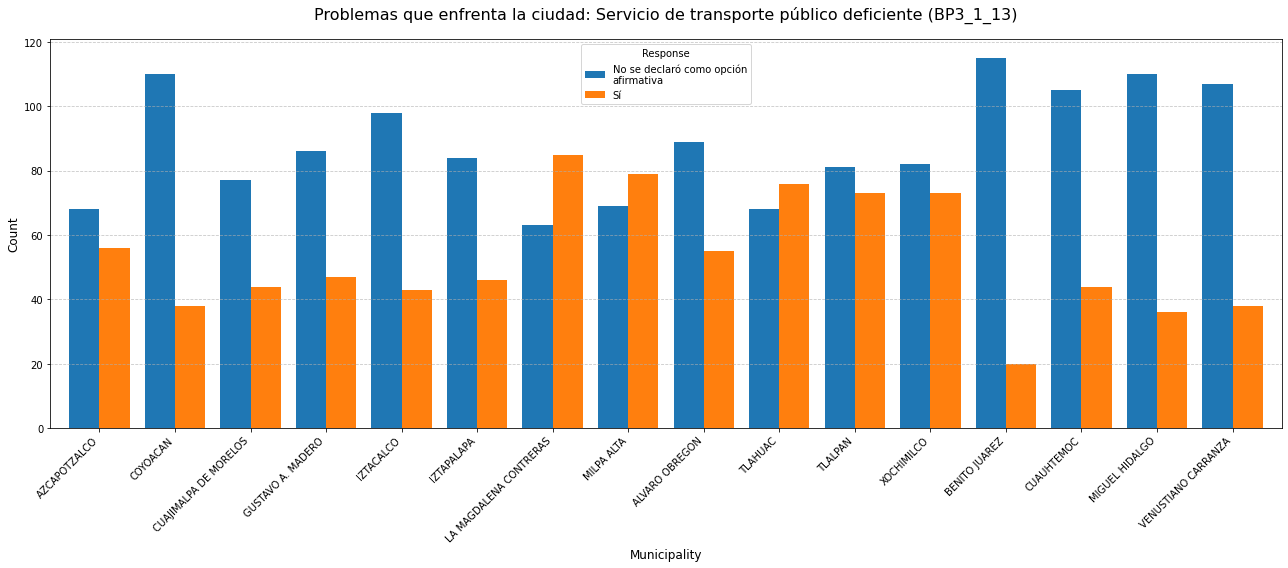


Generating plot for: BP3_1_14


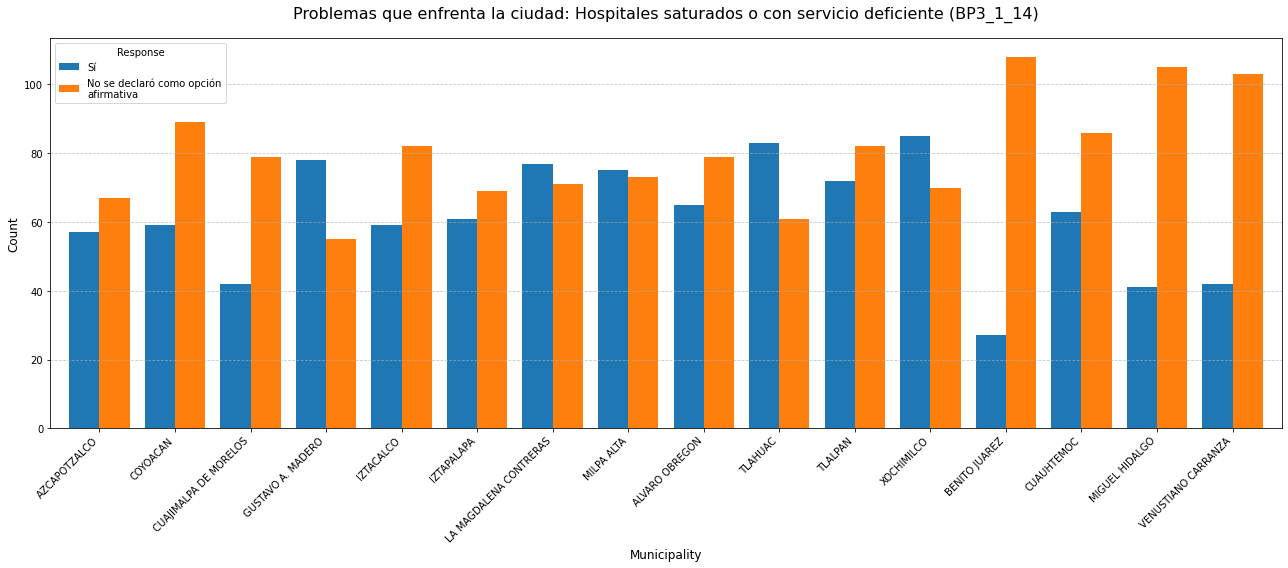


Generating plot for: BP4_1_1


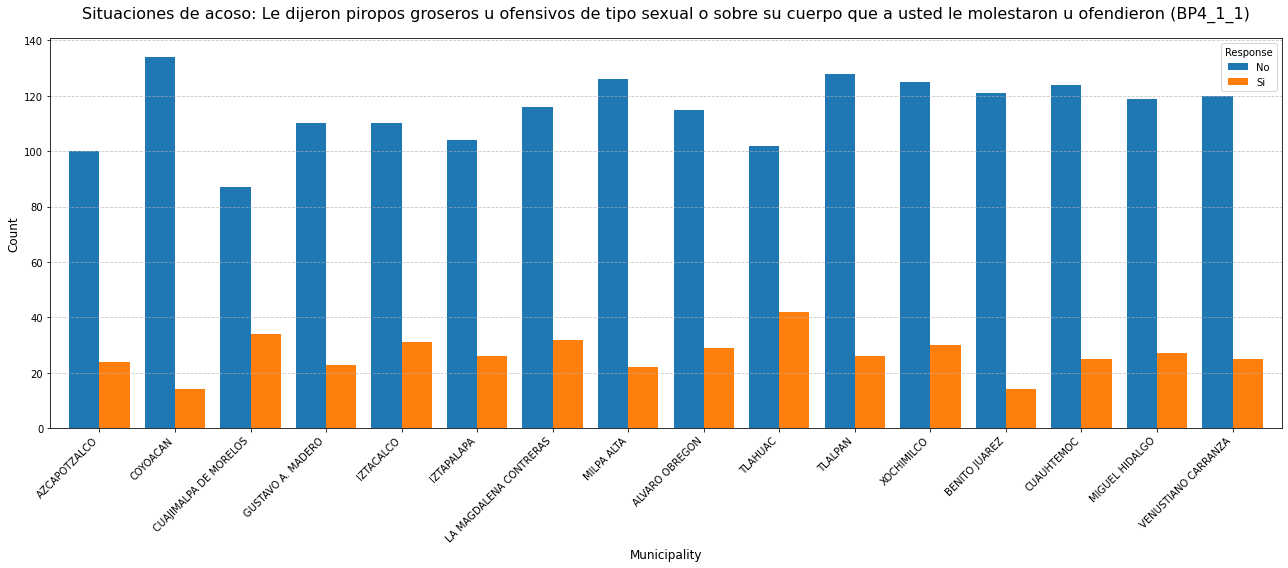


Generating plot for: BP4_1_2


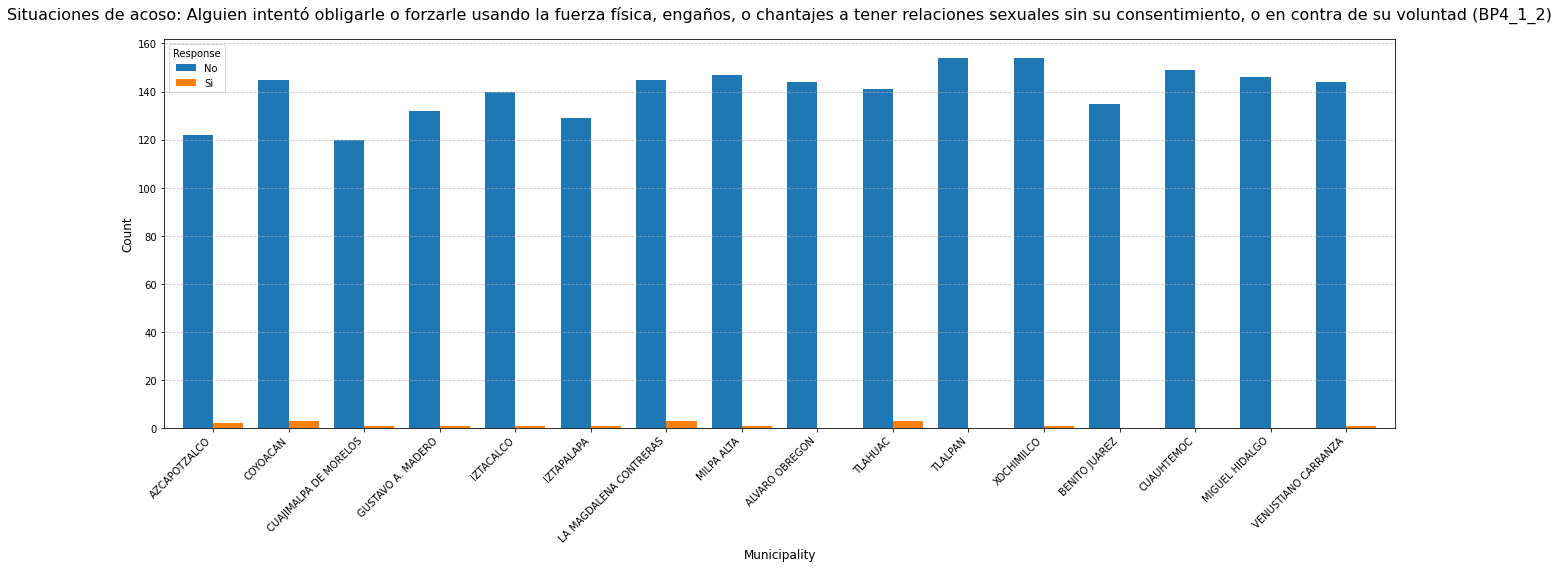


Generating plot for: BP4_1_3


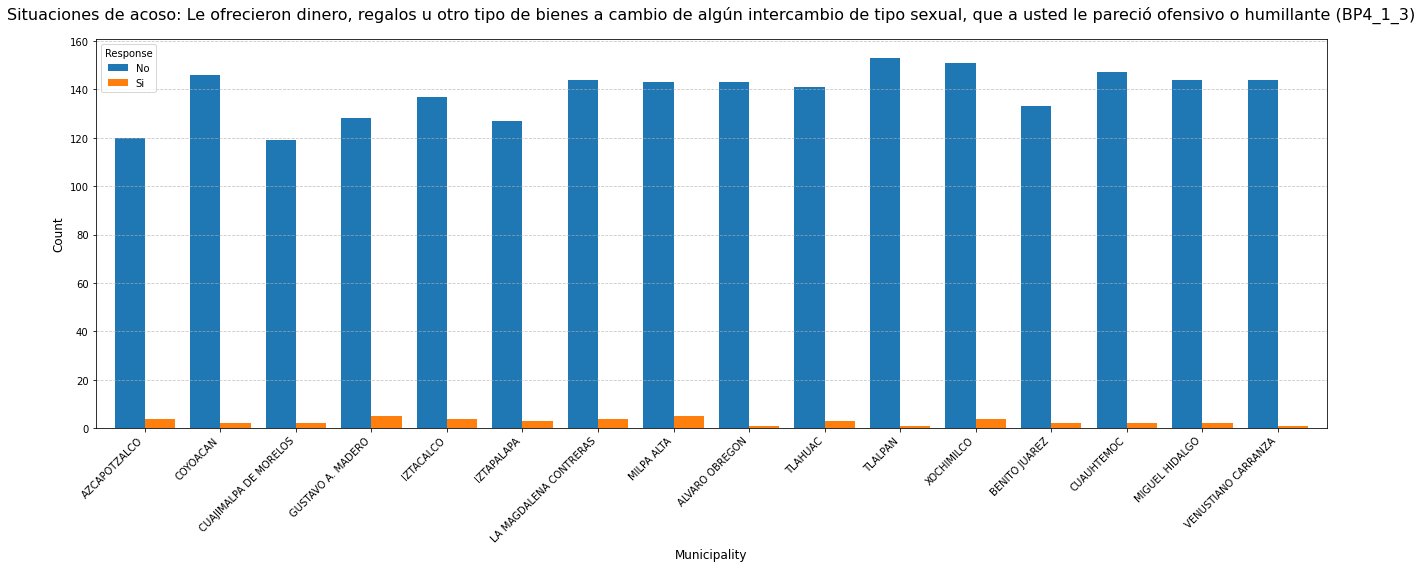


Generating plot for: BP4_1_7


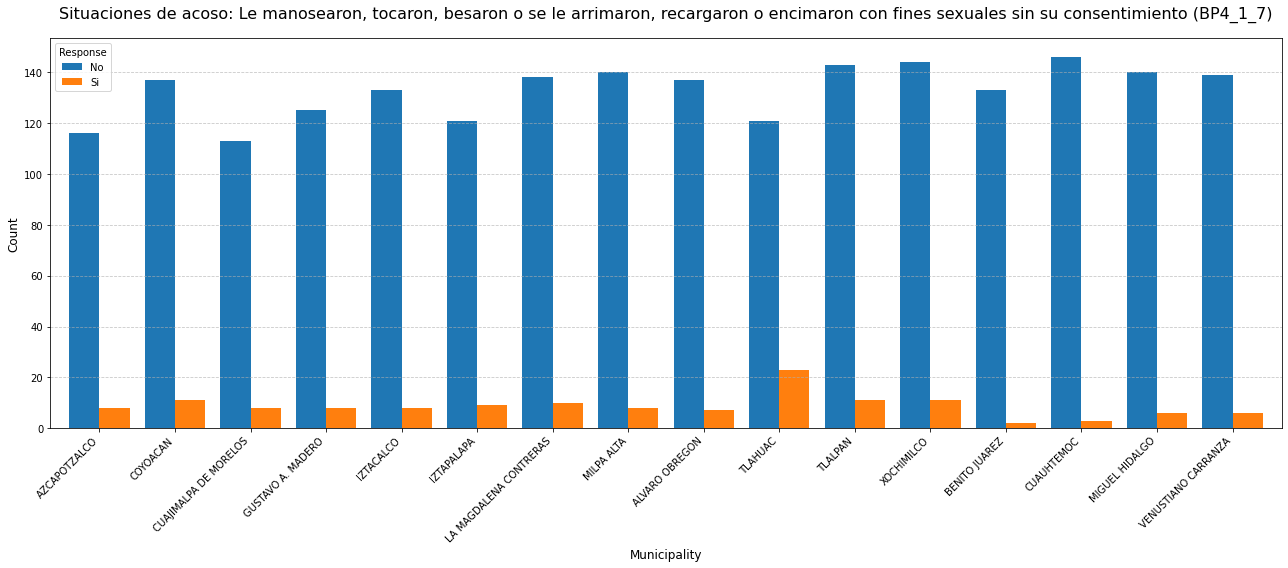


Generating plot for: BP4_1_8


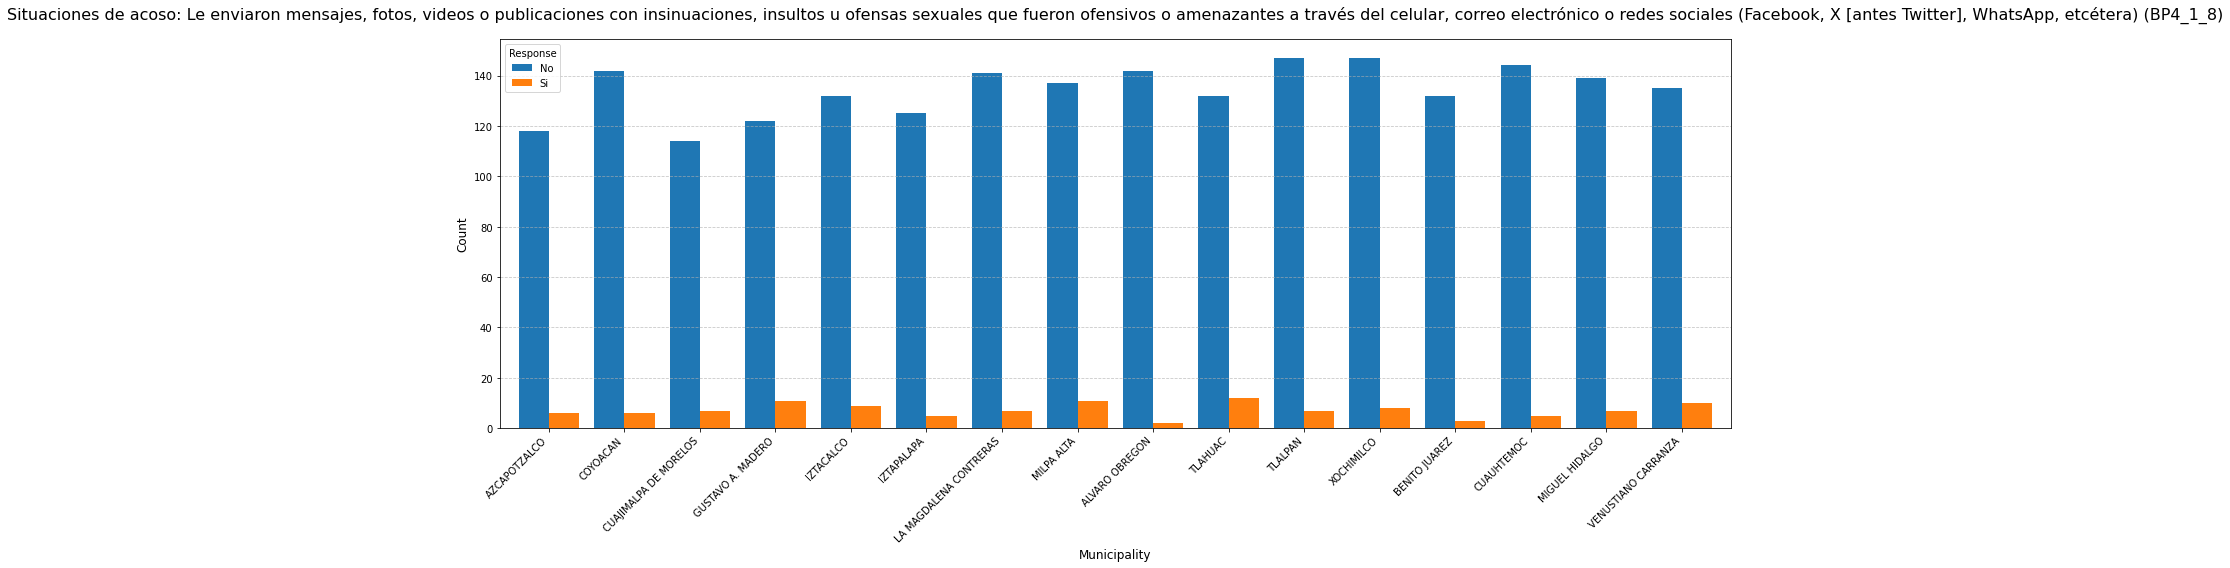

In [75]:
plot_municipality_counts(df_counts_by_municipality_women, df_dictionary)

Found 29 categories to plot: ['BP1_1', 'BP1_2_01', 'BP1_2_03', 'BP1_4_1', 'BP1_4_2', 'BP1_4_3', 'BP1_4_4', 'BP1_4_5', 'BP1_4_6', 'BP1_4_7', 'BP1_4_8', 'BP1_5_1', 'BP1_5_2', 'BP1_6_4', 'BP2_2_03', 'BP2_2_11', 'BP2_2_14', 'BP3_1_05', 'BP3_1_07', 'BP3_1_08', 'BP3_1_10', 'BP3_1_11', 'BP3_1_13', 'BP3_1_14', 'BP4_1_1', 'BP4_1_2', 'BP4_1_3', 'BP4_1_7', 'BP4_1_8']

Generating plot for: BP1_1


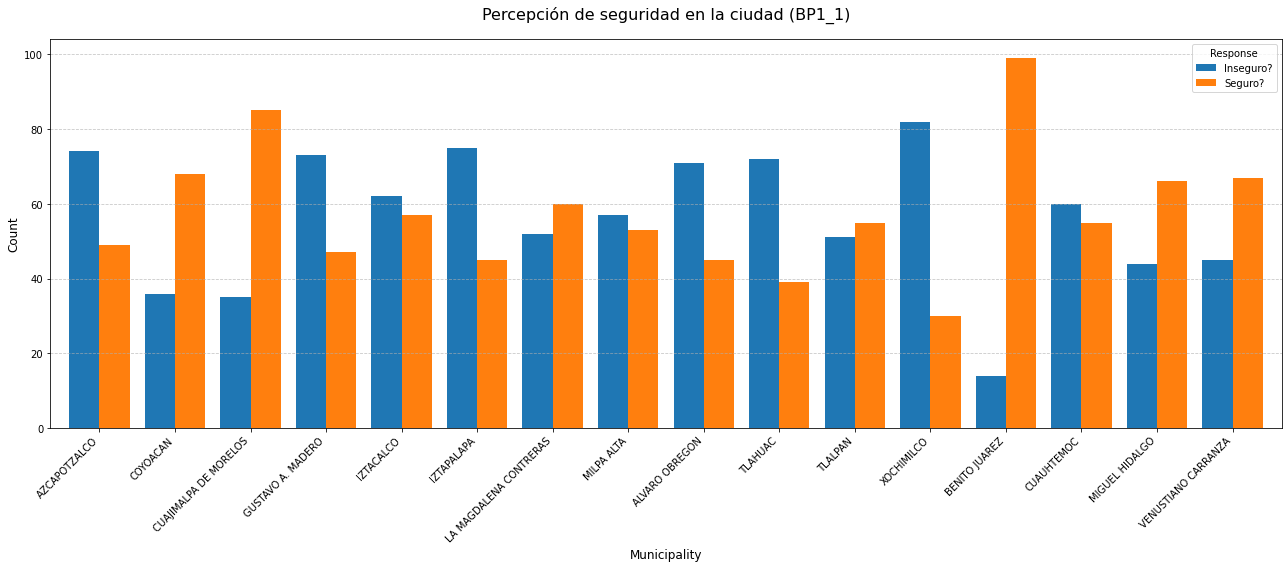


Generating plot for: BP1_2_01


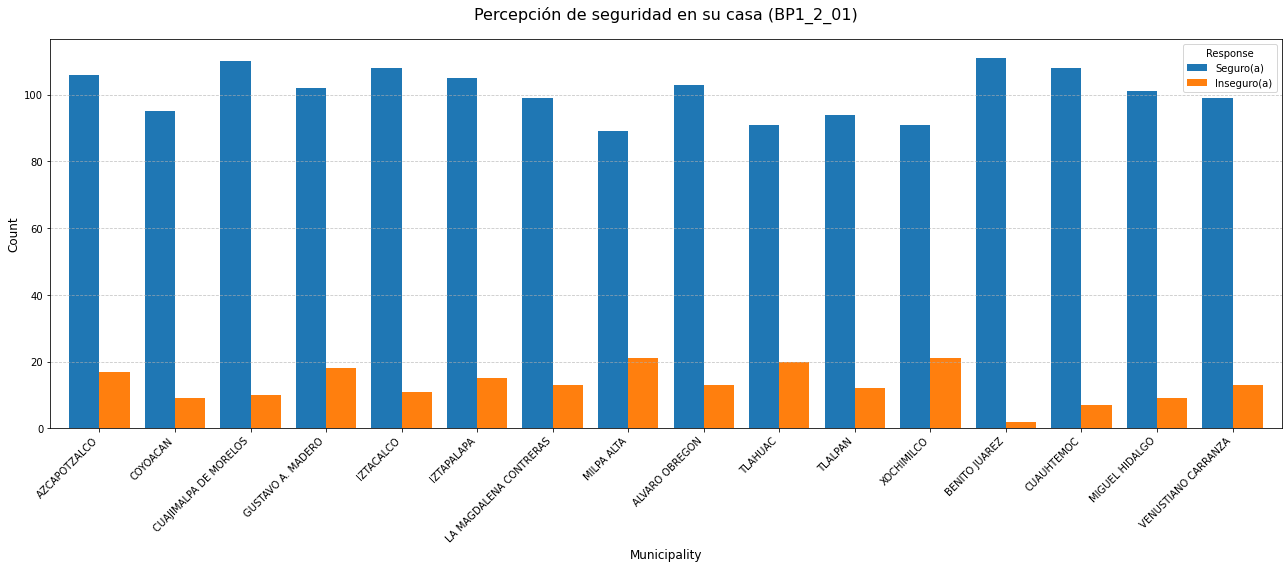


Generating plot for: BP1_2_03


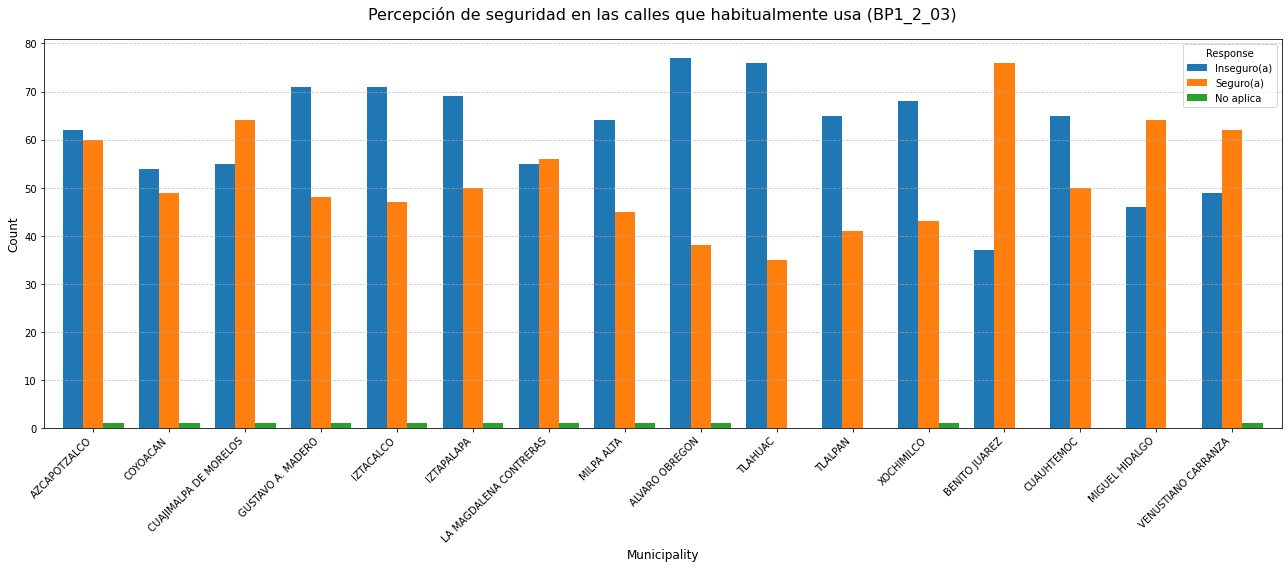


Generating plot for: BP1_4_1


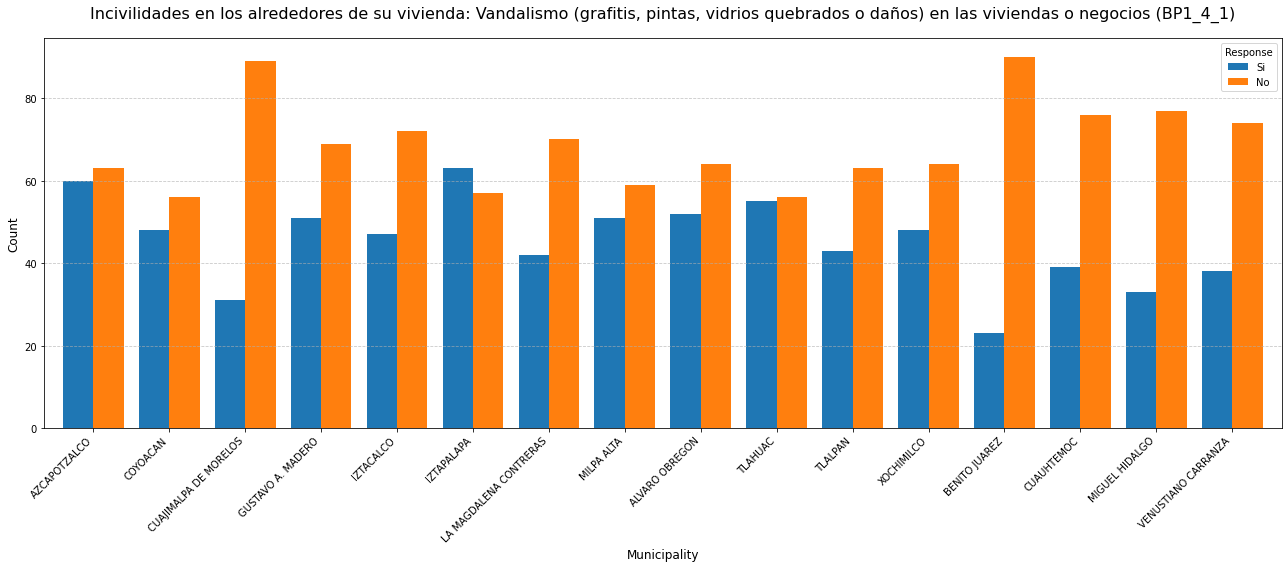


Generating plot for: BP1_4_2


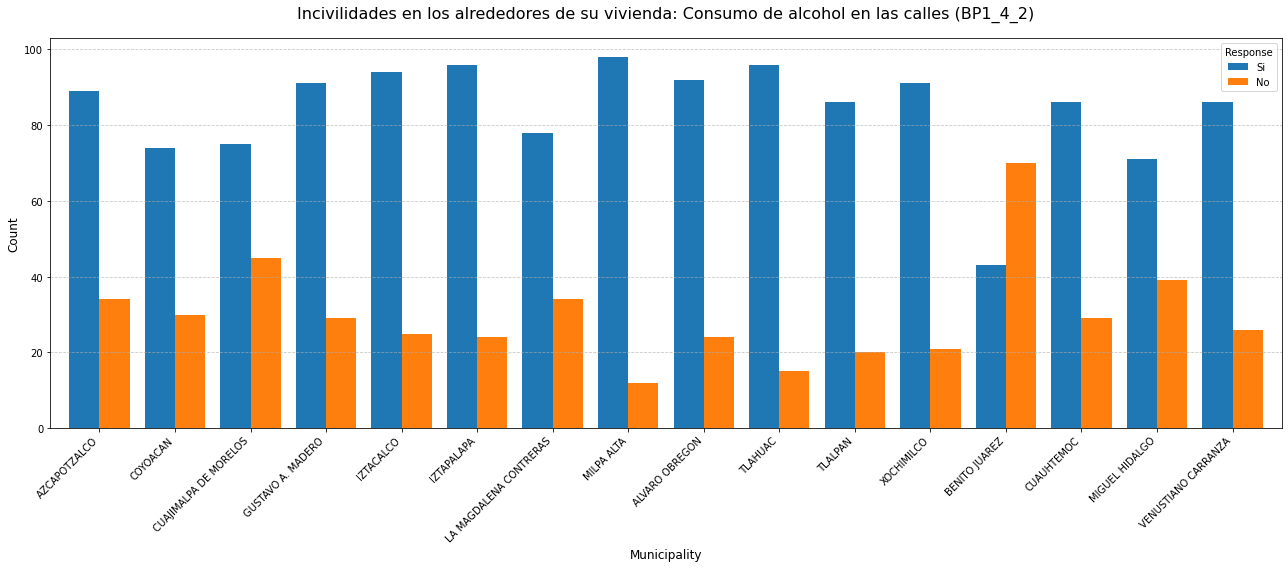


Generating plot for: BP1_4_3


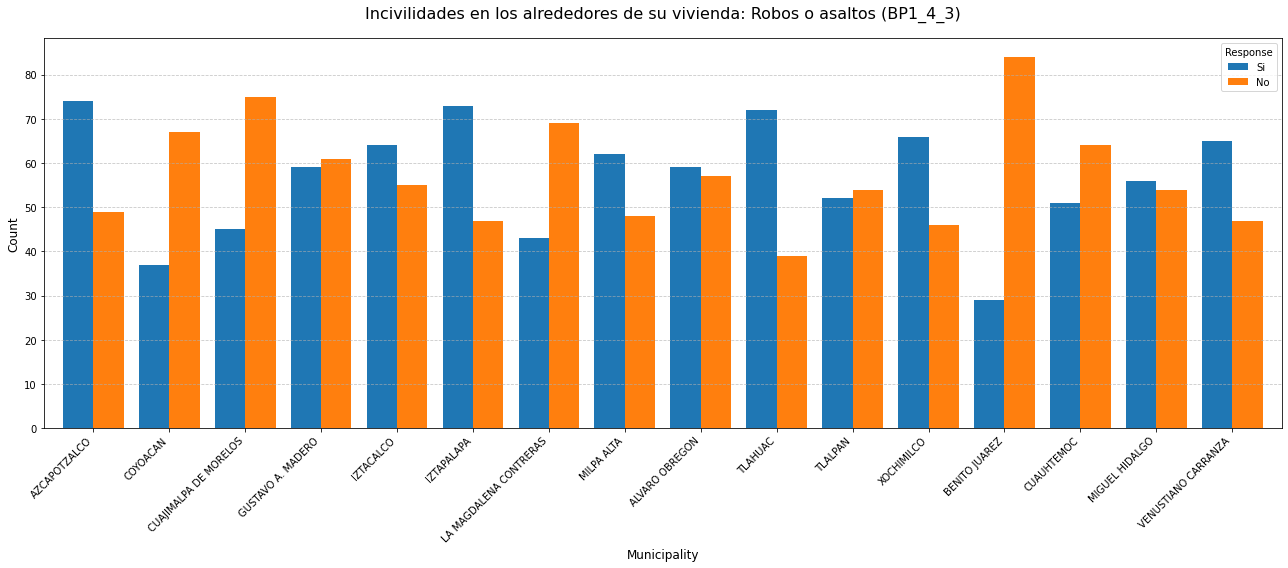


Generating plot for: BP1_4_4


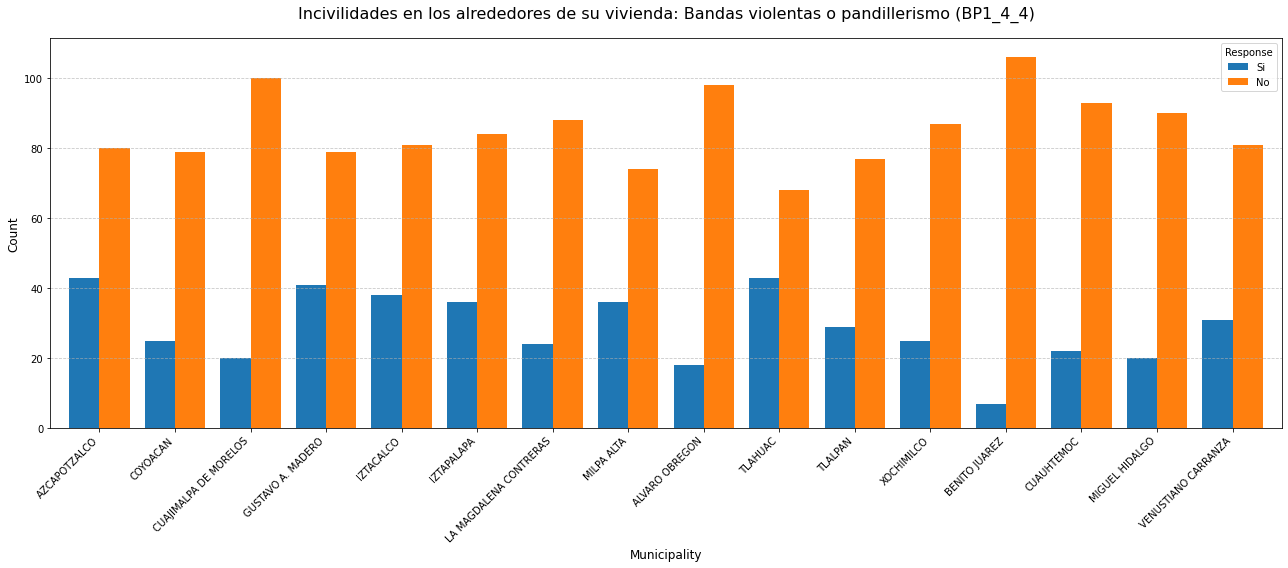


Generating plot for: BP1_4_5


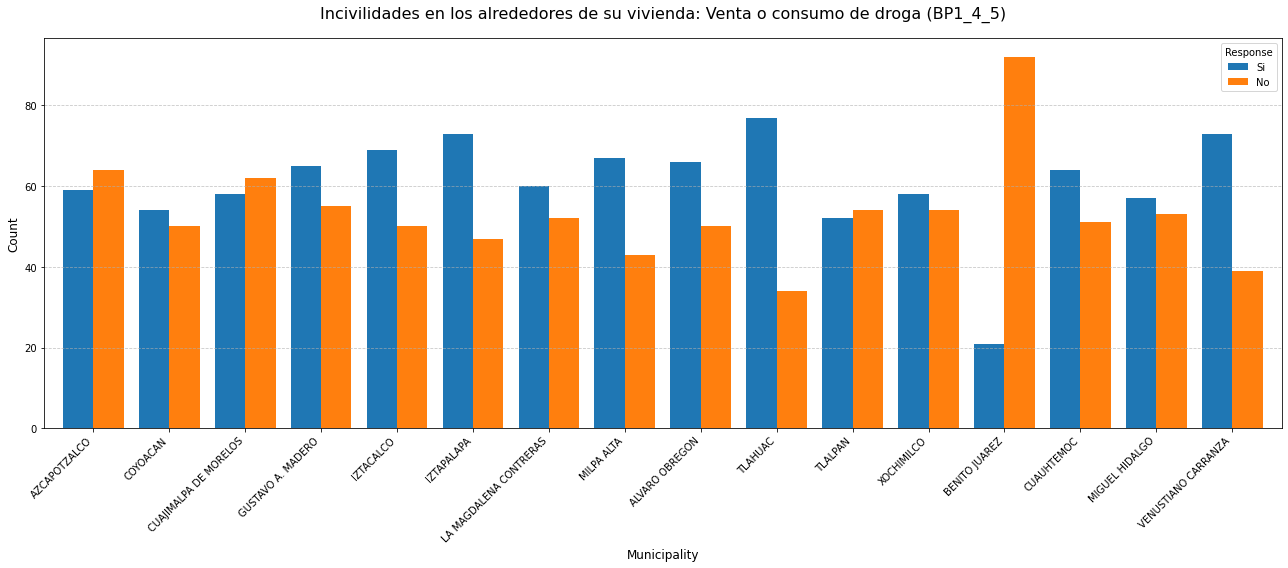


Generating plot for: BP1_4_6


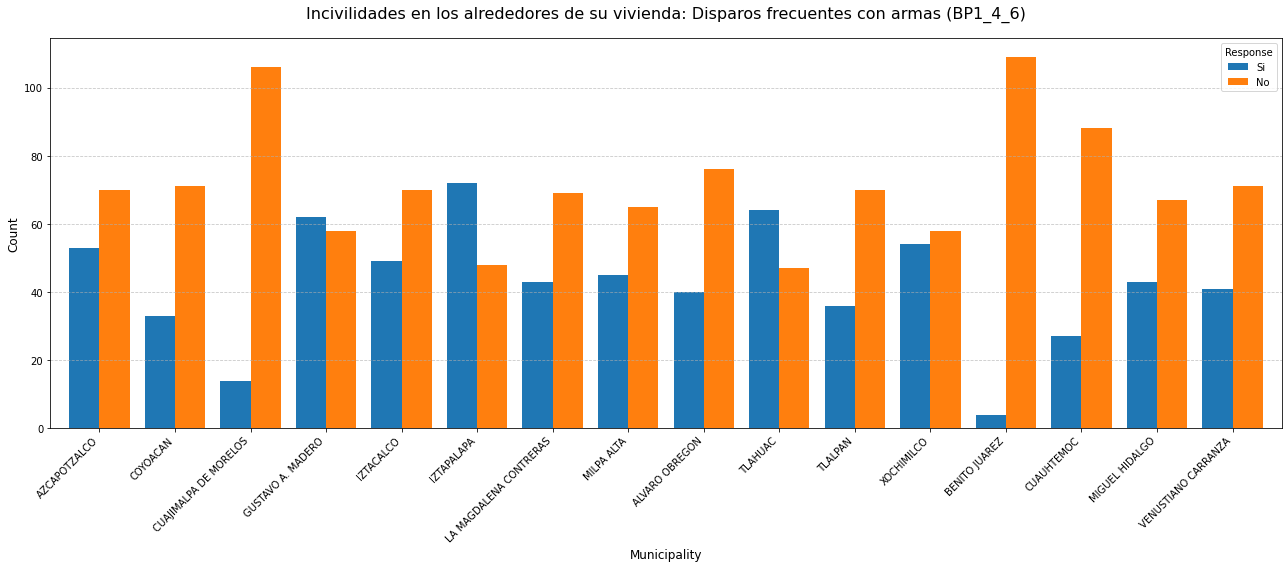


Generating plot for: BP1_4_7


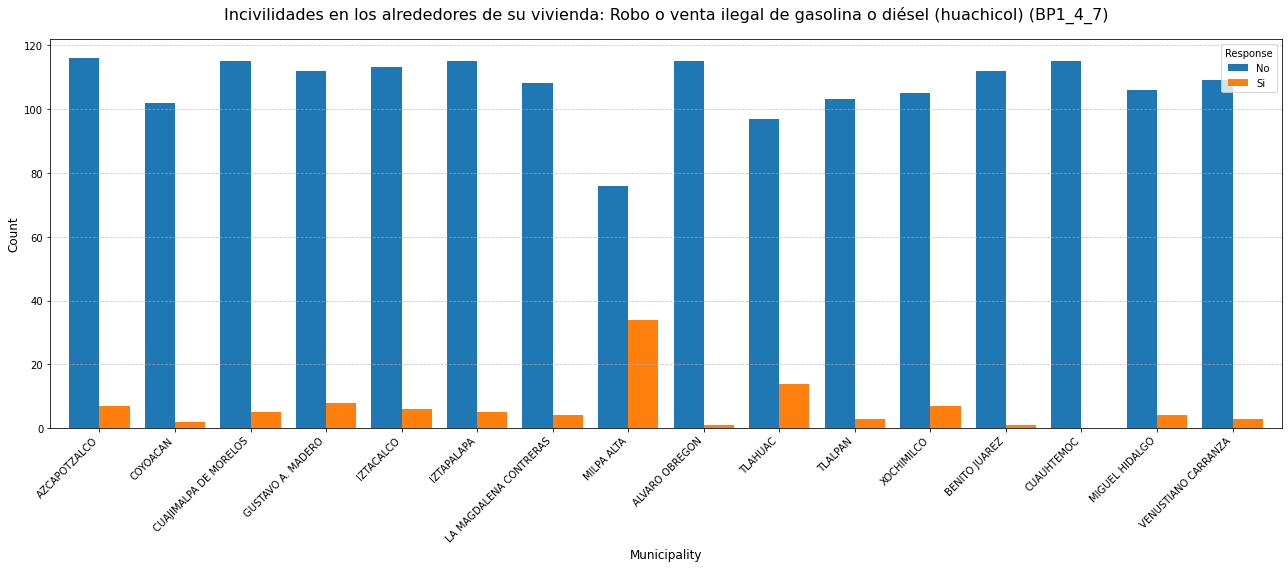


Generating plot for: BP1_4_8


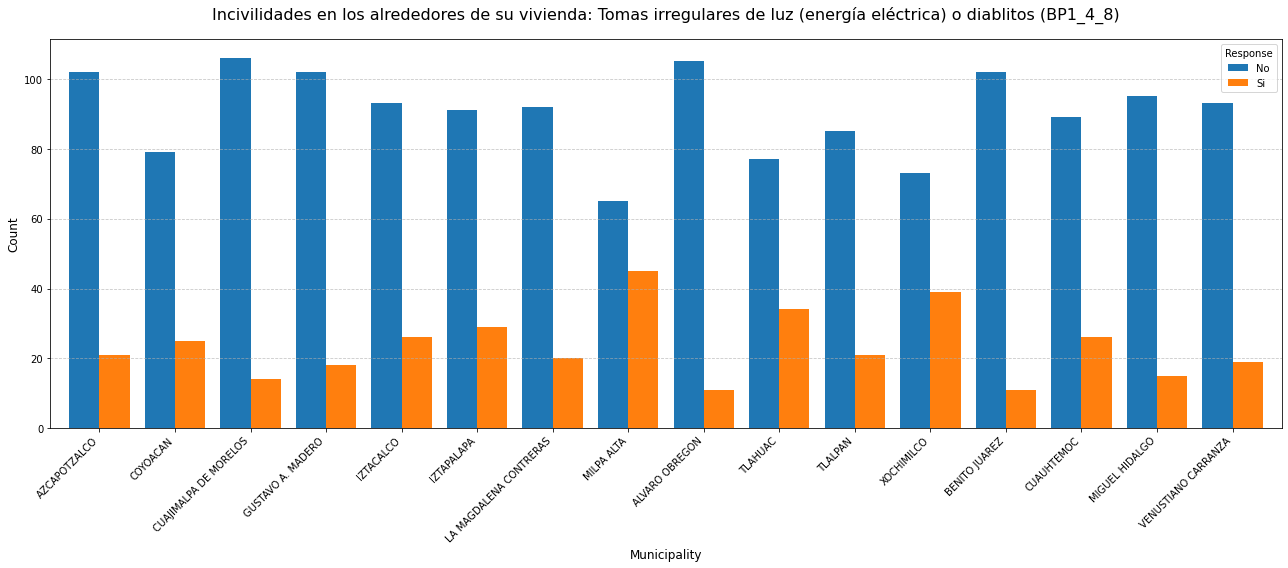


Generating plot for: BP1_5_1


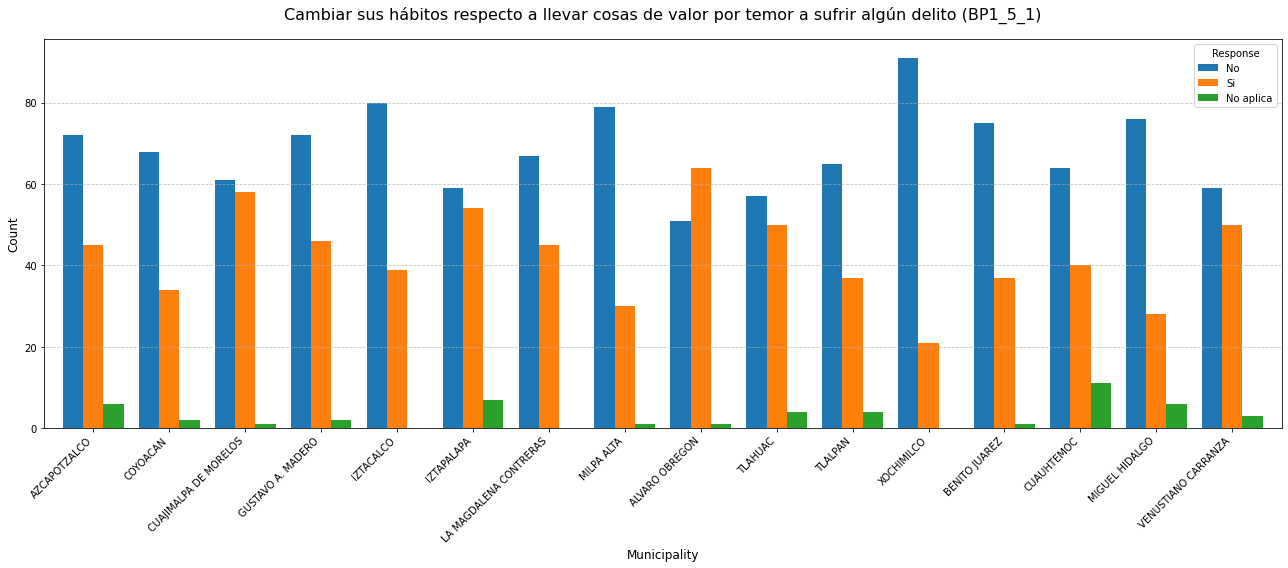


Generating plot for: BP1_5_2


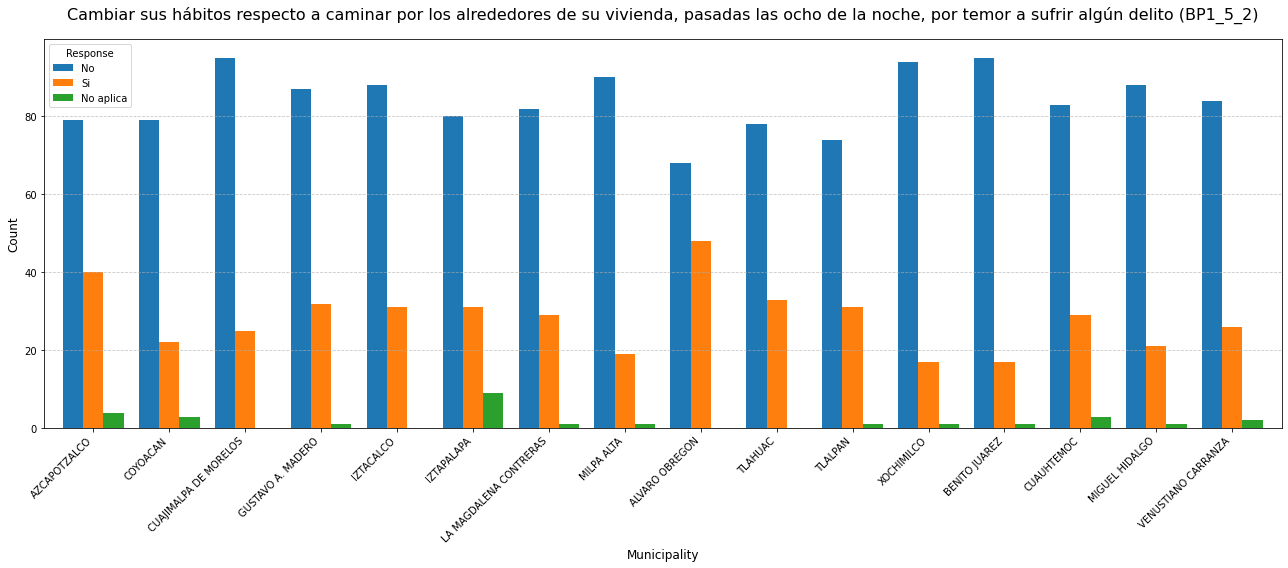


Generating plot for: BP1_6_4


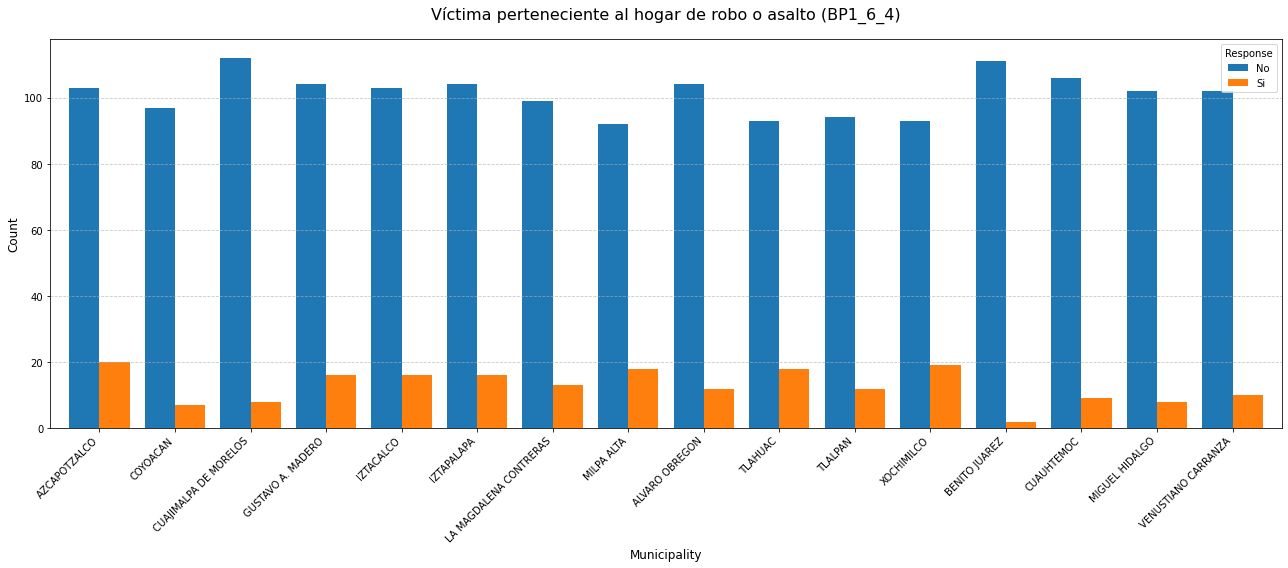


Generating plot for: BP2_2_03


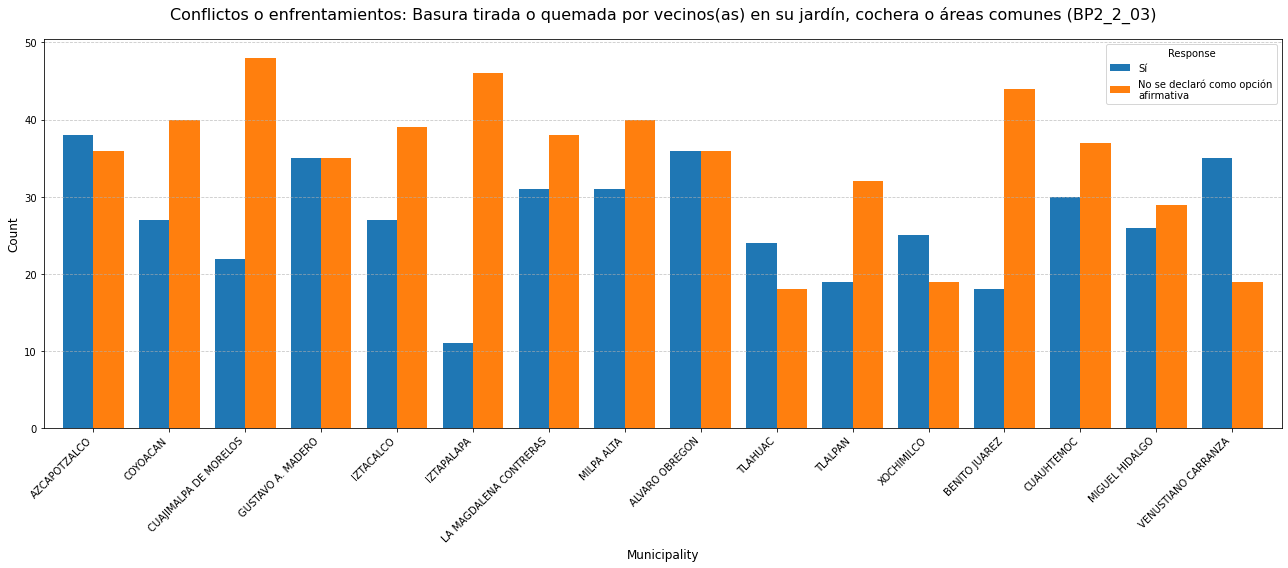


Generating plot for: BP2_2_11


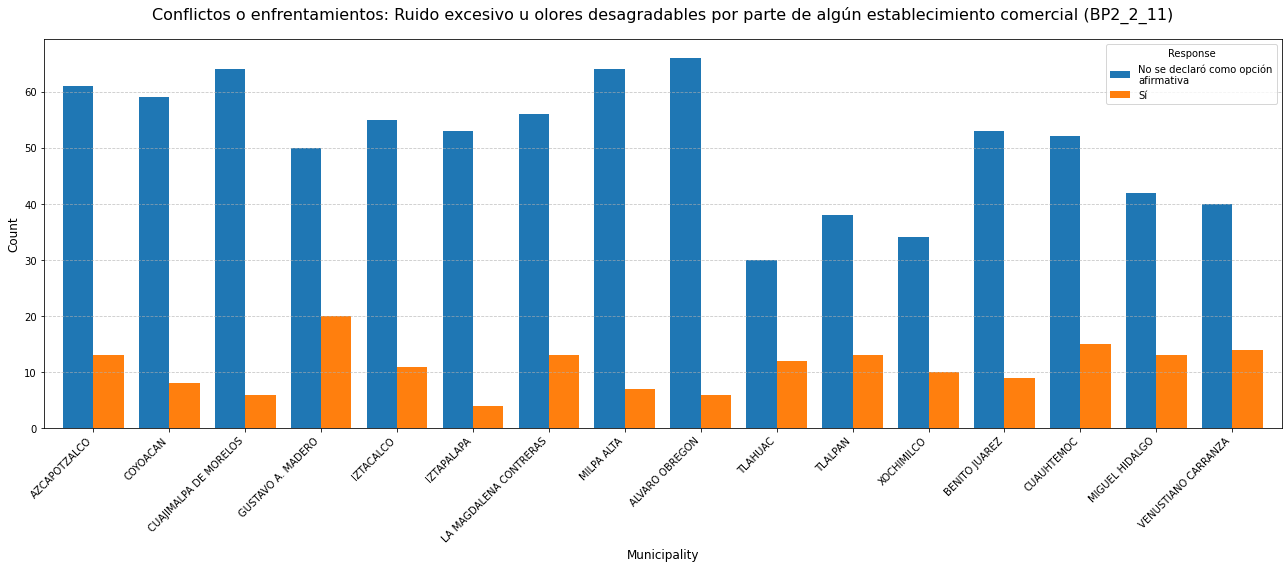


Generating plot for: BP2_2_14


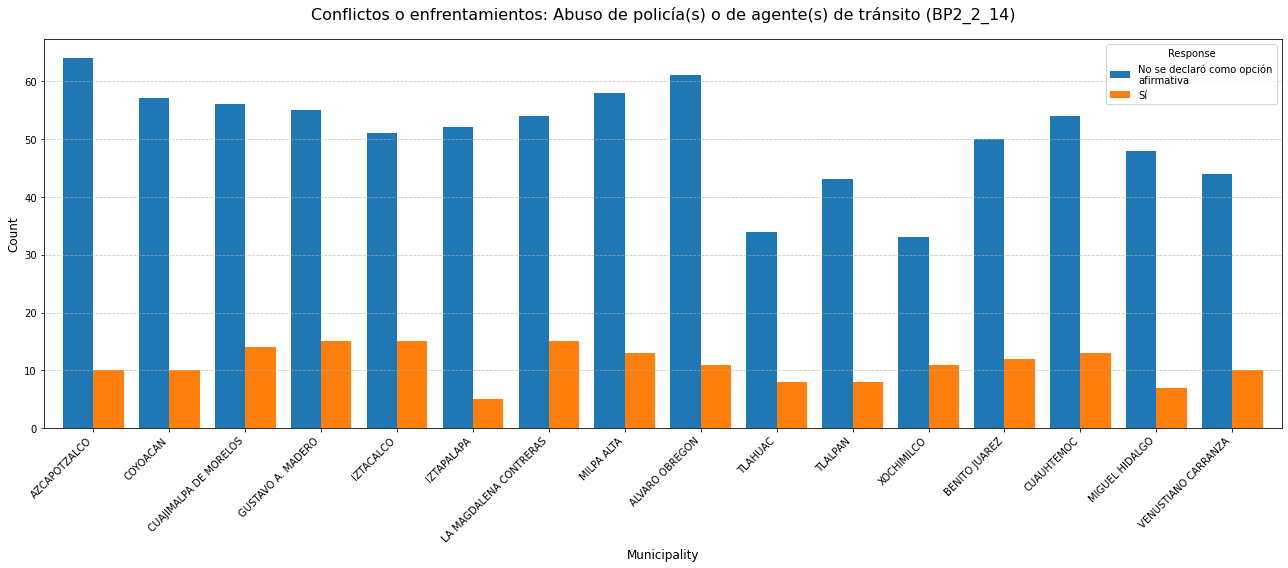


Generating plot for: BP3_1_05


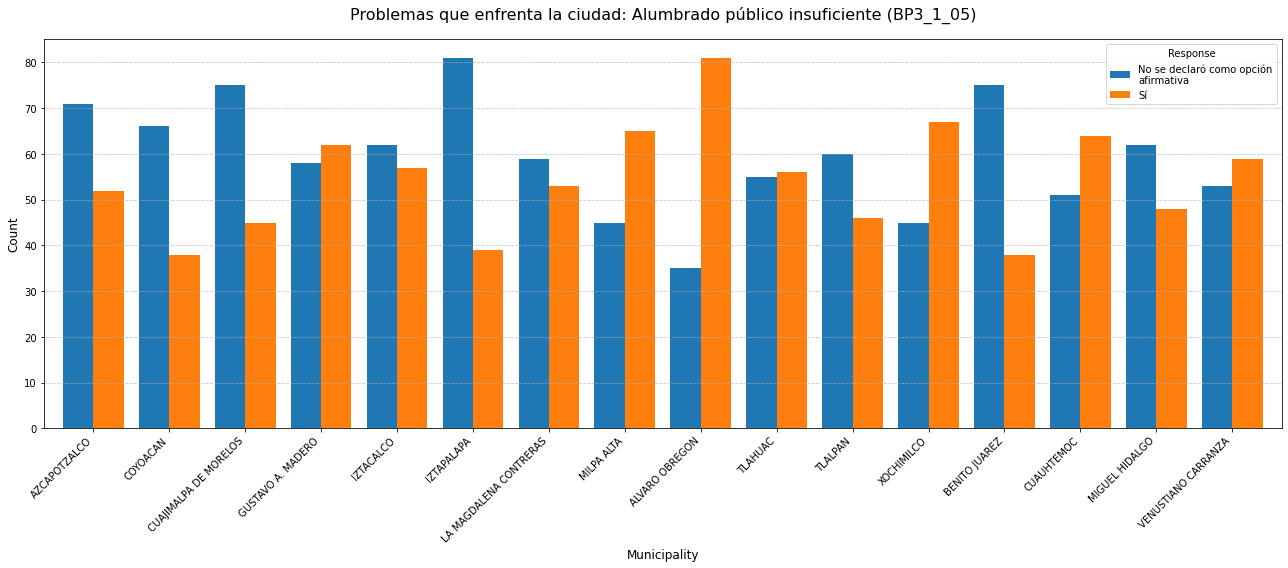


Generating plot for: BP3_1_07


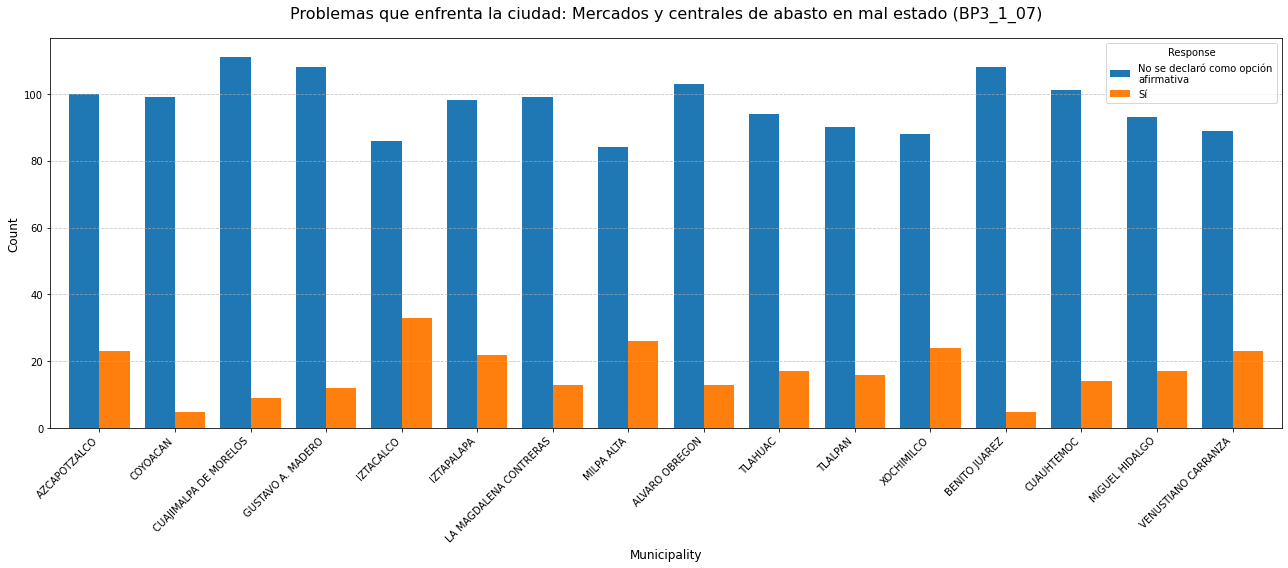


Generating plot for: BP3_1_08


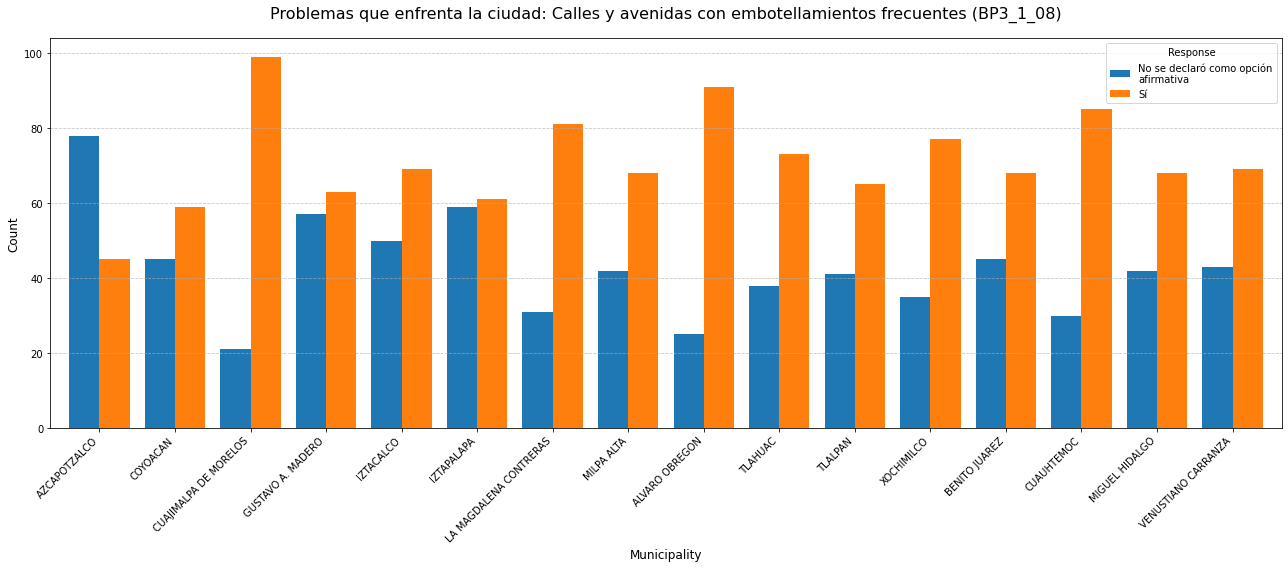


Generating plot for: BP3_1_10


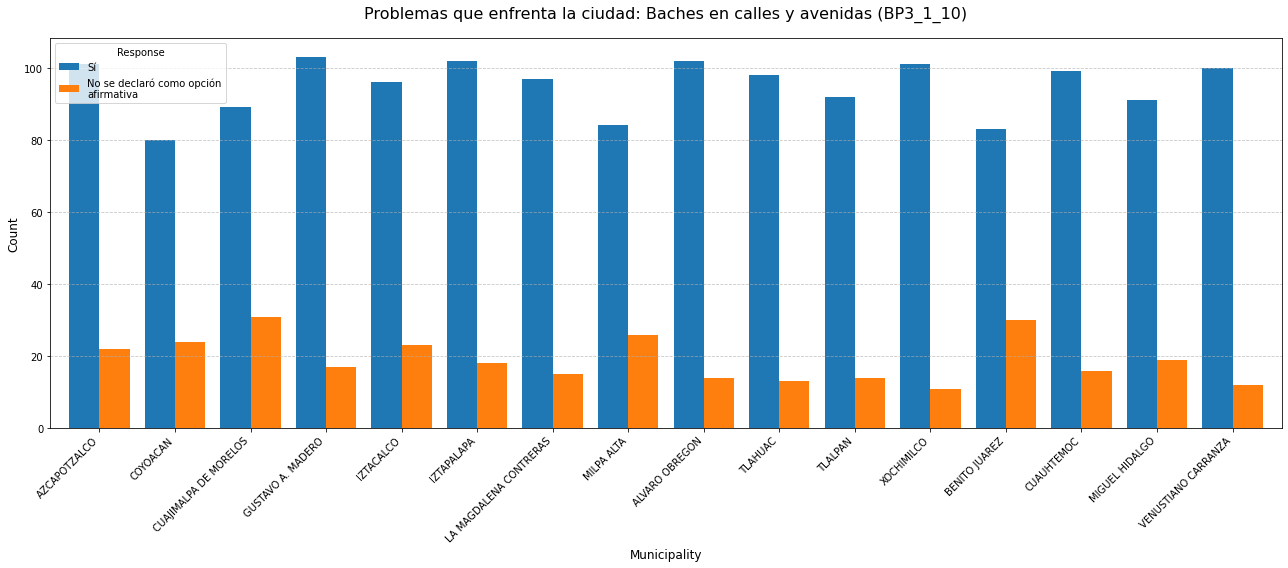


Generating plot for: BP3_1_11


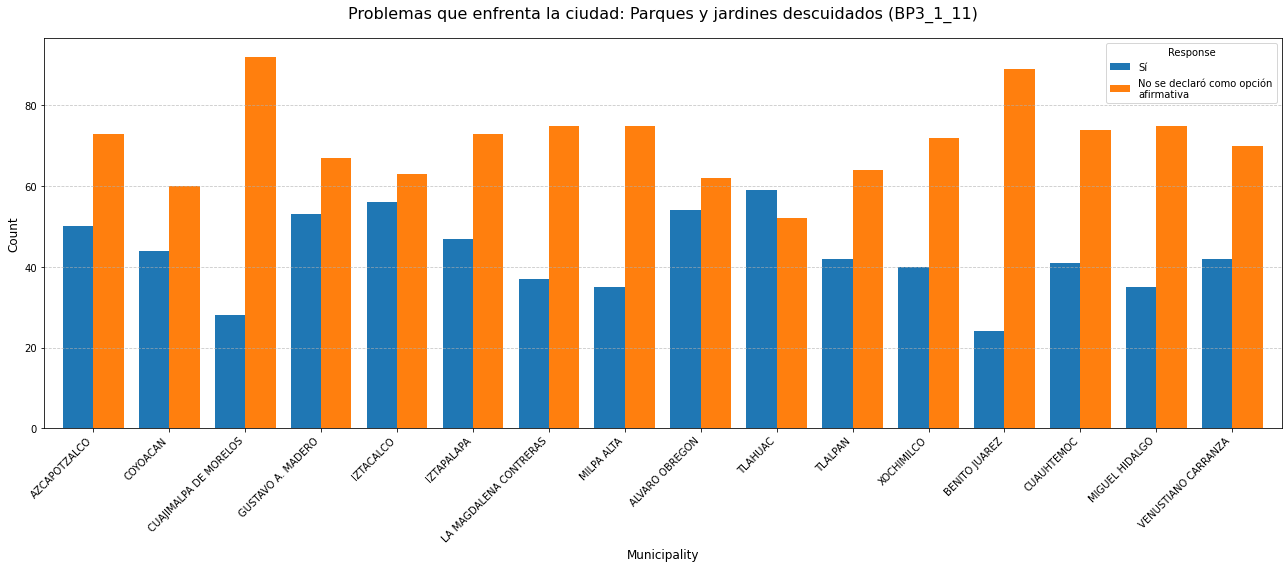


Generating plot for: BP3_1_13


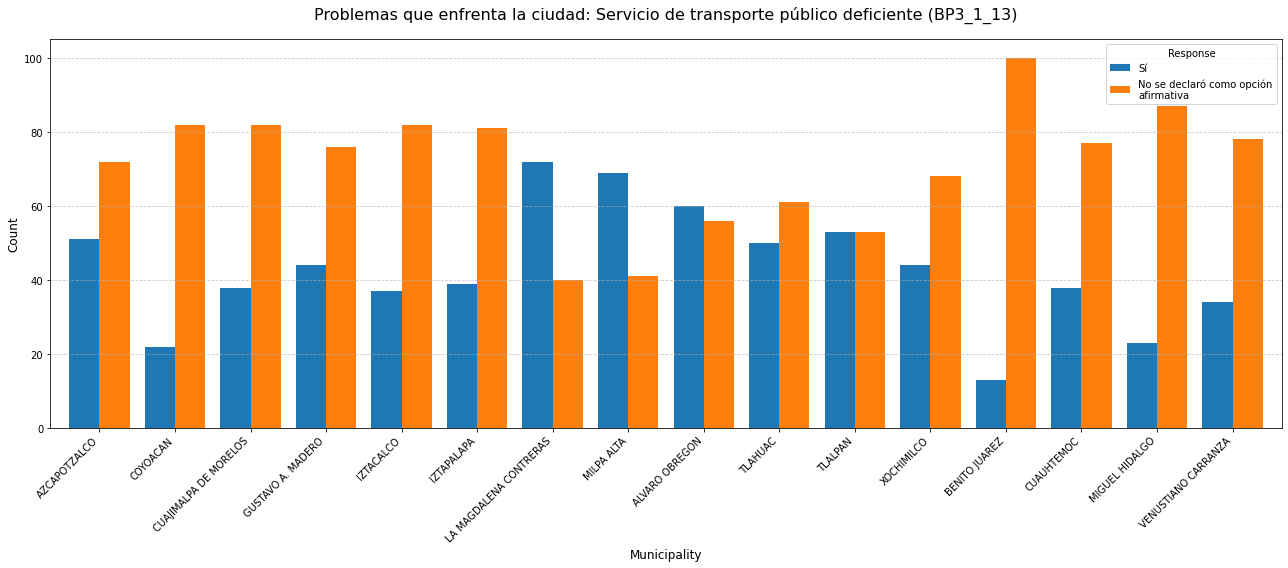


Generating plot for: BP3_1_14


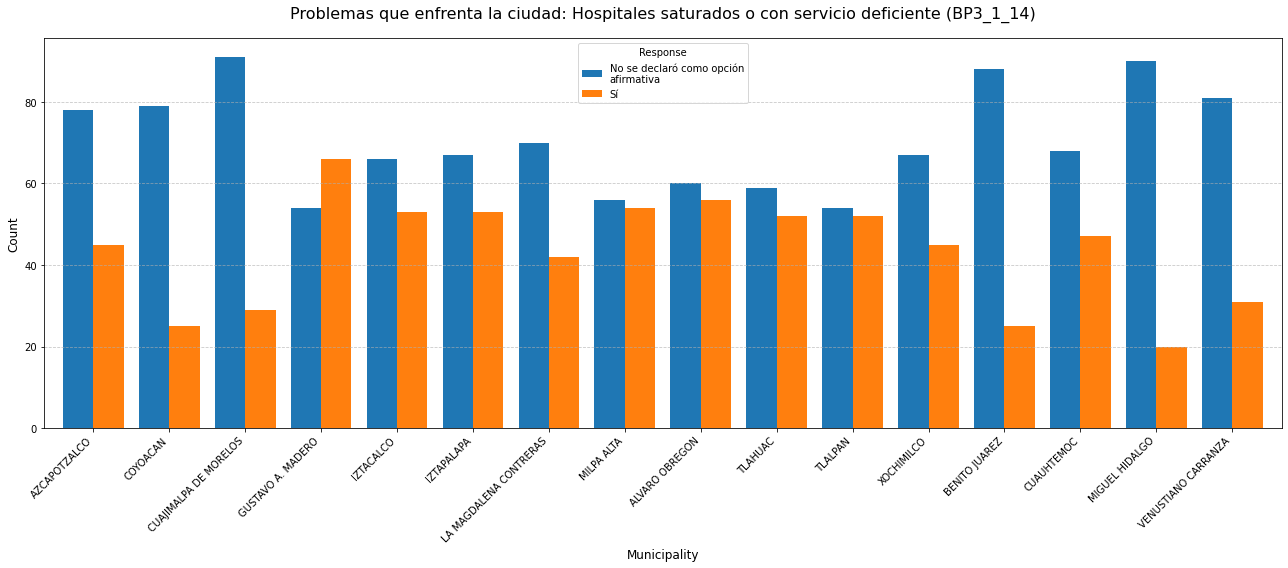


Generating plot for: BP4_1_1


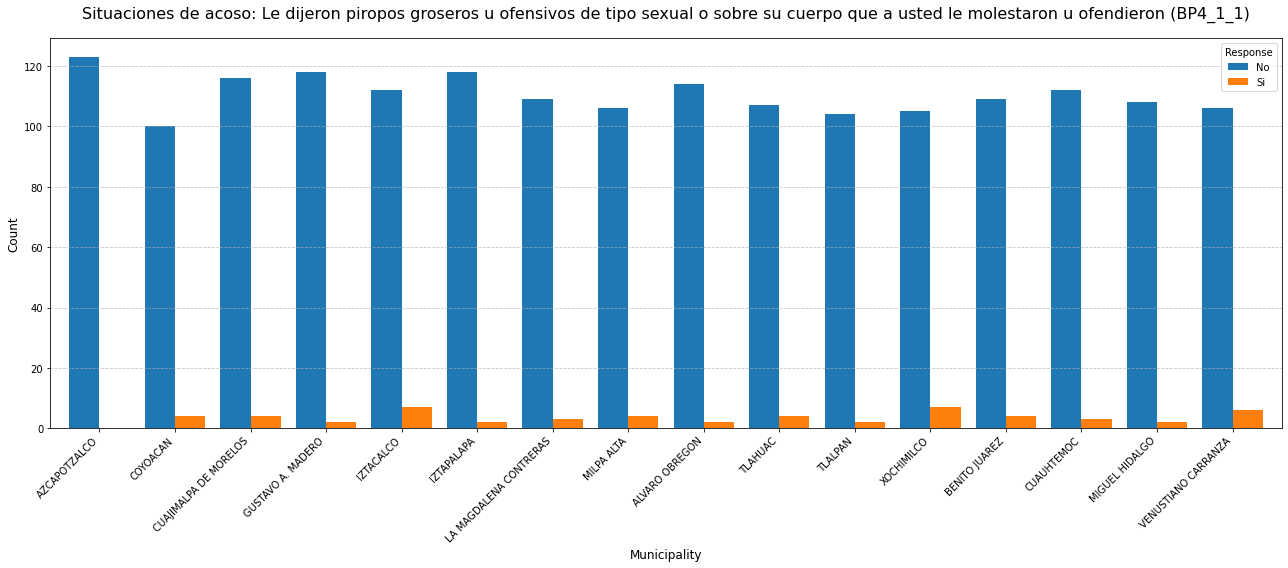


Generating plot for: BP4_1_2


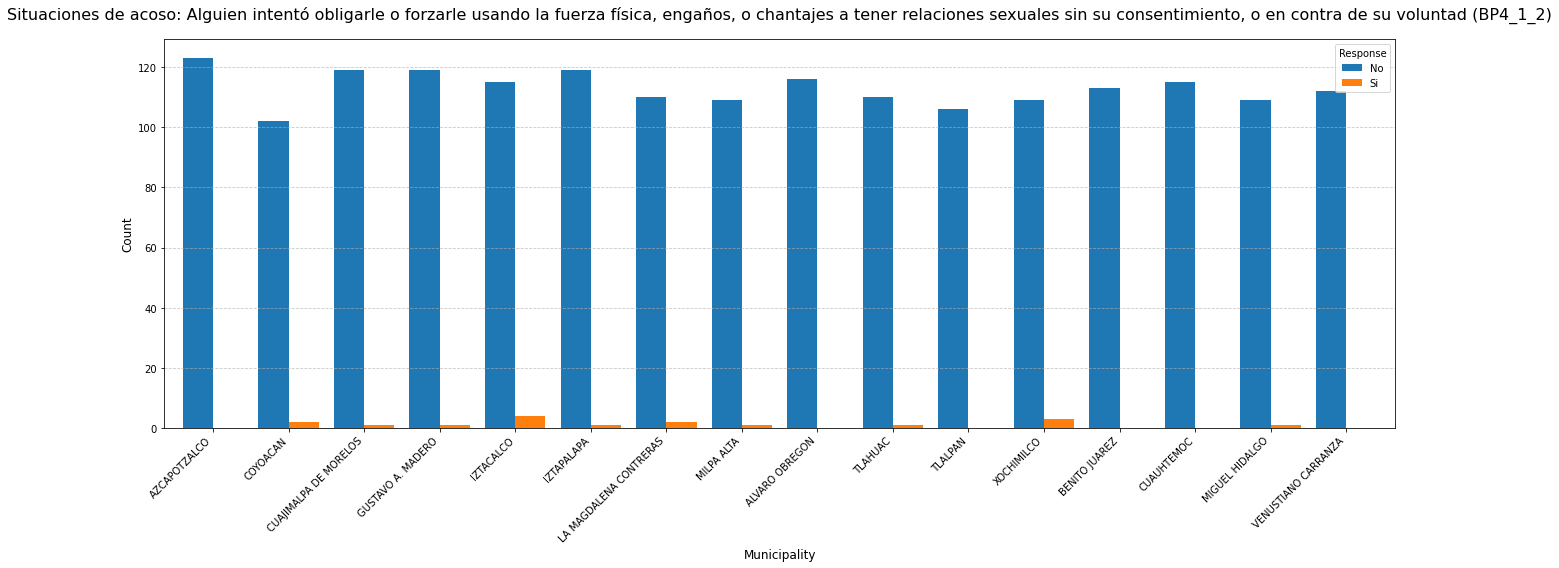


Generating plot for: BP4_1_3


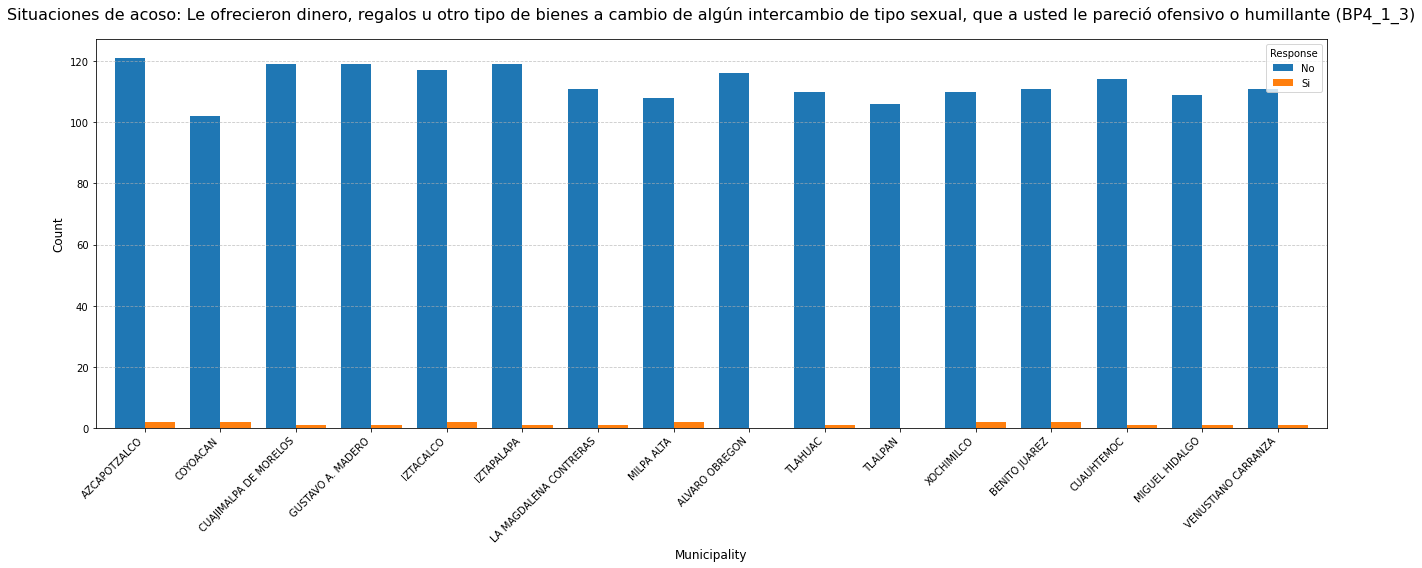


Generating plot for: BP4_1_7


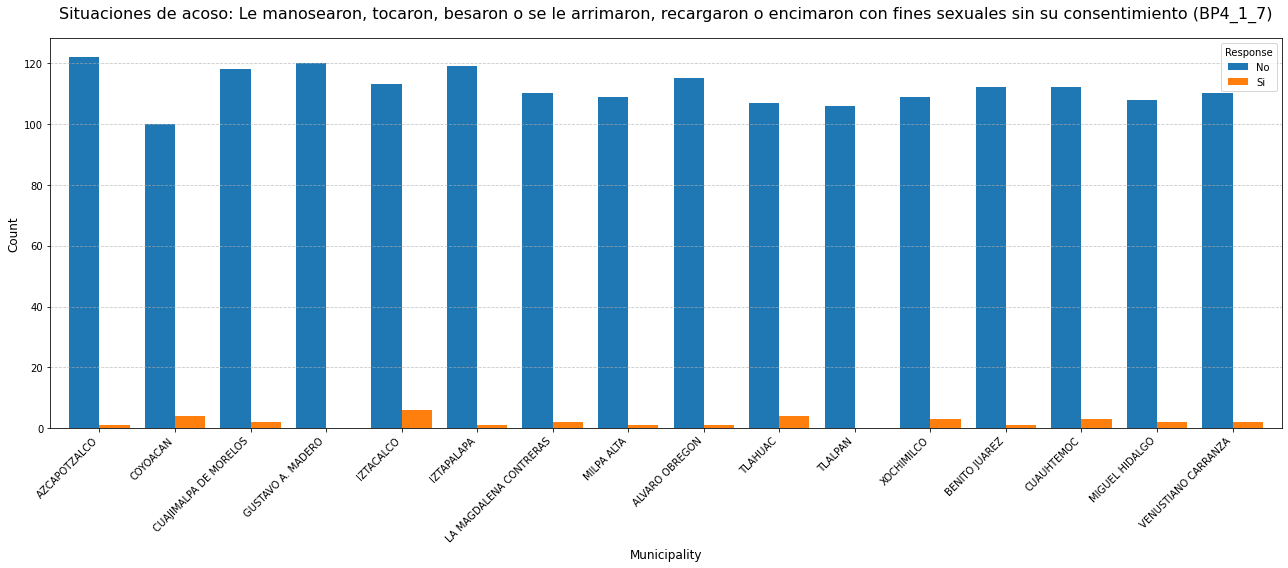


Generating plot for: BP4_1_8


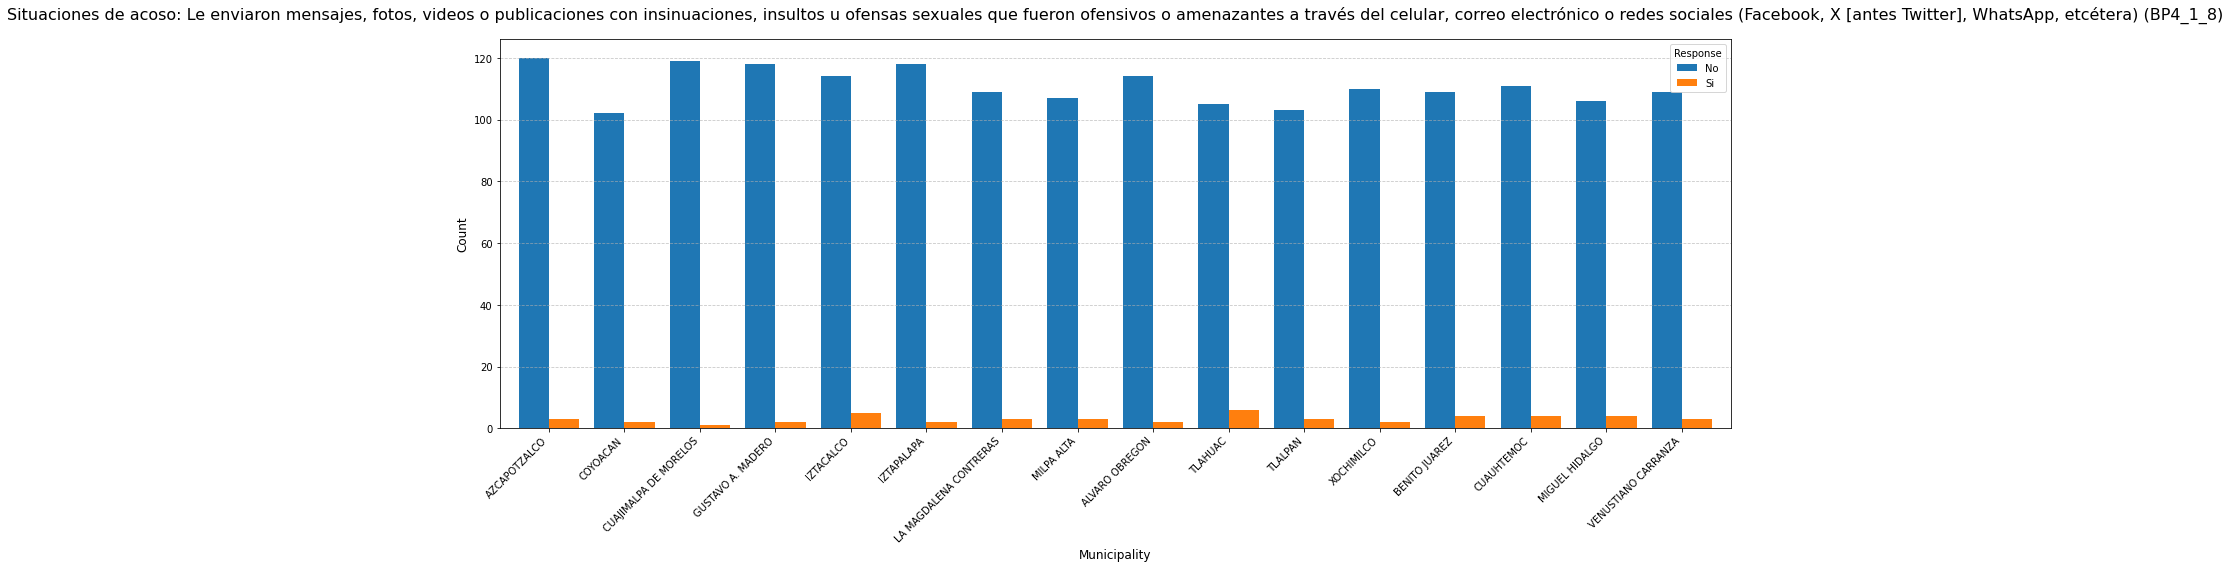

In [76]:
plot_municipality_counts(df_counts_by_municipality_men, df_dictionary)

In [77]:
# print(df_counts_by_municipality.to_string())

In [78]:
# print(df_counts_by_municipality_women.to_string())

In [79]:
# print(df_counts_by_municipality_men.to_string())

In [80]:
def combine_dataframes(df_total, df_women, df_men):
    """
    Combines the three dataframes (total, women, and men) into a single dataframe.

    Args:
      df_total: DataFrame with aggregated data for everyone.
      df_women: DataFrame with aggregated data for women.
      df_men: DataFrame with aggregated data for men.

    Returns:
      A single pandas DataFrame with a new 'GENDER' column to differentiate the records.
    """
    # Add a 'GENDER' column to each dataframe to identify the population
    df_total['GENDER'] = 'Everyone'
    df_women['GENDER'] = 'Women'
    df_men['GENDER'] = 'Men'

    # Combine the dataframes. Pandas will align columns and fill missing values with NaN.
    combined_df = pd.concat([df_total, df_women, df_men], ignore_index=False)

    # Reset the index to make the municipality name a regular column
    combined_df.reset_index(inplace=True)
    combined_df.rename(columns={'index': 'NOM_MUN'}, inplace=True)

    return combined_df

In [81]:
df_counts_by_municipality_combined = combine_dataframes(df_counts_by_municipality, 
                                 df_counts_by_municipality_women, 
                                 df_counts_by_municipality_men)

print("Combined DataFrame preview:")
print(df_counts_by_municipality_combined.head())
print("\nData for a single municipality:")
print(df_counts_by_municipality_combined[df_counts_by_municipality_combined['NOM_MUN'] == 'AZCAPOTZALCO'])

Combined DataFrame preview:
                 NOM_MUN  SEXO_IS_2  SEXO_IS_1  BP1_1_IS_2  BP1_1_IS_1  \
0           AZCAPOTZALCO      124.0      123.0         165          82   
1               COYOACAN      148.0      104.0         113         139   
2  CUAJIMALPA DE MORELOS      121.0      120.0          85         156   
3      GUSTAVO A. MADERO      133.0      120.0         164          89   
4              IZTACALCO      141.0      119.0         161          99   

   BP1_2_01_IS_1  BP1_2_01_IS_2  BP1_2_03_IS_2  BP1_2_03_IS_1  BP1_2_03_IS_3  \
0            211             36            146             98              3   
1            225             27            156             94              2   
2            214             27            128            112              1   
3            211             42            166             85              2   
4            223             37            174             85              1   

   ...  BP4_1_1_IS_1  BP4_1_2_IS_2  BP4_1_2_IS

In [108]:
def create_ranking(df, gender_selection, categories, positive_values, title="Ranking"):
    """
    Creates a ranked dataframe of municipalities based on selected categories.

    Args:
      df: The combined pandas DataFrame.
      gender_selection: A string to filter by ('Everyone', 'Women', or 'Men').
      categories: A list of base column names to be used for the ranking (e.g., ['BP1_1', 'BP1_2_01']).
      positive_values: A list of the values that are considered positive for each category.
                       (e.g., ['_IS_1', '_IS_1'] for 'Seguro').
      title: A string to title the resulting DataFrame's columns.

    Returns:
      A pandas DataFrame with municipalities ranked based on the calculated score.
    """
    # Filter the dataframe based on the selected gender
    df_filtered = df[df['GENDER'] == gender_selection].copy()

    # Initialize the score column
    df_filtered['SCORE'] = 0

    # Calculate the score
    for category, positive_val in zip(categories, positive_values):
        positive_col = f"{category}{positive_val}"
        
        # Infer the negative column based on the positive one
        if positive_val == '_IS_1':
            negative_val = '_IS_2'
        elif positive_val == '_IS_2':
            negative_val = '_IS_1'
        elif positive_val == '_IS_0':
            negative_val = '_IS_1'
        else: # Add other cases if needed
            negative_val = None
        
        negative_col = f"{category}{negative_val}"

        # Ensure both columns exist in the dataframe before calculating
        if positive_col in df_filtered.columns and negative_col in df_filtered.columns:
            # Add the difference to the total score
            # We fill NaN with 0 in case a category is not present for a specific gender

            df_filtered['SCORE']+=df_filtered[positive_col].fillna(0)
    # Create the ranked dataframe
    ranked_df = df_filtered[['NOM_MUN', 'SCORE']].sort_values(by='SCORE', ascending=False)
    ranked_df['RANK'] = range(1, len(ranked_df) + 1)
    
    # Rename columns to reflect the ranking title
    ranked_df.rename(columns={'SCORE': f'{title}_SCORE', 'RANK': f'{title}_RANK'}, inplace=True)

    return ranked_df.set_index(f'{title}_RANK')

#### **1. Ranking: Most Secure Municipalities (General Perception)**
This ranking identifies the municipalities where people feel the safest in their city, their home, and on their streets. A higher score means a better perception of security.

*   **Categories:** `BP1_1` (Security in the city), `BP1_2_01` (Security at home), `BP1_2_03` (Security on the street).
*   **Positive Value:** `_IS_1` (Which corresponds to "Seguro" or "Seguro(a)").

In [121]:
perception_categories = ['BP1_1', 'BP1_2_01', 'BP1_2_03']
positive_is_1 = ['_IS_1', '_IS_1', '_IS_1']
ranking_security_everyone = create_ranking(df_counts_by_municipality_combined, 
                                           gender_selection='Everyone', 
                                           categories=perception_categories, 
                                           positive_values=positive_is_1,
                                           title="General_Security")

print("--- Ranking of Most Secure Municipalities (Everyone) ---")
ranking_security_everyone

--- Ranking of Most Secure Municipalities (Everyone) ---


,NOM_MUN,General_Security_SCORE
General_Security_RANK,,
1,BENITO JUAREZ,566
2,MIGUEL HIDALGO,487
3,CUAJIMALPA DE MORELOS,482
4,CUAUHTEMOC,482
5,LA MAGDALENA CONTRERAS,460
6,COYOACAN,458
7,VENUSTIANO CARRANZA,454
8,MILPA ALTA,449
9,TLALPAN,444


In [122]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ranking_security_everyone["normalized"] = scaler.fit_transform(ranking_security_everyone[["General_Security_SCORE"]])
ranking_security_everyone=format_municipality_names(ranking_security_everyone, "NOM_MUN")
ranking_security_everyone

,NOM_MUN,General_Security_SCORE,normalized
General_Security_RANK,,,
1,Benito Juárez,566,1.000000
2,Miguel Hidalgo,487,0.630841
3,Cuajimalpa de Morelos,482,0.607477
4,Cuauhtémoc,482,0.607477
5,La Magdalena Contreras,460,0.504673
6,Coyoacán,458,0.495327
7,Venustiano Carranza,454,0.476636
8,Milpa Alta,449,0.453271
9,Tlalpan,444,0.429907


In [120]:
ranking_security_everyone.to_csv("./output/security_everyone.csv", index=False)

#### 2. Ranking: Most Secure Municipalities (For Women)

This provides the same security perception ranking but filtered specifically for the female population.


In [98]:
ranking_security_women = create_ranking(df_counts_by_municipality_combined, 
                                        gender_selection='Women', 
                                        categories=perception_categories, 
                                        positive_values=positive_is_1,
                                        title="Women_Security")

print("\n--- Ranking of Most Secure Municipalities (For Women) ---")
ranking_security_women


--- Ranking of Most Secure Municipalities (For Women) ---


,NOM_MUN,Women_Security_SCORE
Women_Security_RANK,,
1,BENITO JUAREZ,2.074074
2,CUAJIMALPA DE MORELOS,1.842975
3,CUAUHTEMOC,1.805369
4,MILPA ALTA,1.773488
5,MIGUEL HIDALGO,1.763457
6,ALVARO OBREGON,1.682547
7,COYOACAN,1.664231
8,LA MAGDALENA CONTRERAS,1.657887
9,TLALPAN,1.653879


In [124]:
scaler = MinMaxScaler()
ranking_security_women["normalized"] = scaler.fit_transform(ranking_security_women[["Women_Security_SCORE"]])
ranking_security_everyone=format_municipality_names(ranking_security_women, "NOM_MUN")
ranking_security_women

,NOM_MUN,Women_Security_SCORE,normalized
Women_Security_RANK,,,
1,Benito Juárez,2.074074,1.000000
2,Cuajimalpa de Morelos,1.842975,0.703607
3,Cuauhtémoc,1.805369,0.655375
4,Milpa Alta,1.773488,0.614486
5,Miguel Hidalgo,1.763457,0.601622
6,Álvaro Obregón,1.682547,0.497851
7,Coyoacán,1.664231,0.474360
8,La Magdalena Contreras,1.657887,0.466224
9,Tlalpan,1.653879,0.461083


In [125]:
ranking_security_women.to_csv("./output/security_for_women.csv", index=False)

#### **3. Ranking: Lowest Perception of Incivilities**
This ranking identifies municipalities with the lowest reported instances of vandalism, robberies, and drug-related activities. A higher score means fewer problems are perceived.

*   **Categories:** `BP1_4_1` (Vandalism), `BP1_4_3` (Robberies), `BP1_4_5` (Drug sales/consumption).
*   **Positive Value:** `_IS_2` (Which corresponds to "No").

In [85]:
incivilities_categories = ['BP1_4_1', 'BP1_4_3', 'BP1_4_5']
positive_is_2 = ['_IS_2', '_IS_2', '_IS_2']

ranking_low_incivilities = create_ranking(df_counts_by_municipality_combined, 
                                          gender_selection='Everyone', 
                                          categories=incivilities_categories, 
                                          positive_values=positive_is_2,
                                          title="Lowest_Incivilities")

print("\n--- Ranking of Municipalities with Lowest Incivilities ---")
ranking_low_incivilities


--- Ranking of Municipalities with Lowest Incivilities ---


,NOM_MUN,Lowest_Incivilities_SCORE
Lowest_Incivilities_RANK,,
1,BENITO JUAREZ,420
2,CUAJIMALPA DE MORELOS,183
3,TLALPAN,96
4,LA MAGDALENA CONTRERAS,62
5,CUAUHTEMOC,48
6,COYOACAN,40
7,MIGUEL HIDALGO,32
8,MILPA ALTA,20
9,AZCAPOTZALCO,-1


#### **4. Ranking: Freedom from Fear (Women)**
This ranks municipalities where women have had to change their habits the least due to fear of crime (like no longer carrying valuables or avoiding walking at night). A higher score indicates greater freedom.

*   **Categories:** `BP1_5_1` (Changed habits about carrying valuables), `BP1_5_2` (Changed habits about walking at night).
*   **Positive Value:** `_IS_2` (Corresponds to "No").

In [86]:
habits_categories = ['BP1_5_1', 'BP1_5_2']
positive_is_2_habits = ['_IS_2', '_IS_2']

ranking_habits_women = create_ranking(df_counts_by_municipality_combined, 
                                      gender_selection='Women', 
                                      categories=habits_categories, 
                                      positive_values=positive_is_2_habits,
                                      title="Freedom_From_Fear_Women")

print("\n--- Ranking of Municipalities Where Women Change Habits the Least ---")
ranking_habits_women


--- Ranking of Municipalities Where Women Change Habits the Least ---


,NOM_MUN,Freedom_From_Fear_Women_SCORE
Freedom_From_Fear_Women_RANK,,
1,MILPA ALTA,146
2,XOCHIMILCO,84
3,LA MAGDALENA CONTRERAS,69
4,BENITO JUAREZ,60
5,MIGUEL HIDALGO,54
6,CUAUHTEMOC,50
7,VENUSTIANO CARRANZA,31
8,IZTACALCO,30
9,TLAHUAC,24


#### **5. Ranking: Best Public Services Perception**
This identifies municipalities with the fewest complaints about key public services like street lighting and pothole problems. A higher score means better-perceived services.

*   **Categories:** `BP3_1_05` (Insufficient street lighting), `BP3_1_10` (Potholes).
*   **Positive Value:** `_IS_0` (Corresponds to "No se declaró como opción afirmativa").

In [87]:
services_categories = ['BP3_1_05', 'BP3_1_10']
positive_is_0 = ['_IS_0', '_IS_0']

ranking_public_services = create_ranking(df_counts_by_municipality_combined, 
                                         gender_selection='Everyone', 
                                         categories=services_categories, 
                                         positive_values=positive_is_0,
                                         title="Best_Public_Services")

print("\n--- Ranking of Municipalities with Best Public Services Perception ---")
ranking_public_services


--- Ranking of Municipalities with Best Public Services Perception ---


,NOM_MUN,Best_Public_Services_SCORE
Best_Public_Services_RANK,,
1,BENITO JUAREZ,-64
2,CUAJIMALPA DE MORELOS,-68
3,COYOACAN,-108
4,VENUSTIANO CARRANZA,-114
5,IZTAPALAPA,-118
6,MIGUEL HIDALGO,-124
7,TLALPAN,-138
8,MILPA ALTA,-144
9,AZCAPOTZALCO,-154


#### **6. Ranking: Lowest Street Harassment (Women)**
This ranking is crucial as it identifies where women report the lowest incidence of street harassment, such as offensive catcalls and unwanted physical contact. A higher score is better.

*   **Categories:** `BP4_1_1` (Offensive catcalls), `BP4_1_7` (Unwanted touching/groping).
*   **Positive Value:** `_IS_2` (Corresponds to "No").

In [88]:
harassment_categories = ['BP4_1_1', 'BP4_1_7']
positive_is_2_harassment = ['_IS_2', '_IS_2']

ranking_harassment_women = create_ranking(df_counts_by_municipality_combined, 
                                          gender_selection='Women', 
                                          categories=harassment_categories, 
                                          positive_values=positive_is_2_harassment,
                                          title="Lowest_Harassment_Women")

print("\n--- Ranking of Municipalities with Lowest Street Harassment (Women) ---")
ranking_harassment_women


--- Ranking of Municipalities with Lowest Street Harassment (Women) ---


,NOM_MUN,Lowest_Harassment_Women_SCORE
Lowest_Harassment_Women_RANK,,
1,COYOACAN,246
2,CUAUHTEMOC,242
3,BENITO JUAREZ,238
4,MILPA ALTA,236
5,TLALPAN,234
6,XOCHIMILCO,228
7,VENUSTIANO CARRANZA,228
8,MIGUEL HIDALGO,226
9,ALVARO OBREGON,216


#### **7. Ranking: Fewest Neighborhood Conflicts**
This shows which municipalities have the fewest reported conflicts between neighbors over issues like trash and noise. A higher score signifies more peaceful neighborhoods.

*   **Categories:** `BP2_2_03` (Conflicts over trash), `BP2_2_11` (Conflicts over noise).
*   **Positive Value:** `_IS_0` (Corresponds to "No se declaró como opción afirmativa").

In [89]:
conflict_categories = ['BP2_2_03', 'BP2_2_11']
positive_is_0_conflict = ['_IS_0', '_IS_0']

ranking_low_conflict = create_ranking(df_counts_by_municipality_combined, 
                                      gender_selection='Everyone', 
                                      categories=conflict_categories, 
                                      positive_values=positive_is_0_conflict,
                                      title="Fewest_Neighbor_Conflicts")

print("\n--- Ranking of Municipalities with Fewest Neighborhood Conflicts ---")
ranking_low_conflict


--- Ranking of Municipalities with Fewest Neighborhood Conflicts ---


,NOM_MUN,Fewest_Neighbor_Conflicts_SCORE
Fewest_Neighbor_Conflicts_RANK,,
1,COYOACAN,156
2,CUAJIMALPA DE MORELOS,152
3,MILPA ALTA,152
4,IZTAPALAPA,144
5,ALVARO OBREGON,140
6,IZTACALCO,132
7,BENITO JUAREZ,116
8,AZCAPOTZALCO,98
9,LA MAGDALENA CONTRERAS,98


#### **8. Ranking: Lowest Risk of Robbery or Assault at Home**
This ranking identifies municipalities where residents report the lowest number of households having a member who was a victim of robbery or assault.

*   **Category:** `BP1_6_4` (Household member victim of robbery/assault).
*   **Positive Value:** `_IS_2` (Corresponds to "No").

In [90]:
ranking_low_robbery = create_ranking(df_counts_by_municipality_combined,
                                     gender_selection='Everyone',
                                     categories=['BP1_6_4'],
                                     positive_values=['_IS_2'],
                                     title="Lowest_Home_Robbery_Risk")

print("\n--- Ranking of Municipalities with Lowest Risk of Robbery or Assault ---")
ranking_low_robbery


--- Ranking of Municipalities with Lowest Risk of Robbery or Assault ---


,NOM_MUN,Lowest_Home_Robbery_Risk_SCORE
Lowest_Home_Robbery_Risk_RANK,,
1,BENITO JUAREZ,234
2,CUAUHTEMOC,230
3,COYOACAN,218
4,MIGUEL HIDALGO,218
5,ALVARO OBREGON,214
6,VENUSTIANO CARRANZA,213
7,TLALPAN,210
8,CUAJIMALPA DE MORELOS,209
9,MILPA ALTA,206


In [91]:
df.to_csv("./output/security.csv", index=False)